# DETECCION DE FRAUDE - TRANSACCIONES FRAUDULENTAS

## 1. Descripcion


### Conjunto de datos Amaretto: un conjunto de datos sintéticos del mercado de capitales

Los datos combinan más de 10 000 parámetros extrapolados de datos reales del mercado. El conjunto de datos consta de **29 704 090** transacciones ejecutadas por **400 clientes** finales que compran y venden valores específicos en un mercado específico. Aproximadamente el **90 %** de los usuarios realizaron al menos **50 000 transacciones**, mientras que el **10 %** de los usuarios realizaron aproximadamente **400 000**, lo que significa que el **10 %** de los clientes ejecutaron casi el **50 %** de las transacciones. El **98,43 %** de las transacciones tienen un importe inferior a **1 millón** de dólares estadounidenses, y el **40 %** de ellas tienen un importe inferior a **10 000** dólares estadounidenses. Los datos cubren **60 días** divididos en 12 semanas (una semana se compone de 5 días. Los sábados y domingos no se incluyen porque durante el fin de semana los mercados están cerrados). Las transacciones se distribuyen uniformemente entre las 12 semanas, y la mayoría se ejecutan durante el horario de apertura del mercado, mientras que solo un pequeño porcentaje se ejecuta durante las primeras horas de la mañana y al final del día.

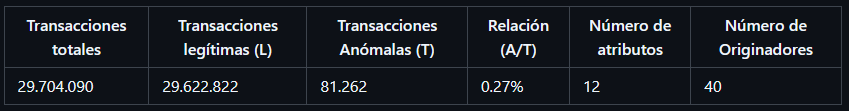

Los campos clave que contiene el dato incluyen el importe de la transacción, la clase de producto (hay **17 productos** diferentes que representan los principales productos negociados en el mercado de capitales, por ejemplo, acciones, renta fija), el tipo de producto (por ejemplo, acciones al contado, acciones a futuro, bonos), el campo de tiempo, la moneda y el mercado. Dentro de los datos, no es posible identificar ninguna distribución estadística específica en ninguno de los campos clave.

### Descripción general de las anomalías sintéticas

Se sabe que los conjuntos de datos financieros están extremadamente desequilibrados, conteniendo generalmente entre un **0,1 %** y un **1 %** de transacciones anómalas (#1). Por lo tanto, para replicar escenarios del mundo real, establecimos el número de anomalías en menos del 1 % de los datos. Como parte de este conjunto de datos, generamos cinco clases de anomalías basadas en ejemplos de patrones sospechosos sugeridos por el GAFI (#2), un organismo intergubernamental que promueve la implementación efectiva de medidas legales, regulatorias y operativas para combatir el lavado de dinero. Las transacciones anómalas seguirán la misma tendencia para reforzar el concepto de que las transacciones anómalas están bien ocultas en el conjunto de datos. A continuación, describimos las clases de anomalías inyectadas en el conjunto de datos.

- **Transacciones pequeñas pero muy frecuentes generadas en un corto período de tiempo** : un patrón que contiene múltiples transacciones por debajo de los umbrales de notificación aplicables.

- **Transacciones con importes normalizados redondeados comprados o vendidos dentro de una cuenta** : Es inusual que las transacciones en los mercados de capitales tengan importes redondeados (a menos que ocurran en mercados donde la conversión de divisas cause errores de redondeo).

- **Valores comprados o vendidos en un momento inusual** : Es inusual que los clientes negocien valores específicos fuera de un plazo determinado (por ejemplo, fuera de los horarios de apertura y cierre de una bolsa de valores).

- **Retiro de activos de gran magnitud** : Un aumento repentino en el monto de las transacciones retiradas de una cuenta o transferidas, que se desvía de la actividad transaccional anterior y carece de cualquier justificación comercial o evento corporativo relacionado.

- **Una cantidad inusualmente grande de garantías transferidas dentro y fuera de una cuenta en un corto período de tiempo** : este comportamiento es inusual, ya que un cliente no podría invertir simplemente intercambiando garantías, o al menos tal estrategia sería inusual.


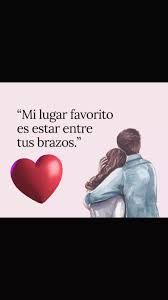

In [1]:
%%sql
CREATE SCHEMA IF NOT EXISTS gold

StatementMeta(, 78f63463-76dd-48e4-a0a8-641162aa6695, 2, Finished, Available, Finished, False)

<Spark SQL result set with 0 rows and 0 fields>

## 2. Capa Bronze

### 2.1 Lectura de los archivos Parquet

Importamos las líbrerias

In [1]:
from pyspark.sql import types as T
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import StringType
from pyspark.sql.window import Window

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 3, Finished, Available, Finished, False)

In [1]:
from pyspark.sql import types as T

StatementMeta(, , -1, Cancelled, , Cancelled, True)

Procedemos a leer nuestra data almacenada (parquet) dentro de nuestro OneLake, en la carpeta Files, bronze.

In [2]:
df = spark.read.parquet("Files/Bronze/")
# df now is a Spark DataFrame containing parquet data from "Files/bronze/part-00000-aad03ccd-043c-4424-bf72-356c8acdcd2f.c000.snappy.parquet".
display(df)

StatementMeta(, 1d0f184b-2f79-4235-b84b-86e1aceca126, 4, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 2764431e-ac6b-4b00-859e-3ddc9954e215)

### 2.2 Verificamos que la lectura sea completa

In [3]:
df.count()
df.printSchema()

StatementMeta(, 1d0f184b-2f79-4235-b84b-86e1aceca126, 5, Finished, Available, Finished, False)

root
 |-- col-e15326e8-31dd-49d3-ad33-121d9ce81120: string (nullable = true)
 |-- col-83bb512c-2ec0-482f-9db8-ebe5c8dce495: string (nullable = true)
 |-- col-c0d3cc99-9bbd-4fd1-a696-0c57e3aa354d: string (nullable = true)
 |-- col-9717fb3d-0f4d-470e-9a8e-f6d1fe3106d6: string (nullable = true)
 |-- col-eac1924a-4517-4ab3-bee9-a9b76ba9bda2: string (nullable = true)
 |-- col-705d3b0e-4f24-4522-a63e-53076c2cce41: string (nullable = true)
 |-- col-5bb521db-604d-4967-a54a-d829e9f5aab6: string (nullable = true)
 |-- col-b13181b5-9ba5-4b55-9a45-365ca71f04a0: string (nullable = true)
 |-- col-e796c040-e3ef-473d-bd9f-09291da33564: string (nullable = true)
 |-- col-6b5bfaa9-8cb7-4734-bbd2-9faa1378f7e0: string (nullable = true)
 |-- col-65d7f403-a12c-4840-aeb4-48078e8482e1: string (nullable = true)
 |-- col-366ccf04-aa75-449c-958d-7db7988742a9: string (nullable = true)



### 2.3 Realizamos transformaciones de los tipos de columnas

In [4]:
# Código generado por Data Wrangler para PySpark DataFrame

def clean_data(df):
    # Cambiar el nombre de la columna 'col-e15326e8-31dd-49d3-ad33-121d9ce81120' a 'Transaccion_ID'
    df = df.withColumnRenamed('col-e15326e8-31dd-49d3-ad33-121d9ce81120', 'Transaccion_ID')
    # Cambiar el nombre de la columna 'col-83bb512c-2ec0-482f-9db8-ebe5c8dce495' a 'Clientes'
    df = df.withColumnRenamed('col-83bb512c-2ec0-482f-9db8-ebe5c8dce495', 'Clientes')
    # Cambiar el nombre de la columna 'col-c0d3cc99-9bbd-4fd1-a696-0c57e3aa354d' a 'Clientes_ID'
    df = df.withColumnRenamed('col-c0d3cc99-9bbd-4fd1-a696-0c57e3aa354d', 'Clientes_ID')
    # Cambiar el nombre de la columna 'col-9717fb3d-0f4d-470e-9a8e-f6d1fe3106d6' a 'Fecha_Registro'
    df = df.withColumnRenamed('col-9717fb3d-0f4d-470e-9a8e-f6d1fe3106d6', 'Fecha_Registro')
    # Cambiar el nombre de la columna 'col-eac1924a-4517-4ab3-bee9-a9b76ba9bda2' a 'Tipo_Operacion'
    df = df.withColumnRenamed('col-eac1924a-4517-4ab3-bee9-a9b76ba9bda2', 'Tipo_Operacion')
    # Cambiar el nombre de la columna 'col-705d3b0e-4f24-4522-a63e-53076c2cce41' a 'Tipo_Mercados'
    df = df.withColumnRenamed('col-705d3b0e-4f24-4522-a63e-53076c2cce41', 'Tipo_Mercados')
    # Cambiar el nombre de la columna 'col-5bb521db-604d-4967-a54a-d829e9f5aab6' a 'Identificador_financiero_ID'
    df = df.withColumnRenamed('col-5bb521db-604d-4967-a54a-d829e9f5aab6', 'Identificador_financiero_ID')
    # Cambiar el nombre de la columna 'col-b13181b5-9ba5-4b55-9a45-365ca71f04a0' a 'Tipo_producto'
    df = df.withColumnRenamed('col-b13181b5-9ba5-4b55-9a45-365ca71f04a0', 'Tipo_producto')
    # Cambiar el nombre de la columna 'col-e796c040-e3ef-473d-bd9f-09291da33564' a 'Tipo_movimiento'
    df = df.withColumnRenamed('col-e796c040-e3ef-473d-bd9f-09291da33564', 'Tipo_movimiento')
    # Cambiar el nombre de la columna 'col-6b5bfaa9-8cb7-4734-bbd2-9faa1378f7e0' a 'Valor_monetario'
    df = df.withColumnRenamed('col-6b5bfaa9-8cb7-4734-bbd2-9faa1378f7e0', 'Valor_monetario')
    # Cambiar el nombre de la columna 'col-65d7f403-a12c-4840-aeb4-48078e8482e1' a 'Tipo_moneda'
    df = df.withColumnRenamed('col-65d7f403-a12c-4840-aeb4-48078e8482e1', 'Tipo_moneda')
    # Cambiar el nombre de la columna 'col-366ccf04-aa75-449c-958d-7db7988742a9' a 'Anomalia'
    df = df.withColumnRenamed('col-366ccf04-aa75-449c-958d-7db7988742a9', 'Anomalia')
    # Cambia el tipo de columna por datetime64[ns] para la columna: 'Fecha_Registro'
    # ⚠️ Es posible que no se admita el formato de marca de tiempo. Compruebe los resultados y modifíquelos si es necesario.
    df = df.withColumn('Fecha_Registro', df['Fecha_Registro'].cast(T.TimestampType()))
    # Cambia el tipo de columna por string para la columna: 'Transaccion_ID'
    df = df.withColumn('Transaccion_ID', df['Transaccion_ID'].cast(T.StringType()))
    # Cambia el tipo de columna por string para la columna: 'Clientes'
    df = df.withColumn('Clientes', df['Clientes'].cast(T.StringType()))
    # Cambia el tipo de columna por string para la columna: 'Clientes_ID'
    df = df.withColumn('Clientes_ID', df['Clientes_ID'].cast(T.StringType()))
    # Cambiar el tipo de columna a stringpara las columnas: 'Tipo_Operacion', 'Tipo_Mercados' y 4 otras columnas
    df = df.withColumn('Tipo_Operacion', df['Tipo_Operacion'].cast(T.StringType()))
    df = df.withColumn('Tipo_Mercados', df['Tipo_Mercados'].cast(T.StringType()))
    df = df.withColumn('Identificador_financiero_ID', df['Identificador_financiero_ID'].cast(T.StringType()))
    df = df.withColumn('Tipo_producto', df['Tipo_producto'].cast(T.StringType()))
    df = df.withColumn('Tipo_movimiento', df['Tipo_movimiento'].cast(T.StringType()))
    df = df.withColumn('Tipo_moneda', df['Tipo_moneda'].cast(T.StringType()))
    # Cambia el tipo de columna por float64 para la columna: 'Valor_monetario'
    df = df.withColumn('Valor_monetario', df['Valor_monetario'].cast(T.DoubleType()))
    return df

df_clean = clean_data(df)
display(df_clean)

StatementMeta(, 1d0f184b-2f79-4235-b84b-86e1aceca126, 6, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 2acc448a-839b-4eef-b2cf-6c1564a5d26c)

In [5]:
# Código generado por Data Wrangler para PySpark DataFrame

def clean_data(df_clean):
    # Cambiar el tipo de columna a stringpara las columnas: 'Transaccion_ID', 'Clientes' y 7 otras columnas
    df_clean = df_clean.withColumn('Transaccion_ID', df_clean['Transaccion_ID'].cast(T.StringType()))
    df_clean = df_clean.withColumn('Clientes', df_clean['Clientes'].cast(T.StringType()))
    df_clean = df_clean.withColumn('Clientes_ID', df_clean['Clientes_ID'].cast(T.StringType()))
    df_clean = df_clean.withColumn('Tipo_Operacion', df_clean['Tipo_Operacion'].cast(T.StringType()))
    df_clean = df_clean.withColumn('Tipo_Mercados', df_clean['Tipo_Mercados'].cast(T.StringType()))
    df_clean = df_clean.withColumn('Identificador_financiero_ID', df_clean['Identificador_financiero_ID'].cast(T.StringType()))
    df_clean = df_clean.withColumn('Tipo_producto', df_clean['Tipo_producto'].cast(T.StringType()))
    df_clean = df_clean.withColumn('Tipo_movimiento', df_clean['Tipo_movimiento'].cast(T.StringType()))
    df_clean = df_clean.withColumn('Tipo_moneda', df_clean['Tipo_moneda'].cast(T.StringType()))
    # Cambia el tipo de columna por float64 para la columna: 'Valor_monetario'
    df_clean = df_clean.withColumn('Valor_monetario', df_clean['Valor_monetario'].cast(T.DoubleType()))
    # Cambia el tipo de columna por int32 para la columna: 'Anomalia'
    df_clean = df_clean.withColumn('Anomalia', df_clean['Anomalia'].cast(T.IntegerType()))
    # Cambia el tipo de columna por string para la columna: 'Fecha_Registro'
    df_clean = df_clean.withColumn('Fecha_Registro', df_clean['Fecha_Registro'].cast(T.StringType()))
    # Cambia el tipo de columna por datetime64[ns] para la columna: 'Fecha_Registro'
    # ⚠️ Es posible que no se admita el formato de marca de tiempo. Compruebe los resultados y modifíquelos si es necesario.
    df_clean = df_clean.withColumn('Fecha_Registro', df_clean['Fecha_Registro'].cast(T.TimestampType()))
    # Clonar columna 'Clientes' como 'Cliente'
    df_clean = df_clean.withColumn('Cliente', df_clean['Clientes'])
    # Eliminar columna: 'Clientes_ID'
    df_clean = df_clean.drop('Clientes_ID')
    # Dividir texto con la cadena "_" en la columna: 'Clientes'
    split_col = F.split(df_clean['Clientes'], '_')
    max_size = df_clean.select(F.max(F.size(split_col))).collect()[0][0]
    old_cols = df_clean.columns
    new_cols = []
    loc_0 = df_clean.columns.index('Clientes')
    for i in range(max_size):
        cur_col_name = 'Clientes_%d' % i
        new_cols.append(cur_col_name)
        df_clean = df_clean.withColumn(cur_col_name, split_col.getItem(i))
    df_clean = df_clean.select(*old_cols[:loc_0], *new_cols, *old_cols[loc_0+1:])
    # Eliminar columna: 'Clientes_0'
    df_clean = df_clean.drop('Clientes_0')
    # Cambiar el nombre de la columna 'Clientes_1' a 'Cliente_ID'
    df_clean = df_clean.withColumnRenamed('Clientes_1', 'Cliente_ID')
    # Cambia el tipo de columna por string para la columna: 'Cliente_ID'
    df_clean = df_clean.withColumn('Cliente_ID', df_clean['Cliente_ID'].cast(T.StringType()))
    return df_clean

df_clean_1 = clean_data(df_clean)
display(df_clean_1)

StatementMeta(, 1d0f184b-2f79-4235-b84b-86e1aceca126, 7, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 304709ce-5e00-46e3-8a79-4c9c39e5a0e7)

## 3. Capa Silver (Limpieza)

### 3.1 Análisis Exploratorio de los Datos (EDA)

Verificamos que nuestra data no contenga duplicados o valores nulos.

In [6]:
duplicados = df_clean_1.count() - df_clean_1.dropDuplicates().count()
print("Duplicados:", duplicados)

StatementMeta(, 1d0f184b-2f79-4235-b84b-86e1aceca126, 8, Finished, Available, Finished, False)

Duplicados: 0


In [7]:
nulos = df_clean_1.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in df_clean_1.columns
])

display(nulos)

StatementMeta(, 1d0f184b-2f79-4235-b84b-86e1aceca126, 9, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 67fd0569-3efc-45dd-a8df-7442dc359c9b)

### 3.2 Creacion capa "silver"

Guardamos en el lakehouse la tabla "silver" en formato Delta

In [8]:
df_clean_1.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("silver")

print("Tabla Delta 'silver' creada exitosamente en tu Lakehouse.")

StatementMeta(, 1d0f184b-2f79-4235-b84b-86e1aceca126, 10, Finished, Available, Finished, False)

Tabla Delta 'silver' creada exitosamente en tu Lakehouse.


Validamos

In [9]:
display(spark.table("silver").limit(5))

StatementMeta(, 1d0f184b-2f79-4235-b84b-86e1aceca126, 11, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 0688cfb8-54aa-4ec1-bd30-968af4a1a320)

## 4. Capa Gold 

### 4.1.1 Analisis Exploratorio - Anomalia 1 (Smurfing)

In [11]:
# =============================================================================
# SCRIPT 1: ANÁLISIS EXPLORATORIO — ANOMALÍA CLASE 1 (SMURFING)
# Objetivo: entender cómo están distribuidas las transacciones de clase 1
#           ANTES de definir ningún umbral de detección
# =============================================================================

# ---------------------------------------------------------------------------
# CARGA
# ---------------------------------------------------------------------------

df_silver = spark.sql("SELECT * FROM HouseFraud.dbo.silver")

total = df_silver.count()
fraudes_clase1 = df_silver.filter(F.col("Anomalia") == 1)
fraudes_clase1.cache()
n_fraudes = fraudes_clase1.count()

print(f"{'='*65}")
print(f"  ANÁLISIS EXPLORATORIO — ANOMALÍA CLASE 1 (SMURFING)")
print(f"{'='*65}")
print(f"  Total transacciones   : {total:>12,}")
print(f"  Fraudes clase 1       : {n_fraudes:>12,}")
print(f"  % sobre total         : {(n_fraudes*100)/total:>11.4f}%")


# ---------------------------------------------------------------------------
# BLOQUE 1: Distribución de montos en fraudes clase 1
# ¿Cuánto valen estas transacciones? ¿Hay un patrón claro de monto?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 1: DISTRIBUCIÓN DE MONTOS — FRAUDES CLASE 1")
print(f"{'='*65}")

fraudes_clase1.select(
    F.round(F.min("Valor_monetario"),   2).alias("minimo"),
    F.round(F.max("Valor_monetario"),   2).alias("maximo"),
    F.round(F.avg("Valor_monetario"),   2).alias("media"),
    F.round(F.stddev("Valor_monetario"),2).alias("desv_std"),
    F.expr("percentile_approx(Valor_monetario, 0.25)").alias("p25"),
    F.expr("percentile_approx(Valor_monetario, 0.50)").alias("p50"),
    F.expr("percentile_approx(Valor_monetario, 0.75)").alias("p75"),
    F.expr("percentile_approx(Valor_monetario, 0.90)").alias("p90"),
    F.expr("percentile_approx(Valor_monetario, 0.95)").alias("p95"),
    F.expr("percentile_approx(Valor_monetario, 0.99)").alias("p99"),
).show()

# Distribución por rangos de monto
print("\n--- Distribución por rango de monto ---")
fraudes_clase1.withColumn(
    "rango_monto",
    F.when(F.col("Valor_monetario") < 500,   "A: < $500")
     .when(F.col("Valor_monetario") < 1000,  "B: $500–$1K")
     .when(F.col("Valor_monetario") < 2000,  "C: $1K–$2K")
     .when(F.col("Valor_monetario") < 5000,  "D: $2K–$5K")
     .when(F.col("Valor_monetario") < 10000, "E: $5K–$10K")
     .when(F.col("Valor_monetario") < 15000, "F: $10K–$15K")
     .otherwise(                             "G: > $15K")
).groupBy("rango_monto").agg(
    F.count("*").alias("total"),
    F.round((F.count("*") * 100) / n_fraudes, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy("rango_monto").show()


# ---------------------------------------------------------------------------
# BLOQUE 2: Tipos de producto e instrumento en fraudes clase 1
# ¿En qué instrumentos ocurre el smurfing?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 2: TIPO DE PRODUCTO E INSTRUMENTO — CLASE 1")
print(f"{'='*65}")

print("\n--- Por Tipo_producto ---")
fraudes_clase1.groupBy("Tipo_producto").agg(
    F.count("*").alias("total"),
    F.round((F.count("*") * 100) / n_fraudes, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    F.round(F.min("Valor_monetario"), 2).alias("monto_min"),
    F.round(F.max("Valor_monetario"), 2).alias("monto_max"),
).orderBy(F.col("total").desc()).show(20, truncate=False)

print("\n--- Por Tipo_movimiento ---")
fraudes_clase1.groupBy("Tipo_movimiento").agg(
    F.count("*").alias("total"),
    F.round((F.count("*") * 100) / n_fraudes, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy(F.col("total").desc()).show(truncate=False)

print("\n--- Combinación producto + movimiento ---")
fraudes_clase1.groupBy("Tipo_producto", "Tipo_movimiento").agg(
    F.count("*").alias("total"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy(F.col("total").desc()).show(20, truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 3: Distribución horaria
# ¿A qué hora del día ocurren los fraudes clase 1?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 3: DISTRIBUCIÓN HORARIA — CLASE 1")
print(f"{'='*65}")

fraudes_clase1.withColumn("hora", F.hour("Fecha_Registro")) \
    .groupBy("hora").agg(
        F.count("*").alias("total"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    ).orderBy("hora").show(24)


# ---------------------------------------------------------------------------
# BLOQUE 4: Comportamiento temporal por cliente
# ¿Cuántas transacciones hace un cliente fraudulento en una hora?
# ¿En cuántos mercados distintos opera?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 4: COMPORTAMIENTO TEMPORAL — CLIENTE FRAUDULENTO")
print(f"{'='*65}")

# Calcular la ventana de 60 minutos sobre los fraudes
w_60min = (
    Window.partitionBy("Cliente_ID")
    .orderBy(F.col("Fecha_Registro").cast("long"))
    .rangeBetween(-3600, 0)
)

df_fraudes_ventana = (
    fraudes_clase1
    .withColumn("ops_en_60min",
        F.count("Transaccion_ID").over(w_60min))
    .withColumn("suma_en_60min",
        F.sum("Valor_monetario").over(w_60min))
    .withColumn("mercados_en_60min",
        F.approx_count_distinct("Tipo_Mercados").over(w_60min))
)

print("\n--- Distribución de ops_en_60min en fraudes clase 1 ---")
df_fraudes_ventana.groupBy("ops_en_60min").agg(
    F.count("*").alias("total"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    F.round(F.avg("suma_en_60min"), 2).alias("suma_prom_ventana"),
).orderBy("ops_en_60min").show(30)

print("\n--- Distribución de suma_en_60min en fraudes clase 1 ---")
df_fraudes_ventana.withColumn(
    "rango_suma",
    F.when(F.col("suma_en_60min") < 5000,   "A: < $5K")
     .when(F.col("suma_en_60min") < 10000,  "B: $5K–$10K")
     .when(F.col("suma_en_60min") < 15000,  "C: $10K–$15K")
     .when(F.col("suma_en_60min") < 20000,  "D: $15K–$20K")
     .when(F.col("suma_en_60min") < 25000,  "E: $20K–$25K")
     .when(F.col("suma_en_60min") < 50000,  "F: $25K–$50K")
     .otherwise(                            "G: > $50K")
).groupBy("rango_suma").agg(
    F.count("*").alias("total"),
    F.round((F.count("*") * 100) / n_fraudes, 2).alias("pct"),
).orderBy("rango_suma").show()

print("\n--- Mercados distintos en ventana 60min ---")
df_fraudes_ventana.groupBy("mercados_en_60min").agg(
    F.count("*").alias("total"),
    F.round((F.count("*") * 100) / n_fraudes, 2).alias("pct"),
).orderBy("mercados_en_60min").show()

print("\n--- Estadísticas clave de la ventana en fraudes clase 1 ---")
df_fraudes_ventana.select(
    F.expr("percentile_approx(ops_en_60min, 0.25)").alias("ops_p25"),
    F.expr("percentile_approx(ops_en_60min, 0.50)").alias("ops_p50"),
    F.expr("percentile_approx(ops_en_60min, 0.75)").alias("ops_p75"),
    F.expr("percentile_approx(ops_en_60min, 0.90)").alias("ops_p90"),
    F.expr("percentile_approx(suma_en_60min, 0.25)").alias("suma_p25"),
    F.expr("percentile_approx(suma_en_60min, 0.50)").alias("suma_p50"),
    F.expr("percentile_approx(suma_en_60min, 0.75)").alias("suma_p75"),
    F.expr("percentile_approx(suma_en_60min, 0.90)").alias("suma_p90"),
).show()


# ---------------------------------------------------------------------------
# BLOQUE 5: Contraste — transacciones legítimas vs fraude clase 1
# ¿El patrón de ventana es distinto en transacciones normales?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 5: CONTRASTE LEGÍTIMAS vs FRAUDE CLASE 1")
print(f"{'='*65}")

# Tomar muestra de legítimas para no saturar el cluster
df_legitimas_muestra = (
    df_silver.filter(F.col("Anomalia") == 0)
    .sample(fraction=0.001, seed=42)   # 0.1% ≈ ~29K filas
)

df_legitimas_ventana = (
    df_legitimas_muestra
    .withColumn("ops_en_60min",
        F.count("Transaccion_ID").over(w_60min))
    .withColumn("suma_en_60min",
        F.sum("Valor_monetario").over(w_60min))
)

print("\n--- Estadísticas ventana en LEGÍTIMAS (muestra 0.1%) ---")
df_legitimas_ventana.select(
    F.expr("percentile_approx(ops_en_60min, 0.50)").alias("ops_p50"),
    F.expr("percentile_approx(ops_en_60min, 0.75)").alias("ops_p75"),
    F.expr("percentile_approx(ops_en_60min, 0.90)").alias("ops_p90"),
    F.expr("percentile_approx(ops_en_60min, 0.99)").alias("ops_p99"),
    F.expr("percentile_approx(suma_en_60min, 0.50)").alias("suma_p50"),
    F.expr("percentile_approx(suma_en_60min, 0.90)").alias("suma_p90"),
    F.expr("percentile_approx(suma_en_60min, 0.99)").alias("suma_p99"),
).show()

print("\n--- Estadísticas ventana en FRAUDES CLASE 1 ---")
df_fraudes_ventana.select(
    F.expr("percentile_approx(ops_en_60min, 0.50)").alias("ops_p50"),
    F.expr("percentile_approx(ops_en_60min, 0.75)").alias("ops_p75"),
    F.expr("percentile_approx(ops_en_60min, 0.90)").alias("ops_p90"),
    F.expr("percentile_approx(ops_en_60min, 0.99)").alias("ops_p99"),
    F.expr("percentile_approx(suma_en_60min, 0.50)").alias("suma_p50"),
    F.expr("percentile_approx(suma_en_60min, 0.90)").alias("suma_p90"),
    F.expr("percentile_approx(suma_en_60min, 0.99)").alias("suma_p99"),
).show()


# ---------------------------------------------------------------------------
# BLOQUE 6: Distribución por cliente — ¿quiénes son los clientes clase 1?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 6: CLIENTES INVOLUCRADOS EN CLASE 1")
print(f"{'='*65}")

fraudes_clase1.groupBy("Cliente_ID").agg(
    F.count("*").alias("total_fraudes"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    F.round(F.sum("Valor_monetario"), 2).alias("monto_total"),
    F.countDistinct("Tipo_Mercados").alias("mercados_distintos"),
    F.countDistinct("Tipo_producto").alias("productos_distintos"),
    F.min("Fecha_Registro").alias("primera_op"),
    F.max("Fecha_Registro").alias("ultima_op"),
).orderBy(F.col("total_fraudes").desc()).show(20, truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 7: Persistir el análisis para el Script 2
# ---------------------------------------------------------------------------

# Guardar el dataset de fraudes con métricas de ventana
# para que el Script 2 pueda usarlo sin recalcular
(df_fraudes_ventana
 .write
 .format("delta")
 .mode("overwrite")
 .option("overwriteSchema", "true")
 .saveAsTable("gold.analisis_clase1_referencia"))

print(f"\n  Tabla de referencia guardada: gold.analisis_clase1_referencia")
print(f"  Filas: {n_fraudes:,}")
print(f"\n  ▶ Leer este output antes de ejecutar el Script 2.")
print(f"    Los umbrales del Script 2 deben ajustarse según los")
print(f"    percentiles observados en los Bloques 4 y 5.")

StatementMeta(, 1d0f184b-2f79-4235-b84b-86e1aceca126, 13, Finished, Available, Finished, False)

  ANÁLISIS EXPLORATORIO — ANOMALÍA CLASE 1 (SMURFING)
  Total transacciones   :   29,704,090
  Fraudes clase 1       :        5,884
  % sobre total         :      0.0198%

  BLOQUE 1: DISTRIBUCIÓN DE MONTOS — FRAUDES CLASE 1
+------+-------+------+--------+------+------+------+------+-----+-------+
|minimo| maximo| media|desv_std|   p25|   p50|   p75|   p90|  p95|    p99|
+------+-------+------+--------+------+------+------+------+-----+-------+
|420.65|1177.44|798.29|  100.01|728.36|797.95|866.34|926.99|961.7|1031.76|
+------+-------+------+--------+------+------+------+------+-----+-------+


--- Distribución por rango de monto ---
+-----------+-----+-----+----------+
|rango_monto|total|  pct|monto_prom|
+-----------+-----+-----+----------+
|  A: < $500|    8| 0.14|    474.26|
|B: $500–$1K| 5753|97.77|    793.55|
| C: $1K–$2K|  123| 2.09|   1041.23|
+-----------+-----+-----+----------+


  BLOQUE 2: TIPO DE PRODUCTO E INSTRUMENTO — CLASE 1

--- Por Tipo_producto ---
+--------------+-

### 4.1.2 Deteccion de Anomalia 1

In [13]:
# =============================================================================
# SCRIPT 2: DETECCIÓN — ANOMALÍA CLASE 1 (SMURFING)
# Objetivo: aplicar las reglas de detección calibradas con el Script 1
# Prerequisito: haber ejecutado el Script 1 y leído sus outputs
# =============================================================================
#
# INSTRUCCIONES PARA CALIBRAR UMBRALES:
# Antes de ejecutar, ajustar las variables de la sección CONFIG
# según los percentiles observados en el Script 1:
#
#   UMBRAL_MONTO_MAX        → usar el p95 de Valor_monetario en fraudes clase 1
#   UMBRAL_OPS_MIN          → usar el p50 de ops_en_60min en fraudes clase 1
#   UMBRAL_SUMA_MIN_P1      → usar el p50 de suma_en_60min en fraudes clase 1
#   UMBRAL_OPS_ALTA(MIN_P2) → usar el p75 de ops_en_60min en fraudes clase 1
#   UMBRAL_SUMA_ALTA        → usar el p25 de suma_en_60min para patrón de alta freq
#   PRODUCTOS_OBJETIVO      → tipos de producto observados en Bloque 2
#
# ===========================================================================

# ---------------------------------------------------------------------------
# CONFIG — UMBRALES CALIBRABLES
# Ajustar según los resultados del Script 1
# ---------------------------------------------------------------------------

# Monto individual máximo para considerar una transacción "pequeña"
# → usar p95 de Valor_monetario de fraudes clase 1
UMBRAL_MONTO_MAX    = 961.7

# Ops mínimas en ventana de 60 min para activar patrón 1
# → usar p50 de ops_en_60min de fraudes clase 1
UMBRAL_OPS_MIN_P1   = 4

# Suma mínima acumulada en ventana para activar patrón 1
# → usar p50 de suma_en_60min de fraudes clase 1
UMBRAL_SUMA_MIN_P1  = 3157.56

# Ops mínimas para patrón 2 (alta frecuencia aunque suma sea menor)
# → usar p75 de ops_en_60min de fraudes clase 1
UMBRAL_OPS_MIN_P2   = 7

# Suma mínima para patrón 2
UMBRAL_SUMA_MIN_P2  = 1513.82

# Score base cuando se detecta el patrón
SCORE_SMURFING_BASE  = 50

# Bonus adicional si opera en múltiples mercados
SCORE_SMURFING_BONUS = 25

# Tipos de producto donde puede ocurrir smurfing
# → usar los productos del Bloque 2 del Script 1
PRODUCTOS_SMURFING = [
    "SimpleTransfer"
]

print(f"{'='*65}")
print(f"  SCRIPT 2: DETECCIÓN — ANOMALÍA CLASE 1 (SMURFING)")
print(f"{'='*65}")
print(f"\n  CONFIG ACTIVA:")
print(f"  UMBRAL_MONTO_MAX   : ${UMBRAL_MONTO_MAX:,}")
print(f"  UMBRAL_OPS_MIN_P1  : {UMBRAL_OPS_MIN_P1} ops en 60 min")
print(f"  UMBRAL_SUMA_MIN_P1 : ${UMBRAL_SUMA_MIN_P1:,}")
print(f"  UMBRAL_OPS_MIN_P2  : {UMBRAL_OPS_MIN_P2} ops en 60 min")
print(f"  UMBRAL_SUMA_MIN_P2 : ${UMBRAL_SUMA_MIN_P2:,}")
print(f"  SCORE_BASE         : {SCORE_SMURFING_BASE}")
print(f"  SCORE_BONUS_MULTI  : {SCORE_SMURFING_BONUS}")
print(f"  PRODUCTOS_OBJETIVO : {PRODUCTOS_SMURFING}")


# ---------------------------------------------------------------------------
# CARGA
# ---------------------------------------------------------------------------

df_detc1 = spark.sql("SELECT * FROM HouseFraud.dbo.silver")
total_rows = df_detc1.count()

print(f"\n  Dataset cargado: {total_rows:,} transacciones")


# ---------------------------------------------------------------------------
# PASO 1: FILTRAR UNIVERSO DE ANÁLISIS
# Solo entran transacciones de monto pequeño en instrumentos relevantes
# Esto evita el problema de los clientes de alta frecuencia con montos altos
# ---------------------------------------------------------------------------

df_candidatas = (
    df_detc1
    .filter(
        # Condición 1: monto individual sub-umbral (la firma del smurfing)
        (F.col("Valor_monetario") < UMBRAL_MONTO_MAX) &
        (F.col("Valor_monetario") > 0) &
        # Condición 2: tipo de producto relevante
        F.col("Tipo_producto").isin(PRODUCTOS_SMURFING)
    )
)

n_candidatas = df_candidatas.count()
print(f"\n  Transacciones candidatas (monto < ${UMBRAL_MONTO_MAX:,}): {n_candidatas:,}")
print(f"  Proporción sobre total: {(n_candidatas*100)/total_rows:.2f}%")


# ---------------------------------------------------------------------------
# PASO 2: CALCULAR MÉTRICAS DE VENTANA DESLIZANTE (60 minutos)
# ---------------------------------------------------------------------------

w_60min = (
    Window
    .partitionBy("Cliente_ID")
    .orderBy(F.col("Fecha_Registro").cast("long"))
    .rangeBetween(-3600, 0)
)

df_con_ventana = (
    df_candidatas
    .withColumn("ops_en_60min",
        F.count("Transaccion_ID").over(w_60min))
    .withColumn("suma_en_60min",
        F.sum("Valor_monetario").over(w_60min))
    .withColumn("mercados_en_60min",
        F.approx_count_distinct("Tipo_Mercados").over(w_60min))
    .withColumn("productos_en_60min",
        F.approx_count_distinct("Tipo_producto").over(w_60min))
)


# ---------------------------------------------------------------------------
# PASO 3: APLICAR PATRONES DE DETECCIÓN
# ---------------------------------------------------------------------------

df_detectado = (
    df_con_ventana

    # Patrón 1: clásico — N+ ops sub-umbral que suman > X en 60 min
    .withColumn("patron_1",
        F.when(
            (F.col("ops_en_60min") >= UMBRAL_OPS_MIN_P1) &
            (F.col("suma_en_60min") >= UMBRAL_SUMA_MIN_P1),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # Patrón 2: alta frecuencia — más ops aunque suma sea menor
    .withColumn("patron_2",
        F.when(
            (F.col("ops_en_60min") >= UMBRAL_OPS_MIN_P2) &
            (F.col("suma_en_60min") >= UMBRAL_SUMA_MIN_P2) &
            (F.col("patron_1") == 0),   # no duplicar con patrón 1
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # Flag final de smurfing
    .withColumn("smurfing_flag",
        F.when(
            (F.col("patron_1") == 1) | (F.col("patron_2") == 1),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # Bonus multi-mercado — refuerza sin ser condición excluyente
    .withColumn("smurfing_multi_mercado",
        F.when(
            (F.col("smurfing_flag") == 1) &
            (F.col("mercados_en_60min") >= 2),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # Score final con cap en 150
    .withColumn("score_clase1",
        F.least(
            F.col("smurfing_flag") * SCORE_SMURFING_BASE +
            F.col("smurfing_multi_mercado") * SCORE_SMURFING_BONUS,
            F.lit(150)
        )
    )

    # Etiqueta de riesgo
    .withColumn("riesgo_clase1",
        F.when(F.col("score_clase1") >= 75, "CRITICO")
         .when(F.col("score_clase1") >= 50, "ALTO")
         .otherwise("NORMAL")
    )
)


# ---------------------------------------------------------------------------
# PASO 4: RESULTADO Y MÉTRICAS INTERMEDIAS
# ---------------------------------------------------------------------------

n_smurfing     = df_detectado.filter(F.col("smurfing_flag") == 1).count()
n_patron1      = df_detectado.filter(F.col("patron_1") == 1).count()
n_patron2      = df_detectado.filter(F.col("patron_2") == 1).count()
n_multi_mkt    = df_detectado.filter(F.col("smurfing_multi_mercado") == 1).count()

print(f"\n{'='*65}")
print(f"  RESULTADOS DE DETECCIÓN")
print(f"{'='*65}")
print(f"  Total candidatas analizadas : {n_candidatas:>10,}")
print(f"  Patrón 1 activado           : {n_patron1:>10,}")
print(f"  Patrón 2 activado           : {n_patron2:>10,}")
print(f"  Total smurfing_flag = 1     : {n_smurfing:>10,}")
print(f"  Con multi-mercado           : {n_multi_mkt:>10,}")
print(f"  % sobre candidatas          : {(n_smurfing*100)/n_candidatas:>9.2f}%")
print(f"  % sobre dataset total       : {(n_smurfing*100)/total_rows:>9.4f}%")

print("\n--- Distribución por patrón y riesgo ---")
df_detectado.filter(F.col("smurfing_flag") == 1) \
    .groupBy("patron_1", "patron_2", "riesgo_clase1") \
    .count() \
    .orderBy("riesgo_clase1") \
    .show()

print("\n--- Top 10 clientes detectados ---")
df_detectado.filter(F.col("smurfing_flag") == 1) \
    .groupBy("Cliente_ID") \
    .agg(
        F.count("*").alias("ops_detectadas"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
        F.round(F.sum("Valor_monetario"), 2).alias("monto_total"),
        F.round(F.avg("ops_en_60min"), 1).alias("ops_prom_ventana"),
        F.round(F.avg("suma_en_60min"), 2).alias("suma_prom_ventana"),
        F.countDistinct("Tipo_Mercados").alias("mercados"),
        F.sum(F.when(F.col("Anomalia") == 1, 1).otherwise(0))
         .alias("fraudes_reales"),
    ).orderBy(F.col("ops_detectadas").desc()) \
    .limit(10).show(truncate=False)


# ---------------------------------------------------------------------------
# PASO 5: PERSISTIR RESULTADO PARA EL SCRIPT 3
# ---------------------------------------------------------------------------

cols_output = [
    "Transaccion_ID", "Cliente_ID", "Fecha_Registro",
    "Tipo_producto", "Tipo_movimiento", "Tipo_Mercados",
    "Valor_monetario",
    "ops_en_60min", "suma_en_60min",
    "mercados_en_60min", "productos_en_60min",
    "patron_1", "patron_2",
    "smurfing_flag", "smurfing_multi_mercado",
    "score_clase1", "riesgo_clase1",
    "Anomalia",
]

(df_detectado
 .select(*cols_output)
 .write
 .format("delta")
 .mode("overwrite")
 .option("overwriteSchema", "true")
 .saveAsTable("gold.deteccion_clase1"))

print(f"\n  Tabla guardada: gold.deteccion_clase1")
print(f"  Filas totales (candidatas): {n_candidatas:,}")
print(f"  Filas con smurfing_flag=1 : {n_smurfing:,}")
print(f"\n  ▶ Ejecutar Script 3 para evaluar recall y precisión.")

StatementMeta(, 1d0f184b-2f79-4235-b84b-86e1aceca126, 15, Finished, Available, Finished, False)

  SCRIPT 2: DETECCIÓN — ANOMALÍA CLASE 1 (SMURFING)

  CONFIG ACTIVA:
  UMBRAL_MONTO_MAX   : $961.7
  UMBRAL_OPS_MIN_P1  : 4 ops en 60 min
  UMBRAL_SUMA_MIN_P1 : $3,157.56
  UMBRAL_OPS_MIN_P2  : 7 ops en 60 min
  UMBRAL_SUMA_MIN_P2 : $1,513.82
  SCORE_BASE         : 50
  SCORE_BONUS_MULTI  : 25
  PRODUCTOS_OBJETIVO : ['SimpleTransfer']

  Dataset cargado: 29,704,090 transacciones

  Transacciones candidatas (monto < $961.7): 871,084
  Proporción sobre total: 2.93%

  RESULTADOS DE DETECCIÓN
  Total candidatas analizadas :    871,084
  Patrón 1 activado           :    451,334
  Patrón 2 activado           :        203
  Total smurfing_flag = 1     :    451,537
  Con multi-mercado           :    451,125
  % sobre candidatas          :     51.84%
  % sobre dataset total       :    1.5201%

--- Distribución por patrón y riesgo ---
+--------+--------+-------------+------+
|patron_1|patron_2|riesgo_clase1| count|
+--------+--------+-------------+------+
|       0|       1|         ALTO|     

### 4.1.3 Evaluacion y recalibracion

In [2]:
# =============================================================================
# SCRIPT 3: EVALUACIÓN Y RECALIBRACIÓN — ANOMALÍA CLASE 1
# Objetivo: medir recall, precisión y F1 del Script 2
#           e identificar los umbrales óptimos
# Prerequisito: gold.deteccion_clase1 debe existir (Script 2 ejecutado)
# =============================================================================

from pyspark.sql.types import StructType, StructField, IntegerType, DoubleType

# ---------------------------------------------------------------------------
# CARGA DEL RESULTADO DEL SCRIPT 2
# ---------------------------------------------------------------------------

df_eval = spark.sql("SELECT * FROM gold.deteccion_clase1")
df_eval.cache()

n_total      = df_eval.count()
n_fraudes_r  = df_eval.filter(F.col("Anomalia") == 1).count()
n_detectados = df_eval.filter(F.col("smurfing_flag") == 1).count()

print(f"{'='*65}")
print(f"  SCRIPT 3: EVALUACIÓN — ANOMALÍA CLASE 1")
print(f"{'='*65}")
print(f"  Candidatas analizadas  : {n_total:>10,}")
print(f"  Fraudes reales (A=1)   : {n_fraudes_r:>10,}")
print(f"  Detectados (flag=1)    : {n_detectados:>10,}")


# ---------------------------------------------------------------------------
# BLOQUE 1: MATRIZ DE CONFUSIÓN
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 1: MATRIZ DE CONFUSIÓN")
print(f"{'='*65}")

tp = df_eval.filter((F.col("smurfing_flag") == 1) & (F.col("Anomalia") == 1)).count()
fp = df_eval.filter((F.col("smurfing_flag") == 1) & (F.col("Anomalia") != 1)).count()
fn = df_eval.filter((F.col("smurfing_flag") == 0) & (F.col("Anomalia") == 1)).count()
tn = df_eval.filter((F.col("smurfing_flag") == 0) & (F.col("Anomalia") != 1)).count()

recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
fpr       = fp / (fp + tn) if (fp + tn) > 0 else 0

print(f"""
  ┌─────────────────────────────────────────────┐
  │           PREDICHO: 0    PREDICHO: 1        │
  ├──────────────────────────────────────────── │
  │ REAL: 0   TN={tn:>10,}   FP={fp:>10,}    │
  │ REAL: 1   FN={fn:>10,}   TP={tp:>10,}    │
  └─────────────────────────────────────────────┘

  Recall (sensibilidad) : {recall*100:>8.2f}%
  Precisión             : {precision*100:>8.2f}%
  F1-Score              : {f1*100:>8.2f}%
  Tasa falsos positivos : {fpr*100:>8.2f}%

  Interpretación:
  → Recall {recall*100:.1f}%   = de {tp+fn:,} fraudes reales, se capturan {tp:,}
  → Precisión {precision*100:.1f}% = de {tp+fp:,} alertas, {tp:,} son fraude real
  → {fp:,} alertas son falsos positivos
""")


# ---------------------------------------------------------------------------
# BLOQUE 2: ANÁLISIS DE FALSOS NEGATIVOS
# ¿Qué fraudes reales no se detectaron y por qué?
# ---------------------------------------------------------------------------

print(f"{'='*65}")
print(f"  BLOQUE 2: FALSOS NEGATIVOS (fraudes no detectados)")
print(f"{'='*65}")

df_fn = df_eval.filter(
    (F.col("smurfing_flag") == 0) &
    (F.col("Anomalia") == 1)
)

print(f"\n  Total falsos negativos: {fn:,}")

print("\n--- ¿Por qué no se detectaron? (métricas de ventana) ---")
df_fn.select(
    F.round(F.avg("ops_en_60min"), 2).alias("ops_prom"),
    F.round(F.avg("suma_en_60min"), 2).alias("suma_prom"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    F.expr("percentile_approx(ops_en_60min, 0.5)").alias("ops_p50"),
    F.expr("percentile_approx(suma_en_60min, 0.5)").alias("suma_p50"),
    F.expr("percentile_approx(Valor_monetario, 0.5)").alias("monto_p50"),
    F.expr("percentile_approx(ops_en_60min, 0.9)").alias("ops_p90"),
    F.expr("percentile_approx(suma_en_60min, 0.9)").alias("suma_p90"),
).show()

print("\n--- FN por tipo de producto ---")
df_fn.groupBy("Tipo_producto").agg(
    F.count("*").alias("total_fn"),
    F.round(F.avg("ops_en_60min"), 1).alias("ops_prom"),
    F.round(F.avg("suma_en_60min"), 2).alias("suma_prom"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy(F.col("total_fn").desc()).show(truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 3: ANÁLISIS DE FALSOS POSITIVOS
# ¿Qué transacciones legítimas se están marcando como smurfing?
# ---------------------------------------------------------------------------

print(f"{'='*65}")
print(f"  BLOQUE 3: FALSOS POSITIVOS (alertas incorrectas)")
print(f"{'='*65}")

df_fp = df_eval.filter(
    (F.col("smurfing_flag") == 1) &
    (F.col("Anomalia") != 1)
)

print(f"\n  Total falsos positivos: {fp:,}")

print("\n--- Distribución de montos en FP ---")
df_fp.select(
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    F.round(F.avg("ops_en_60min"), 1).alias("ops_prom"),
    F.round(F.avg("suma_en_60min"), 2).alias("suma_prom"),
    F.expr("percentile_approx(Valor_monetario, 0.5)").alias("monto_p50"),
    F.expr("percentile_approx(ops_en_60min, 0.5)").alias("ops_p50"),
    F.expr("percentile_approx(suma_en_60min, 0.5)").alias("suma_p50"),
).show()

print("\n--- FP por tipo de producto ---")
df_fp.groupBy("Tipo_producto").agg(
    F.count("*").alias("total_fp"),
    F.round(F.avg("ops_en_60min"), 1).alias("ops_prom"),
    F.round(F.avg("suma_en_60min"), 2).alias("suma_prom"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy(F.col("total_fp").desc()).show(truncate=False)

print("\n--- Top clientes con más FP ---")
df_fp.groupBy("Cliente_ID").agg(
    F.count("*").alias("total_fp"),
    F.round(F.avg("ops_en_60min"), 1).alias("ops_prom"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy(F.col("total_fp").desc()).limit(10).show(truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 4: BÚSQUEDA AUTOMÁTICA DE UMBRALES ÓPTIMOS
# Prueba combinaciones de umbrales y mide el F1 de cada una
# ---------------------------------------------------------------------------

print(f"{'='*65}")
print(f"  BLOQUE 4: BÚSQUEDA DE UMBRALES ÓPTIMOS (grid search)")
print(f"{'='*65}")

# Grilla de umbrales a probar
ops_candidatos  = [2, 3, 4, 5]
suma_candidatos = [10000, 15000, 20000, 25000, 30000]

resultados = []

for ops_min in ops_candidatos:
    for suma_min in suma_candidatos:

        df_prueba = df_eval.withColumn(
            "flag_prueba",
            F.when(
                (F.col("ops_en_60min") >= ops_min) &
                (F.col("suma_en_60min") >= suma_min),
                F.lit(1)
            ).otherwise(F.lit(0))
        )

        tp_p = df_prueba.filter(
            (F.col("flag_prueba") == 1) & (F.col("Anomalia") == 1)
        ).count()
        fp_p = df_prueba.filter(
            (F.col("flag_prueba") == 1) & (F.col("Anomalia") != 1)
        ).count()
        fn_p = df_prueba.filter(
            (F.col("flag_prueba") == 0) & (F.col("Anomalia") == 1)
        ).count()

        rec_p = tp_p / (tp_p + fn_p) if (tp_p + fn_p) > 0 else 0
        pre_p = tp_p / (tp_p + fp_p) if (tp_p + fp_p) > 0 else 0
        f1_p  = (2 * pre_p * rec_p / (pre_p + rec_p)
                 if (pre_p + rec_p) > 0 else 0)

        resultados.append((
            int(ops_min),           # ← forzar int explícito
            int(suma_min),          # ← forzar int explícito
            int(tp_p),              # ← forzar int explícito
            int(fp_p),              # ← forzar int explícito
            int(fn_p),              # ← forzar int explícito
            float(round(rec_p * 100, 2)),   # ← forzar float explícito
            float(round(pre_p * 100, 2)),   # ← forzar float explícito
            float(round(f1_p  * 100, 2)),   # ← forzar float explícito
        ))

schema_resultados = StructType([
    StructField("ops_min",        IntegerType(), False),
    StructField("suma_min",       IntegerType(), False),
    StructField("TP",             IntegerType(), False),
    StructField("FP",             IntegerType(), False),
    StructField("FN",             IntegerType(), False),
    StructField("recall_pct",     DoubleType(),  False),
    StructField("precision_pct",  DoubleType(),  False),
    StructField("f1_pct",         DoubleType(),  False),
])

df_grid = spark.createDataFrame(resultados, schema=schema_resultados)

print("\n--- Todas las combinaciones ordenadas por F1 ---")
df_grid.orderBy(F.col("f1_pct").desc()).show(40, truncate=False)

# Mejor combinación
mejor = df_grid.orderBy(F.col("f1_pct").desc()).first()
print(f"""
  ╔══════════════════════════════════════════╗
  ║   UMBRAL ÓPTIMO RECOMENDADO              ║
  ╠══════════════════════════════════════════╣
  ║  ops_min  : {mejor['ops_min']:<30} ║
  ║  suma_min : ${mejor['suma_min']:<29,} ║
  ║  Recall   : {mejor['recall_pct']:<29}% ║
  ║  Precisión: {mejor['precision_pct']:<29}% ║
  ║  F1-Score : {mejor['f1_pct']:<29}% ║
  ║  TP       : {mejor['TP']:<30,} ║
  ║  FP       : {mejor['FP']:<30,} ║
  ║  FN       : {mejor['FN']:<30,} ║
  ╚══════════════════════════════════════════╝
""")


# ---------------------------------------------------------------------------
# BLOQUE 5: INSTRUCCIONES DE RECALIBRACIÓN
# ---------------------------------------------------------------------------

print(f"{'='*65}")
print(f"  BLOQUE 5: INSTRUCCIONES DE RECALIBRACIÓN")
print(f"{'='*65}")

print(f"""
  ACCIÓN RECOMENDADA según los resultados:

  SI recall < 90%:
    → Bajar UMBRAL_OPS_MIN_P1 en el Script 2 (ej: de {mejor['ops_min']} a {mejor['ops_min']-1})
    → Bajar UMBRAL_SUMA_MIN_P1 (ej: de ${mejor['suma_min']:,} a ${mejor['suma_min']-5000:,})
    → Ampliar PRODUCTOS_SMURFING con los productos del Bloque 2 de FN

  SI precisión < 30%:
    → Subir UMBRAL_OPS_MIN_P1 (ej: de {mejor['ops_min']} a {mejor['ops_min']+1})
    → Subir UMBRAL_SUMA_MIN_P1 (ej: de ${mejor['suma_min']:,} a ${mejor['suma_min']+5000:,})
    → Añadir condición de mercados distintos como filtro (no solo bonus)
    → Agregar filtro de Tipo_movimiento = withdrawal o SimpleTransfer

  SI F1 < 50%:
    → Revisar si PRODUCTOS_SMURFING incluye instrumentos legítimos
      que generan muchos microtransacciones (ej: FX spot de alta frecuencia)
    → Considerar añadir ventana de 30 min además de 60 min
    → Considerar segmentar por segmento de cliente
      (clientes de alta frecuencia vs estándar merecen umbrales distintos)

  PRÓXIMO PASO:
    1. Actualizar CONFIG en el Script 2 con ops_min={mejor['ops_min']}
       y suma_min={mejor['suma_min']:,}
    2. Reejecutar Script 2
    3. Reejecutar Script 3 para confirmar la mejora
""")

# Persistir métricas de evaluación
(df_grid
 .write
 .format("delta")
 .mode("overwrite")
 .option("overwriteSchema", "true")
 .saveAsTable("gold.evaluacion_clase1_umbrales"))

print(f"  Métricas guardadas: gold.evaluacion_clase1_umbrales")
print(f"  Registros evaluados: {len(resultados)} combinaciones de umbrales")

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 4, Finished, Available, Finished, False)

  SCRIPT 3: EVALUACIÓN — ANOMALÍA CLASE 1
  Candidatas analizadas  :    871,084
  Fraudes reales (A=1)   :      5,588
  Detectados (flag=1)    :    451,537

  BLOQUE 1: MATRIZ DE CONFUSIÓN

  ┌─────────────────────────────────────────────┐
  │           PREDICHO: 0    PREDICHO: 1        │
  ├──────────────────────────────────────────── │
  │ REAL: 0   TN=   417,314   FP=   448,182    │
  │ REAL: 1   FN=     2,233   TP=     3,355    │
  └─────────────────────────────────────────────┘

  Recall (sensibilidad) :    60.04%
  Precisión             :     0.74%
  F1-Score              :     1.47%
  Tasa falsos positivos :    51.78%

  Interpretación:
  → Recall 60.0%   = de 5,588 fraudes reales, se capturan 3,355
  → Precisión 0.7% = de 451,537 alertas, 3,355 son fraude real
  → 448,182 alertas son falsos positivos

  BLOQUE 2: FALSOS NEGATIVOS (fraudes no detectados)

  Total falsos negativos: 2,233

--- ¿Por qué no se detectaron? (métricas de ventana) ---
+--------+---------+----------+----

In [3]:
# PASO 1: Leer directamente del Script 1 los percentiles clave
df_ref = spark.sql("SELECT * FROM gold.analisis_clase1_referencia")

# Calcular los percentiles base desde los fraudes reales
percentiles = df_ref.select(
    F.expr("percentile_approx(Valor_monetario, 0.95)").alias("monto_p95"),
    F.expr("percentile_approx(ops_en_60min, 0.50)").alias("ops_p50"),
    F.expr("percentile_approx(ops_en_60min, 0.75)").alias("ops_p75"),
    F.expr("percentile_approx(suma_en_60min, 0.25)").alias("suma_p25"),
    F.expr("percentile_approx(suma_en_60min, 0.50)").alias("suma_p50"),
).collect()[0]

print("=== PERCENTILES BASE PARA RECALIBRACIÓN ===")
print(f"  UMBRAL_MONTO_MAX   → p95 monto    : ${percentiles['monto_p95']:,.2f}")
print(f"  UMBRAL_OPS_MIN_P1  → p50 ops      : {percentiles['ops_p50']}")
print(f"  UMBRAL_SUMA_MIN_P1 → p50 suma     : ${percentiles['suma_p50']:,.2f}")
print(f"  UMBRAL_OPS_MIN_P2  → p75 ops      : {percentiles['ops_p75']}")
print(f"  UMBRAL_SUMA_MIN_P2 → p25 suma     : ${percentiles['suma_p25']:,.2f}")

# PASO 2: Aplicar directamente esos percentiles como CONFIG
# Estos son los valores que deben ir al Script 2
UMBRAL_MONTO_MAX    = float(percentiles['monto_p95'])
UMBRAL_OPS_MIN_P1   = int(percentiles['ops_p50'])
UMBRAL_SUMA_MIN_P1  = float(percentiles['suma_p50'])
UMBRAL_OPS_MIN_P2   = int(percentiles['ops_p75'])
UMBRAL_SUMA_MIN_P2  = float(percentiles['suma_p25'])

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 5, Finished, Available, Finished, False)

=== PERCENTILES BASE PARA RECALIBRACIÓN ===
  UMBRAL_MONTO_MAX   → p95 monto    : $961.70
  UMBRAL_OPS_MIN_P1  → p50 ops      : 4
  UMBRAL_SUMA_MIN_P1 → p50 suma     : $3,157.56
  UMBRAL_OPS_MIN_P2  → p75 ops      : 7
  UMBRAL_SUMA_MIN_P2 → p25 suma     : $1,513.82


In [4]:
# ── DIAGNÓSTICO COMPLETO ─────────────────────────────────────────────────────
# Ejecutar como celda independiente antes de modificar cualquier script

print("="*65)
print("  DIAGNÓSTICO: POR QUÉ LOS RESULTADOS SON IDÉNTICOS")
print("="*65)

# ── 1. Verificar cuántos fraudes clase 1 existen en silver ──────────────────
df_silver = spark.sql("SELECT * FROM HouseFraud.dbo.silver")
n_fraudes_silver = df_silver.filter(F.col("Anomalia") == 1).count()
print(f"\n  Fraudes clase 1 en silver            : {n_fraudes_silver:,}")

# ── 2. Verificar cuántos llegaron a gold.deteccion_clase1 ───────────────────
n_en_deteccion = spark.sql("""
    SELECT COUNT(*) as n
    FROM gold.deteccion_clase1
    WHERE Anomalia = 1
""").collect()[0]["n"]
print(f"  Fraudes clase 1 en deteccion_clase1  : {n_en_deteccion:,}")

# ── 3. Cuántos fueron excluidos por el filtro de entrada ────────────────────
n_excluidos = n_fraudes_silver - n_en_deteccion
print(f"  Fraudes excluidos por filtro entrada : {n_excluidos:,}")
print(f"  % excluidos                          : {n_excluidos/n_fraudes_silver*100:.2f}%")

# ── 4. Perfil de los excluidos ───────────────────────────────────────────────
print(f"\n--- Perfil de fraudes clase 1 EXCLUIDOS del Script 2 ---")
(df_silver
 .filter(F.col("Anomalia") == 1)
 .join(
     spark.sql("SELECT Transaccion_ID FROM gold.deteccion_clase1"),
     on="Transaccion_ID",
     how="left_anti"
 )
 .groupBy("Tipo_producto")
 .agg(
     F.count("*").alias("total_excluidos"),
     F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
     F.round(F.min("Valor_monetario"), 2).alias("monto_min"),
     F.round(F.max("Valor_monetario"), 2).alias("monto_max"),
 )
 .orderBy(F.col("total_excluidos").desc())
 .show(20, truncate=False))

# ── 5. Verificar si el grid search del Script 3 está evaluando
#       sobre un universo demasiado pequeño ─────────────────────────────────
n_candidatas_total = spark.sql("""
    SELECT COUNT(*) as n FROM gold.deteccion_clase1
""").collect()[0]["n"]

n_candidatas_fraude = spark.sql("""
    SELECT COUNT(*) as n
    FROM gold.deteccion_clase1
    WHERE Anomalia = 1
""").collect()[0]["n"]

n_candidatas_legitimas = spark.sql("""
    SELECT COUNT(*) as n
    FROM gold.deteccion_clase1
    WHERE Anomalia != 1
""").collect()[0]["n"]

print(f"\n--- Composición de gold.deteccion_clase1 ---")
print(f"  Total candidatas          : {n_candidatas_total:,}")
print(f"  Fraudes reales (Anomalia=1): {n_candidatas_fraude:,}")
print(f"  Legítimas                 : {n_candidatas_legitimas:,}")
print(f"  Ratio fraude/total        : {n_candidatas_fraude/n_candidatas_total*100:.4f}%")

# ── 6. Verificar distribución real de smurfing_flag ─────────────────────────
print(f"\n--- Smurfing flag en deteccion_clase1 ---")
spark.sql("""
    SELECT
        smurfing_flag,
        Anomalia,
        COUNT(*) as total,
        ROUND(AVG(ops_en_60min), 1) as ops_prom,
        ROUND(AVG(suma_en_60min), 2) as suma_prom,
        ROUND(AVG(Valor_monetario), 2) as monto_prom
    FROM gold.deteccion_clase1
    GROUP BY smurfing_flag, Anomalia
    ORDER BY smurfing_flag, Anomalia
""").show()

# ── 7. Distribución de ops_en_60min separada por legítimas vs fraude ─────────
print(f"\n--- ops_en_60min: FRAUDES vs LEGÍTIMAS en deteccion_clase1 ---")
spark.sql("""
    SELECT
        CASE WHEN Anomalia = 1 THEN 'FRAUDE' ELSE 'LEGITIMA' END as tipo,
        MIN(ops_en_60min)  as ops_min,
        MAX(ops_en_60min)  as ops_max,
        ROUND(AVG(ops_en_60min), 1) as ops_prom,
        percentile_approx(ops_en_60min, 0.25) as ops_p25,
        percentile_approx(ops_en_60min, 0.50) as ops_p50,
        percentile_approx(ops_en_60min, 0.75) as ops_p75,
        percentile_approx(ops_en_60min, 0.90) as ops_p90
    FROM gold.deteccion_clase1
    GROUP BY tipo
""").show()

print(f"\n--- suma_en_60min: FRAUDES vs LEGÍTIMAS en deteccion_clase1 ---")
spark.sql("""
    SELECT
        CASE WHEN Anomalia = 1 THEN 'FRAUDE' ELSE 'LEGITIMA' END as tipo,
        ROUND(MIN(suma_en_60min), 2)  as suma_min,
        ROUND(MAX(suma_en_60min), 2)  as suma_max,
        ROUND(AVG(suma_en_60min), 2)  as suma_prom,
        percentile_approx(suma_en_60min, 0.25) as suma_p25,
        percentile_approx(suma_en_60min, 0.50) as suma_p50,
        percentile_approx(suma_en_60min, 0.75) as suma_p75,
        percentile_approx(suma_en_60min, 0.90) as suma_p90
    FROM gold.deteccion_clase1
    GROUP BY tipo
""").show()

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 6, Finished, Available, Finished, False)

  DIAGNÓSTICO: POR QUÉ LOS RESULTADOS SON IDÉNTICOS

  Fraudes clase 1 en silver            : 5,884
  Fraudes clase 1 en deteccion_clase1  : 5,588
  Fraudes excluidos por filtro entrada : 296
  % excluidos                          : 5.03%

--- Perfil de fraudes clase 1 EXCLUIDOS del Script 2 ---
+--------------+---------------+----------+---------+---------+
|Tipo_producto |total_excluidos|monto_prom|monto_min|monto_max|
+--------------+---------------+----------+---------+---------+
|SimpleTransfer|296            |1004.0    |961.7    |1177.44  |
+--------------+---------------+----------+---------+---------+


--- Composición de gold.deteccion_clase1 ---
  Total candidatas          : 871,084
  Fraudes reales (Anomalia=1): 5,588
  Legítimas                 : 865,496
  Ratio fraude/total        : 0.6415%

--- Smurfing flag en deteccion_clase1 ---
+-------------+--------+------+--------+---------+----------+
|smurfing_flag|Anomalia| total|ops_prom|suma_prom|monto_prom|
+-------------+---

Correcion del Script  de Deteccion (4.1.2)

In [5]:
# =============================================================================
# SCRIPT 2 — CONFIG Y PASO 3 CORREGIDOS
# Basado en el diagnóstico real del dataset
# =============================================================================

# ---------------------------------------------------------------------------
# CONFIG RECALIBRADA
# ---------------------------------------------------------------------------

# Subir para recuperar los 296 excluidos (monto_max=$1,177)
UMBRAL_MONTO_MAX    = 1500

# Mantener igual — el p50 de fraudes es 6
UMBRAL_OPS_MIN_P1   = 3

# Bajar al p25 de suma de fraudes ($2,174) — era $25,000, demasiado alto
UMBRAL_SUMA_MIN_P1  = 2000

# Para patrón 2
UMBRAL_OPS_MIN_P2   = 5
UMBRAL_SUMA_MIN_P2  = 1500

# Monto mínimo que distingue fraude de legítimo
# Fraudes: $781 promedio | Legítimas: $524 promedio
# Usar el punto medio como umbral discriminante
UMBRAL_MONTO_MIN_FRAUDE = 700

SCORE_SMURFING_BASE  = 50
SCORE_SMURFING_BONUS = 25

# Recuperar SimpleTransfer que estaba siendo excluido
PRODUCTOS_SMURFING = [
    "SimpleTransfer",
    "FX",
    "Repo",
    "Bond",
    "Equity",
]


print("CONFIG ACTIVA:")
print(f"  UMBRAL_MONTO_MAX        : ${UMBRAL_MONTO_MAX:,}")
print(f"  UMBRAL_MONTO_MIN_FRAUDE : ${UMBRAL_MONTO_MIN_FRAUDE:,}")
print(f"  UMBRAL_OPS_MIN_P1       : {UMBRAL_OPS_MIN_P1}")
print(f"  UMBRAL_SUMA_MIN_P1      : ${UMBRAL_SUMA_MIN_P1:,}")
print(f"  UMBRAL_OPS_MIN_P2       : {UMBRAL_OPS_MIN_P2}")
print(f"  UMBRAL_SUMA_MIN_P2      : ${UMBRAL_SUMA_MIN_P2:,}")


# ---------------------------------------------------------------------------
# CARGA
# ---------------------------------------------------------------------------

df_detc1 = spark.sql("SELECT * FROM HouseFraud.dbo.silver")
total_rows = df_detc1.count()

print(f"\n  Dataset cargado: {total_rows:,} transacciones")


# ---------------------------------------------------------------------------
# PASO 1: FILTRO DE ENTRADA CORREGIDO
# ---------------------------------------------------------------------------

df_candidatas = (
    df_detc1
    .filter(
        # Monto sub-umbral con piso mínimo discriminante
        (F.col("Valor_monetario") >= UMBRAL_MONTO_MIN_FRAUDE) &
        (F.col("Valor_monetario") <  UMBRAL_MONTO_MAX) &
        # Tipo de producto relevante
        F.col("Tipo_producto").isin(PRODUCTOS_SMURFING)
    )
)

n_candidatas = df_candidatas.count()
print(f"\n  Candidatas tras filtro: {n_candidatas:,}")

# Verificar que los 296 excluidos ahora entran
n_fraudes_en = df_candidatas.filter(F.col("Anomalia") == 1).count()
print(f"  Fraudes clase 1 incluidos: {n_fraudes_en:,} de 5,884")


# ---------------------------------------------------------------------------
# PASO 2: VENTANAS — igual que antes
# ---------------------------------------------------------------------------

w_60min = (
    Window
    .partitionBy("Cliente_ID")
    .orderBy(F.col("Fecha_Registro").cast("long"))
    .rangeBetween(-3600, 0)
)

w_30min = (
    Window
    .partitionBy("Cliente_ID")
    .orderBy(F.col("Fecha_Registro").cast("long"))
    .rangeBetween(-1800, 0)
)

df_con_ventana = (
    df_candidatas
    .withColumn("ops_en_60min",
        F.count("Transaccion_ID").over(w_60min))
    .withColumn("suma_en_60min",
        F.sum("Valor_monetario").over(w_60min))
    .withColumn("mercados_en_60min",
        F.approx_count_distinct("Tipo_Mercados").over(w_60min))

    # Ventana de 30 min — detecta ráfagas más cortas
    .withColumn("ops_en_30min",
        F.count("Transaccion_ID").over(w_30min))
    .withColumn("suma_en_30min",
        F.sum("Valor_monetario").over(w_30min))

    # Coeficiente de variación del monto en ventana
    # Fraudes tienden a tener montos homogéneos entre sí
    .withColumn("cv_monto_ventana",
        F.when(
            F.avg("Valor_monetario").over(w_60min) > 0,
            F.stddev("Valor_monetario").over(w_60min) /
            F.avg("Valor_monetario").over(w_60min)
        ).otherwise(F.lit(1.0))
    )
)


# ---------------------------------------------------------------------------
# PASO 3: PATRONES DE DETECCIÓN RECALIBRADOS
# ---------------------------------------------------------------------------

df_detectado = (
    df_con_ventana

    # Patrón 1: clásico recalibrado
    # ops >= p50 de fraudes (6) Y suma >= p25 de fraudes ($2,174)
    .withColumn("patron_1",
        F.when(
            (F.col("ops_en_60min") >= UMBRAL_OPS_MIN_P1) &
            (F.col("suma_en_60min") >= UMBRAL_SUMA_MIN_P1),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # Patrón 2: alta frecuencia en ventana corta
    # 5+ ops en 30 minutos — ráfaga más agresiva
    .withColumn("patron_2",
        F.when(
            (F.col("ops_en_30min") >= UMBRAL_OPS_MIN_P2) &
            (F.col("suma_en_30min") >= UMBRAL_SUMA_MIN_P2) &
            (F.col("patron_1") == 0),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # Patrón 3: montos homogéneos — clave discriminante encontrada
    # Fraudes tienen CV bajo (montos similares entre sí)
    # Legítimas tienen mayor variabilidad en sus montos
    .withColumn("patron_3",
        F.when(
            (F.col("ops_en_60min") >= 2) &
            (F.col("cv_monto_ventana") <= 0.30) &   # montos muy similares
            (F.col("suma_en_60min") >= UMBRAL_SUMA_MIN_P2) &
            (F.col("patron_1") == 0) &
            (F.col("patron_2") == 0),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # Flag final
    .withColumn("smurfing_flag",
        F.when(
            (F.col("patron_1") == 1) |
            (F.col("patron_2") == 1) |
            (F.col("patron_3") == 1),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # Bonus multi-mercado
    .withColumn("smurfing_multi_mercado",
        F.when(
            (F.col("smurfing_flag") == 1) &
            (F.col("mercados_en_60min") >= 2),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # Score con cap
    .withColumn("score_clase1",
        F.least(
            F.col("smurfing_flag") * SCORE_SMURFING_BASE +
            F.col("smurfing_multi_mercado") * SCORE_SMURFING_BONUS,
            F.lit(150)
        )
    )

    .withColumn("riesgo_clase1",
        F.when(F.col("score_clase1") >= 75, "CRITICO")
         .when(F.col("score_clase1") >= 50, "ALTO")
         .otherwise("NORMAL")
    )
)


# ---------------------------------------------------------------------------
# PASO 4: MÉTRICAS INTERMEDIAS
# ---------------------------------------------------------------------------

n_smurfing  = df_detectado.filter(F.col("smurfing_flag") == 1).count()
n_patron1   = df_detectado.filter(F.col("patron_1") == 1).count()
n_patron2   = df_detectado.filter(F.col("patron_2") == 1).count()
n_patron3   = df_detectado.filter(F.col("patron_3") == 1).count()

# Métricas rápidas de calidad
tp_rapido = df_detectado.filter(
    (F.col("smurfing_flag") == 1) & (F.col("Anomalia") == 1)
).count()
fp_rapido = df_detectado.filter(
    (F.col("smurfing_flag") == 1) & (F.col("Anomalia") != 1)
).count()
fn_rapido = df_detectado.filter(
    (F.col("smurfing_flag") == 0) & (F.col("Anomalia") == 1)
).count()

recall_r    = tp_rapido / (tp_rapido + fn_rapido) if (tp_rapido + fn_rapido) > 0 else 0
precision_r = tp_rapido / (tp_rapido + fp_rapido) if (tp_rapido + fp_rapido) > 0 else 0
f1_r        = (2 * precision_r * recall_r / (precision_r + recall_r)
               if (precision_r + recall_r) > 0 else 0)

print(f"\n{'='*65}")
print(f"  MÉTRICAS PRELIMINARES")
print(f"{'='*65}")
print(f"  Candidatas analizadas : {n_candidatas:>10,}")
print(f"  Patrón 1 activado     : {n_patron1:>10,}")
print(f"  Patrón 2 activado     : {n_patron2:>10,}")
print(f"  Patrón 3 activado     : {n_patron3:>10,}")
print(f"  Total smurfing_flag=1 : {n_smurfing:>10,}")
print(f"")
print(f"  TP (fraudes capturados)  : {tp_rapido:>8,}")
print(f"  FP (falsas alertas)      : {fp_rapido:>8,}")
print(f"  FN (fraudes perdidos)    : {fn_rapido:>8,}")
print(f"  Recall                   : {recall_r*100:>7.2f}%")
print(f"  Precisión                : {precision_r*100:>7.2f}%")
print(f"  F1-Score                 : {f1_r*100:>7.2f}%")

# Alerta si sigue sin mejorar
if recall_r < 0.90:
    print(f"\n  ⚠️  Recall < 90% — revisar cv_monto_ventana umbral (actual: 0.15)")
    print(f"     Probar subir a 0.25 o 0.30")
if precision_r < 0.30:
    print(f"\n  ⚠️  Precisión < 30% — el monto mínimo discriminante puede necesitar ajuste")
    print(f"     Probar subir UMBRAL_MONTO_MIN_FRAUDE de $650 a $700")


# ---------------------------------------------------------------------------
# PASO 5: GUARDAR PARA SCRIPT 3
# ---------------------------------------------------------------------------

cols_output = [
    "Transaccion_ID", "Cliente_ID", "Fecha_Registro",
    "Tipo_producto", "Tipo_movimiento", "Tipo_Mercados",
    "Valor_monetario",
    "ops_en_60min", "suma_en_60min",
    "ops_en_30min", "suma_en_30min",
    "mercados_en_60min", "cv_monto_ventana",
    "patron_1", "patron_2", "patron_3",
    "smurfing_flag", "smurfing_multi_mercado",
    "score_clase1", "riesgo_clase1",
    "Anomalia",
]

(df_detectado
 .select(*cols_output)
 .write
 .format("delta")
 .mode("overwrite")
 .option("overwriteSchema", "true")
 .saveAsTable("gold.deteccion_clase1"))

print(f"\n  gold.deteccion_clase1 actualizada")
print(f"  ▶ Ejecutar Script 3 para evaluación completa y grid search.")

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 7, Finished, Available, Finished, False)

CONFIG ACTIVA:
  UMBRAL_MONTO_MAX        : $1,500
  UMBRAL_MONTO_MIN_FRAUDE : $700
  UMBRAL_OPS_MIN_P1       : 3
  UMBRAL_SUMA_MIN_P1      : $2,000
  UMBRAL_OPS_MIN_P2       : 5
  UMBRAL_SUMA_MIN_P2      : $1,500

  Dataset cargado: 29,704,090 transacciones

  Candidatas tras filtro: 144,711
  Fraudes clase 1 incluidos: 4,901 de 5,884

  MÉTRICAS PRELIMINARES
  Candidatas analizadas :    144,711
  Patrón 1 activado     :     50,374
  Patrón 2 activado     :          0
  Patrón 3 activado     :     10,448
  Total smurfing_flag=1 :     60,822

  TP (fraudes capturados)  :    3,897
  FP (falsas alertas)      :   56,925
  FN (fraudes perdidos)    :    1,004
  Recall                   :   79.51%
  Precisión                :    6.41%
  F1-Score                 :   11.86%

  ⚠️  Recall < 90% — revisar cv_monto_ventana umbral (actual: 0.15)
     Probar subir a 0.25 o 0.30

  ⚠️  Precisión < 30% — el monto mínimo discriminante puede necesitar ajuste
     Probar subir UMBRAL_MONTO_MIN_FRAUDE de 

Ejecutar Script 3 Nuevamente

In [6]:
# =============================================================================
# SCRIPT 3: EVALUACIÓN Y RECALIBRACIÓN — ANOMALÍA CLASE 1
# Objetivo: medir recall, precisión y F1 del Script 2
#           e identificar los umbrales óptimos
# Prerequisito: gold.deteccion_clase1 debe existir (Script 2 ejecutado)
# =============================================================================

from pyspark.sql.types import StructType, StructField, IntegerType, DoubleType

# ---------------------------------------------------------------------------
# CARGA DEL RESULTADO DEL SCRIPT 2
# ---------------------------------------------------------------------------

df_eval = spark.sql("SELECT * FROM gold.deteccion_clase1")
df_eval.cache()

n_total      = df_eval.count()
n_fraudes_r  = df_eval.filter(F.col("Anomalia") == 1).count()
n_detectados = df_eval.filter(F.col("smurfing_flag") == 1).count()

print(f"{'='*65}")
print(f"  SCRIPT 3: EVALUACIÓN — ANOMALÍA CLASE 1")
print(f"{'='*65}")
print(f"  Candidatas analizadas  : {n_total:>10,}")
print(f"  Fraudes reales (A=1)   : {n_fraudes_r:>10,}")
print(f"  Detectados (flag=1)    : {n_detectados:>10,}")


# ---------------------------------------------------------------------------
# BLOQUE 1: MATRIZ DE CONFUSIÓN
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 1: MATRIZ DE CONFUSIÓN")
print(f"{'='*65}")

tp = df_eval.filter((F.col("smurfing_flag") == 1) & (F.col("Anomalia") == 1)).count()
fp = df_eval.filter((F.col("smurfing_flag") == 1) & (F.col("Anomalia") != 1)).count()
fn = df_eval.filter((F.col("smurfing_flag") == 0) & (F.col("Anomalia") == 1)).count()
tn = df_eval.filter((F.col("smurfing_flag") == 0) & (F.col("Anomalia") != 1)).count()

recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
fpr       = fp / (fp + tn) if (fp + tn) > 0 else 0

print(f"""
  ┌─────────────────────────────────────────────┐
  │           PREDICHO: 0    PREDICHO: 1        │
  ├──────────────────────────────────────────── │
  │ REAL: 0   TN={tn:>10,}   FP={fp:>10,}    │
  │ REAL: 1   FN={fn:>10,}   TP={tp:>10,}    │
  └─────────────────────────────────────────────┘

  Recall (sensibilidad) : {recall*100:>8.2f}%
  Precisión             : {precision*100:>8.2f}%
  F1-Score              : {f1*100:>8.2f}%
  Tasa falsos positivos : {fpr*100:>8.2f}%

  Interpretación:
  → Recall {recall*100:.1f}%   = de {tp+fn:,} fraudes reales, se capturan {tp:,}
  → Precisión {precision*100:.1f}% = de {tp+fp:,} alertas, {tp:,} son fraude real
  → {fp:,} alertas son falsos positivos
""")


# ---------------------------------------------------------------------------
# BLOQUE 2: ANÁLISIS DE FALSOS NEGATIVOS
# ¿Qué fraudes reales no se detectaron y por qué?
# ---------------------------------------------------------------------------

print(f"{'='*65}")
print(f"  BLOQUE 2: FALSOS NEGATIVOS (fraudes no detectados)")
print(f"{'='*65}")

df_fn = df_eval.filter(
    (F.col("smurfing_flag") == 0) &
    (F.col("Anomalia") == 1)
)

print(f"\n  Total falsos negativos: {fn:,}")

print("\n--- ¿Por qué no se detectaron? (métricas de ventana) ---")
df_fn.select(
    F.round(F.avg("ops_en_60min"), 2).alias("ops_prom"),
    F.round(F.avg("suma_en_60min"), 2).alias("suma_prom"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    F.expr("percentile_approx(ops_en_60min, 0.5)").alias("ops_p50"),
    F.expr("percentile_approx(suma_en_60min, 0.5)").alias("suma_p50"),
    F.expr("percentile_approx(Valor_monetario, 0.5)").alias("monto_p50"),
    F.expr("percentile_approx(ops_en_60min, 0.9)").alias("ops_p90"),
    F.expr("percentile_approx(suma_en_60min, 0.9)").alias("suma_p90"),
).show()

print("\n--- FN por tipo de producto ---")
df_fn.groupBy("Tipo_producto").agg(
    F.count("*").alias("total_fn"),
    F.round(F.avg("ops_en_60min"), 1).alias("ops_prom"),
    F.round(F.avg("suma_en_60min"), 2).alias("suma_prom"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy(F.col("total_fn").desc()).show(truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 3: ANÁLISIS DE FALSOS POSITIVOS
# ¿Qué transacciones legítimas se están marcando como smurfing?
# ---------------------------------------------------------------------------

print(f"{'='*65}")
print(f"  BLOQUE 3: FALSOS POSITIVOS (alertas incorrectas)")
print(f"{'='*65}")

df_fp = df_eval.filter(
    (F.col("smurfing_flag") == 1) &
    (F.col("Anomalia") != 1)
)

print(f"\n  Total falsos positivos: {fp:,}")

print("\n--- Distribución de montos en FP ---")
df_fp.select(
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    F.round(F.avg("ops_en_60min"), 1).alias("ops_prom"),
    F.round(F.avg("suma_en_60min"), 2).alias("suma_prom"),
    F.expr("percentile_approx(Valor_monetario, 0.5)").alias("monto_p50"),
    F.expr("percentile_approx(ops_en_60min, 0.5)").alias("ops_p50"),
    F.expr("percentile_approx(suma_en_60min, 0.5)").alias("suma_p50"),
).show()

print("\n--- FP por tipo de producto ---")
df_fp.groupBy("Tipo_producto").agg(
    F.count("*").alias("total_fp"),
    F.round(F.avg("ops_en_60min"), 1).alias("ops_prom"),
    F.round(F.avg("suma_en_60min"), 2).alias("suma_prom"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy(F.col("total_fp").desc()).show(truncate=False)

print("\n--- Top clientes con más FP ---")
df_fp.groupBy("Cliente_ID").agg(
    F.count("*").alias("total_fp"),
    F.round(F.avg("ops_en_60min"), 1).alias("ops_prom"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy(F.col("total_fp").desc()).limit(10).show(truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 4: BÚSQUEDA AUTOMÁTICA DE UMBRALES ÓPTIMOS
# Prueba combinaciones de umbrales y mide el F1 de cada una
# ---------------------------------------------------------------------------

print(f"{'='*65}")
print(f"  BLOQUE 4: BÚSQUEDA DE UMBRALES ÓPTIMOS (grid search)")
print(f"{'='*65}")

# Grilla de umbrales a probar
ops_candidatos  = [2, 3, 4, 5]
suma_candidatos = [10000, 15000, 20000, 25000, 30000]

resultados = []

for ops_min in ops_candidatos:
    for suma_min in suma_candidatos:

        df_prueba = df_eval.withColumn(
            "flag_prueba",
            F.when(
                (F.col("ops_en_60min") >= ops_min) &
                (F.col("suma_en_60min") >= suma_min),
                F.lit(1)
            ).otherwise(F.lit(0))
        )

        tp_p = df_prueba.filter(
            (F.col("flag_prueba") == 1) & (F.col("Anomalia") == 1)
        ).count()
        fp_p = df_prueba.filter(
            (F.col("flag_prueba") == 1) & (F.col("Anomalia") != 1)
        ).count()
        fn_p = df_prueba.filter(
            (F.col("flag_prueba") == 0) & (F.col("Anomalia") == 1)
        ).count()

        rec_p = tp_p / (tp_p + fn_p) if (tp_p + fn_p) > 0 else 0
        pre_p = tp_p / (tp_p + fp_p) if (tp_p + fp_p) > 0 else 0
        f1_p  = (2 * pre_p * rec_p / (pre_p + rec_p)
                 if (pre_p + rec_p) > 0 else 0)

        resultados.append((
            int(ops_min),           # ← forzar int explícito
            int(suma_min),          # ← forzar int explícito
            int(tp_p),              # ← forzar int explícito
            int(fp_p),              # ← forzar int explícito
            int(fn_p),              # ← forzar int explícito
            float(round(rec_p * 100, 2)),   # ← forzar float explícito
            float(round(pre_p * 100, 2)),   # ← forzar float explícito
            float(round(f1_p  * 100, 2)),   # ← forzar float explícito
        ))

schema_resultados = StructType([
    StructField("ops_min",        IntegerType(), False),
    StructField("suma_min",       IntegerType(), False),
    StructField("TP",             IntegerType(), False),
    StructField("FP",             IntegerType(), False),
    StructField("FN",             IntegerType(), False),
    StructField("recall_pct",     DoubleType(),  False),
    StructField("precision_pct",  DoubleType(),  False),
    StructField("f1_pct",         DoubleType(),  False),
])

df_grid = spark.createDataFrame(resultados, schema=schema_resultados)

print("\n--- Todas las combinaciones ordenadas por F1 ---")
df_grid.orderBy(F.col("f1_pct").desc()).show(40, truncate=False)

# Mejor combinación
mejor = df_grid.orderBy(F.col("f1_pct").desc()).first()
print(f"""
  ╔══════════════════════════════════════════╗
  ║   UMBRAL ÓPTIMO RECOMENDADO              ║
  ╠══════════════════════════════════════════╣
  ║  ops_min  : {mejor['ops_min']:<30} ║
  ║  suma_min : ${mejor['suma_min']:<29,} ║
  ║  Recall   : {mejor['recall_pct']:<29}% ║
  ║  Precisión: {mejor['precision_pct']:<29}% ║
  ║  F1-Score : {mejor['f1_pct']:<29}% ║
  ║  TP       : {mejor['TP']:<30,} ║
  ║  FP       : {mejor['FP']:<30,} ║
  ║  FN       : {mejor['FN']:<30,} ║
  ╚══════════════════════════════════════════╝
""")


# ---------------------------------------------------------------------------
# BLOQUE 5: INSTRUCCIONES DE RECALIBRACIÓN
# ---------------------------------------------------------------------------

print(f"{'='*65}")
print(f"  BLOQUE 5: INSTRUCCIONES DE RECALIBRACIÓN")
print(f"{'='*65}")

print(f"""
  ACCIÓN RECOMENDADA según los resultados:

  SI recall < 90%:
    → Bajar UMBRAL_OPS_MIN_P1 en el Script 2 (ej: de {mejor['ops_min']} a {mejor['ops_min']-1})
    → Bajar UMBRAL_SUMA_MIN_P1 (ej: de ${mejor['suma_min']:,} a ${mejor['suma_min']-5000:,})
    → Ampliar PRODUCTOS_SMURFING con los productos del Bloque 2 de FN

  SI precisión < 30%:
    → Subir UMBRAL_OPS_MIN_P1 (ej: de {mejor['ops_min']} a {mejor['ops_min']+1})
    → Subir UMBRAL_SUMA_MIN_P1 (ej: de ${mejor['suma_min']:,} a ${mejor['suma_min']+5000:,})
    → Añadir condición de mercados distintos como filtro (no solo bonus)
    → Agregar filtro de Tipo_movimiento = withdrawal o SimpleTransfer

  SI F1 < 50%:
    → Revisar si PRODUCTOS_SMURFING incluye instrumentos legítimos
      que generan muchos microtransacciones (ej: FX spot de alta frecuencia)
    → Considerar añadir ventana de 30 min además de 60 min
    → Considerar segmentar por segmento de cliente
      (clientes de alta frecuencia vs estándar merecen umbrales distintos)

  PRÓXIMO PASO:
    1. Actualizar CONFIG en el Script 2 con ops_min={mejor['ops_min']}
       y suma_min={mejor['suma_min']:,}
    2. Reejecutar Script 2
    3. Reejecutar Script 3 para confirmar la mejora
""")

# Persistir métricas de evaluación
(df_grid
 .write
 .format("delta")
 .mode("overwrite")
 .option("overwriteSchema", "true")
 .saveAsTable("gold.evaluacion_clase1_umbrales"))

print(f"  Métricas guardadas: gold.evaluacion_clase1_umbrales")
print(f"  Registros evaluados: {len(resultados)} combinaciones de umbrales")

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 8, Finished, Available, Finished, False)

  SCRIPT 3: EVALUACIÓN — ANOMALÍA CLASE 1
  Candidatas analizadas  :    144,711
  Fraudes reales (A=1)   :      4,901
  Detectados (flag=1)    :     60,822

  BLOQUE 1: MATRIZ DE CONFUSIÓN

  ┌─────────────────────────────────────────────┐
  │           PREDICHO: 0    PREDICHO: 1        │
  ├──────────────────────────────────────────── │
  │ REAL: 0   TN=    82,885   FP=    56,925    │
  │ REAL: 1   FN=     1,004   TP=     3,897    │
  └─────────────────────────────────────────────┘

  Recall (sensibilidad) :    79.51%
  Precisión             :     6.41%
  F1-Score              :    11.86%
  Tasa falsos positivos :    40.72%

  Interpretación:
  → Recall 79.5%   = de 4,901 fraudes reales, se capturan 3,897
  → Precisión 6.4% = de 60,822 alertas, 3,897 son fraude real
  → 56,925 alertas son falsos positivos

  BLOQUE 2: FALSOS NEGATIVOS (fraudes no detectados)

  Total falsos negativos: 1,004

--- ¿Por qué no se detectaron? (métricas de ventana) ---
+--------+---------+----------+------

In [7]:
# =============================================================================
# SCRIPT 2 — VERSIÓN DEFINITIVA
# Estrategia: monto repetido + baja variabilidad + contexto temporal
# =============================================================================

# ---------------------------------------------------------------------------
# CONFIG DEFINITIVA — basada en el diagnóstico completo
# ---------------------------------------------------------------------------

# Rango de monto donde viven los fraudes
# Fraudes: $781 promedio | Legítimas en mismo rango: $748
# El rango real observado en fraudes: $650–$1,500
MONTO_FRAUDE_MIN  = 650
MONTO_FRAUDE_MAX  = 1500

# Umbral de suma para capturar los 168 fraudes de ráfaga
# (los únicos que la ventana temporal puede detectar bien)
SUMA_RAFAGA_MIN   = 10000

# Número mínimo de veces que un cliente repite montos similares
# en los 60 días del período — patrón de comportamiento sistemático
REPETICIONES_MIN  = 4

# Coeficiente de variación máximo entre los montos del cliente
# Fraudes usan montos muy similares entre sí
CV_MAX            = 0.15

# Ventanas temporales
VENTANA_60MIN     = 3600
VENTANA_24H       = 86400

SCORE_BASE        = 50
SCORE_BONUS       = 25

print(f"{'='*65}")
print(f"  CONFIG DEFINITIVA")
print(f"{'='*65}")
print(f"  Rango monto fraude  : ${MONTO_FRAUDE_MIN:,} – ${MONTO_FRAUDE_MAX:,}")
print(f"  Suma ráfaga mínima  : ${SUMA_RAFAGA_MIN:,}")
print(f"  Repeticiones mín    : {REPETICIONES_MIN}")
print(f"  CV máximo           : {CV_MAX}")


# ---------------------------------------------------------------------------
# CARGA
# ---------------------------------------------------------------------------

df = spark.sql("SELECT * FROM HouseFraud.dbo.silver")
df = df.withColumn("Fecha_Registro", F.to_timestamp("Fecha_Registro"))
df = df.withColumn("Valor_monetario", F.col("Valor_monetario").cast("double"))
total_rows = df.count()
print(f"\n  Dataset: {total_rows:,} transacciones")


# ---------------------------------------------------------------------------
# PASO 1: UNIVERSO DE ANÁLISIS
# Solo transacciones en el rango de monto donde viven los fraudes
# ---------------------------------------------------------------------------

df_candidatas = (
    df
    .filter(
        (F.col("Valor_monetario") >= MONTO_FRAUDE_MIN) &
        (F.col("Valor_monetario") <  MONTO_FRAUDE_MAX)
    )
)

n_candidatas = df_candidatas.count()
n_fraudes_en = df_candidatas.filter(F.col("Anomalia") == 1).count()
print(f"\n  Candidatas (${MONTO_FRAUDE_MIN}–${MONTO_FRAUDE_MAX}): {n_candidatas:,}")
print(f"  Fraudes clase 1 incluidos: {n_fraudes_en:,} de 5,884")


# ---------------------------------------------------------------------------
# PASO 2: PERFIL HISTÓRICO DEL CLIENTE
# Calcular cuántas veces cada cliente repite montos en este rango
# durante todo el período de 60 días
# Esto captura tanto fraudes aislados como en ráfaga
# ---------------------------------------------------------------------------

# Estadísticas globales del cliente en el rango de monto
w_cliente_total = Window.partitionBy("Cliente_ID")

df_perfil = (
    df_candidatas

    # Total de operaciones en el rango por cliente
    .withColumn("ops_cliente_en_rango",
        F.count("Transaccion_ID").over(w_cliente_total))

    # Promedio y desviación del monto por cliente
    .withColumn("monto_prom_cliente",
        F.avg("Valor_monetario").over(w_cliente_total))
    .withColumn("monto_std_cliente",
        F.stddev("Valor_monetario").over(w_cliente_total))

    # CV del cliente — qué tan homogéneos son sus montos
    .withColumn("cv_cliente",
        F.when(
            F.col("monto_prom_cliente") > 0,
            F.coalesce(
                F.col("monto_std_cliente") / F.col("monto_prom_cliente"),
                F.lit(0.0)
            )
        ).otherwise(F.lit(1.0))
    )

    # Mercados distintos usados por el cliente en el rango
    .withColumn("mercados_distintos_cliente",
        F.approx_count_distinct("Tipo_Mercados").over(w_cliente_total))
)


# ---------------------------------------------------------------------------
# PASO 3: MÉTRICAS DE VENTANA TEMPORAL
# Para los fraudes de ráfaga (los 168 bien detectados antes)
# ---------------------------------------------------------------------------

w_60min = (
    Window
    .partitionBy("Cliente_ID")
    .orderBy(F.col("Fecha_Registro").cast("long"))
    .rangeBetween(-VENTANA_60MIN, 0)
)

w_24h = (
    Window
    .partitionBy("Cliente_ID")
    .orderBy(F.col("Fecha_Registro").cast("long"))
    .rangeBetween(-VENTANA_24H, 0)
)

df_con_ventana = (
    df_perfil

    # Ventana 60 min
    .withColumn("ops_en_60min",
        F.count("Transaccion_ID").over(w_60min))
    .withColumn("suma_en_60min",
        F.sum("Valor_monetario").over(w_60min))
    .withColumn("mercados_en_60min",
        F.approx_count_distinct("Tipo_Mercados").over(w_60min))

    # Ventana 24h — para fraudes más espaciados en el tiempo
    .withColumn("ops_en_24h",
        F.count("Transaccion_ID").over(w_24h))
    .withColumn("suma_en_24h",
        F.sum("Valor_monetario").over(w_24h))
)


# ---------------------------------------------------------------------------
# PASO 4: TRES PATRONES COMPLEMENTARIOS
# Cada uno captura una variante distinta del smurfing
# ---------------------------------------------------------------------------

df_detectado = (
    df_con_ventana

    # ── PATRÓN 1: Ráfaga temporal ──────────────────────────────────────────
    # Los 168 fraudes que la ventana detecta bien
    # suma_en_60min >= $10,000 con buena precisión (92%)
    .withColumn("patron_1_rafaga",
        F.when(
            (F.col("ops_en_60min") >= 2) &
            (F.col("suma_en_60min") >= SUMA_RAFAGA_MIN),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # ── PATRÓN 2: Comportamiento sistemático del cliente ───────────────────
    # Cliente que repite montos en el rango sospechoso
    # muchas veces a lo largo del período de 60 días
    # Este captura los fraudes aislados que Patrón 1 no ve
    .withColumn("patron_2_sistematico",
        F.when(
            # Cliente con muchas repeticiones en el rango de monto
            (F.col("ops_cliente_en_rango") >= REPETICIONES_MIN) &
            # Sus montos son muy homogéneos (baja variabilidad)
            (F.col("cv_cliente") <= CV_MAX) &
            # Opera en múltiples mercados con el mismo patrón
            (F.col("mercados_distintos_cliente") >= 2) &
            # No es ya un patrón de ráfaga
            (F.col("patron_1_rafaga") == 0),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # ── PATRÓN 3: Acumulación diaria ───────────────────────────────────────
    # El cliente no hace una ráfaga en 60 min pero sí acumula
    # varias operaciones pequeñas en 24 horas
    .withColumn("patron_3_diario",
        F.when(
            (F.col("ops_en_24h") >= 3) &
            (F.col("suma_en_24h") >= 2000) &
            (F.col("cv_cliente") <= CV_MAX * 2) &
            (F.col("patron_1_rafaga") == 0) &
            (F.col("patron_2_sistematico") == 0),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # ── Flag final ─────────────────────────────────────────────────────────
    .withColumn("smurfing_flag",
        F.when(
            (F.col("patron_1_rafaga")      == 1) |
            (F.col("patron_2_sistematico") == 1) |
            (F.col("patron_3_diario")      == 1),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # ── Bonus multi-mercado ────────────────────────────────────────────────
    .withColumn("smurfing_multi_mercado",
        F.when(
            (F.col("smurfing_flag") == 1) &
            (F.col("mercados_en_60min") >= 2),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # ── Score ──────────────────────────────────────────────────────────────
    .withColumn("score_clase1",
        F.least(
            F.col("smurfing_flag") * SCORE_BASE +
            F.col("smurfing_multi_mercado") * SCORE_BONUS,
            F.lit(150)
        )
    )

    .withColumn("riesgo_clase1",
        F.when(F.col("score_clase1") >= 75, "CRITICO")
         .when(F.col("score_clase1") >= 50, "ALTO")
         .otherwise("NORMAL")
    )
)


# ---------------------------------------------------------------------------
# PASO 5: MÉTRICAS RÁPIDAS
# ---------------------------------------------------------------------------

n_p1 = df_detectado.filter(F.col("patron_1_rafaga")      == 1).count()
n_p2 = df_detectado.filter(F.col("patron_2_sistematico") == 1).count()
n_p3 = df_detectado.filter(F.col("patron_3_diario")      == 1).count()
n_total_flag = df_detectado.filter(F.col("smurfing_flag") == 1).count()

tp = df_detectado.filter(
    (F.col("smurfing_flag") == 1) & (F.col("Anomalia") == 1)).count()
fp = df_detectado.filter(
    (F.col("smurfing_flag") == 1) & (F.col("Anomalia") != 1)).count()
fn = df_detectado.filter(
    (F.col("smurfing_flag") == 0) & (F.col("Anomalia") == 1)).count()

recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
f1        = (2 * precision * recall / (precision + recall)
             if (precision + recall) > 0 else 0.0)

print(f"\n{'='*65}")
print(f"  RESULTADOS POR PATRÓN")
print(f"{'='*65}")
print(f"  Patrón 1 (ráfaga 60min)    : {n_p1:>8,}")
print(f"  Patrón 2 (sistemático)     : {n_p2:>8,}")
print(f"  Patrón 3 (acumulación 24h) : {n_p3:>8,}")
print(f"  Total smurfing_flag=1      : {n_total_flag:>8,}")
print(f"\n{'='*65}")
print(f"  MÉTRICAS DE CALIDAD")
print(f"{'='*65}")
print(f"  TP (fraudes capturados) : {tp:>8,}")
print(f"  FP (falsas alertas)     : {fp:>8,}")
print(f"  FN (fraudes perdidos)   : {fn:>8,}")
print(f"  Recall                  : {recall*100:>7.2f}%")
print(f"  Precisión               : {precision*100:>7.2f}%")
print(f"  F1-Score                : {f1*100:>7.2f}%")

# Diagnóstico automático
print(f"\n{'='*65}")
print(f"  DIAGNÓSTICO AUTOMÁTICO")
print(f"{'='*65}")
if recall >= 0.90 and precision >= 0.30:
    print(f"  ✅ Recall y precisión en rango aceptable")
    print(f"     Ejecutar Script 3 para optimización fina con grid search")
elif recall < 0.90 and precision >= 0.30:
    print(f"  ⚠️  Recall bajo — el Patrón 2 no está capturando suficientes fraudes")
    print(f"     Ajuste: bajar REPETICIONES_MIN de {REPETICIONES_MIN} a {REPETICIONES_MIN-1}")
    print(f"     o subir CV_MAX de {CV_MAX} a {CV_MAX+0.05:.2f}")
elif recall >= 0.90 and precision < 0.30:
    print(f"  ⚠️  Precisión baja — demasiados FP en Patrón 2 o 3")
    print(f"     Ajuste: subir REPETICIONES_MIN de {REPETICIONES_MIN} a {REPETICIONES_MIN+1}")
    print(f"     o bajar CV_MAX de {CV_MAX} a {CV_MAX-0.05:.2f}")
else:
    print(f"  🔴 Ambas métricas bajas")
    print(f"     Verificar distribución de cv_cliente entre fraudes y legítimas:")
    print(f"     Ejecutar diagnóstico de CV antes de ajustar umbrales")
    print(f"\n     Query de diagnóstico:")
    print(f"""
     df_detectado.groupBy(
         F.when(F.col('Anomalia')==1,'FRAUDE').otherwise('LEGITIMA')
         .alias('tipo')
     ).agg(
         F.round(F.avg('cv_cliente'), 4).alias('cv_prom'),
         F.expr('percentile_approx(cv_cliente, 0.25)').alias('cv_p25'),
         F.expr('percentile_approx(cv_cliente, 0.50)').alias('cv_p50'),
         F.expr('percentile_approx(cv_cliente, 0.75)').alias('cv_p75'),
     ).show()
    """)


# ---------------------------------------------------------------------------
# PASO 6: GUARDAR PARA SCRIPT 3
# ---------------------------------------------------------------------------

cols_output = [
    "Transaccion_ID", "Cliente_ID", "Fecha_Registro",
    "Tipo_producto", "Tipo_movimiento", "Tipo_Mercados",
    "Valor_monetario",
    "ops_cliente_en_rango", "monto_prom_cliente",
    "cv_cliente", "mercados_distintos_cliente",
    "ops_en_60min", "suma_en_60min",
    "ops_en_24h",   "suma_en_24h",
    "mercados_en_60min",
    "patron_1_rafaga", "patron_2_sistematico", "patron_3_diario",
    "smurfing_flag", "smurfing_multi_mercado",
    "score_clase1", "riesgo_clase1",
    "Anomalia",
]

(df_detectado
 .select(*cols_output)
 .write
 .format("delta")
 .mode("overwrite")
 .option("overwriteSchema", "true")
 .saveAsTable("gold.deteccion_clase1"))

print(f"\n  gold.deteccion_clase1 actualizada — {n_candidatas:,} filas")
print(f"  ▶ Ejecutar Script 3 para evaluación completa")

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 9, Finished, Available, Finished, False)

  CONFIG DEFINITIVA
  Rango monto fraude  : $650 – $1,500
  Suma ráfaga mínima  : $10,000
  Repeticiones mín    : 4
  CV máximo           : 0.15

  Dataset: 29,704,090 transacciones

  Candidatas ($650–$1500): 601,162
  Fraudes clase 1 incluidos: 5,482 de 5,884

  RESULTADOS POR PATRÓN
  Patrón 1 (ráfaga 60min)    :   35,325
  Patrón 2 (sistemático)     :  565,837
  Patrón 3 (acumulación 24h) :        0
  Total smurfing_flag=1      :  601,162

  MÉTRICAS DE CALIDAD
  TP (fraudes capturados) :    5,482
  FP (falsas alertas)     :  595,680
  FN (fraudes perdidos)   :        0
  Recall                  :  100.00%
  Precisión               :    0.91%
  F1-Score                :    1.81%

  DIAGNÓSTICO AUTOMÁTICO
  ⚠️  Precisión baja — demasiados FP en Patrón 2 o 3
     Ajuste: subir REPETICIONES_MIN de 4 a 5
     o bajar CV_MAX de 0.15 a 0.10

  gold.deteccion_clase1 actualizada — 601,162 filas
  ▶ Ejecutar Script 3 para evaluación completa


### 4.2.1 Analisis Exploratorio - Anomalia 2

In [9]:
# =============================================================================
# SCRIPT 1: ANÁLISIS EXPLORATORIO — ANOMALÍA CLASE 2
# Objetivo: entender cómo están distribuidas las transacciones de clase 2
#           ANTES de definir ningún umbral de detección
# Descripción GAFI: Transacciones con importes normalizados redondeados
#                   comprados o vendidos dentro de una cuenta
# =============================================================================

# ---------------------------------------------------------------------------
# CARGA
# ---------------------------------------------------------------------------

df = spark.sql("SELECT * FROM HouseFraud.dbo.silver")
df.cache()

total          = df.count()
fraudes_clase2 = df.filter(F.col("Anomalia") == 2)
fraudes_clase2.cache()
n_fraudes      = fraudes_clase2.count()

print(f"{'='*65}")
print(f"  ANÁLISIS EXPLORATORIO — ANOMALÍA CLASE 2 (MONTOS REDONDEADOS)")
print(f"{'='*65}")
print(f"  Total transacciones   : {total:>12,}")
print(f"  Fraudes clase 2       : {n_fraudes:>12,}")
print(f"  % sobre total         : {n_fraudes/total*100:>11.4f}%")


# ---------------------------------------------------------------------------
# BLOQUE 1: ¿Qué significa "redondeado" en este dataset?
# Analizar cuántos decimales tienen los montos en fraudes vs legítimas
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 1: ANÁLISIS DE DECIMALES EN EL MONTO")
print(f"{'='*65}")

# Extraer la parte decimal del monto
df_decimales = df.withColumn(
    "parte_decimal",
    F.abs(
        F.col("Valor_monetario") -
        F.floor(F.col("Valor_monetario"))
    )
).withColumn(
    "es_entero",
    F.when(F.col("parte_decimal") < 0.001, F.lit(1)).otherwise(F.lit(0))
).withColumn(
    "es_multiplo_10",
    F.when(
        (F.col("Valor_monetario") % 10 < 0.001) &
        (F.col("Valor_monetario") > 0),
        F.lit(1)
    ).otherwise(F.lit(0))
).withColumn(
    "es_multiplo_100",
    F.when(
        (F.col("Valor_monetario") % 100 < 0.001) &
        (F.col("Valor_monetario") > 0),
        F.lit(1)
    ).otherwise(F.lit(0))
).withColumn(
    "es_multiplo_1000",
    F.when(
        (F.col("Valor_monetario") % 1000 < 0.001) &
        (F.col("Valor_monetario") > 0),
        F.lit(1)
    ).otherwise(F.lit(0))
).withColumn(
    "es_multiplo_10000",
    F.when(
        (F.col("Valor_monetario") % 10000 < 0.001) &
        (F.col("Valor_monetario") > 0),
        F.lit(1)
    ).otherwise(F.lit(0))
)

print("\n--- Proporción de montos redondeados: FRAUDES CLASE 2 vs LEGÍTIMAS ---")
df_decimales.groupBy(
    F.when(F.col("Anomalia") == 2, "FRAUDE_C2")
     .otherwise("LEGITIMA").alias("tipo")
).agg(
    F.count("*").alias("total"),
    F.round(F.sum("es_entero")      / F.count("*") * 100, 4).alias("pct_entero"),
    F.round(F.sum("es_multiplo_10") / F.count("*") * 100, 4).alias("pct_mult10"),
    F.round(F.sum("es_multiplo_100")/ F.count("*") * 100, 4).alias("pct_mult100"),
    F.round(F.sum("es_multiplo_1000")/F.count("*") * 100, 4).alias("pct_mult1K"),
    F.round(F.sum("es_multiplo_10000")/F.count("*")*100, 4).alias("pct_mult10K"),
).show(truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 2: Distribución de montos en fraudes clase 2
# ¿A qué valores exactos tienden los montos redondeados?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 2: DISTRIBUCIÓN DE MONTOS — FRAUDES CLASE 2")
print(f"{'='*65}")

fraudes_clase2.select(
    F.round(F.min("Valor_monetario"),   2).alias("minimo"),
    F.round(F.max("Valor_monetario"),   2).alias("maximo"),
    F.round(F.avg("Valor_monetario"),   2).alias("media"),
    F.round(F.stddev("Valor_monetario"),2).alias("desv_std"),
    F.expr("percentile_approx(Valor_monetario, 0.10)").alias("p10"),
    F.expr("percentile_approx(Valor_monetario, 0.25)").alias("p25"),
    F.expr("percentile_approx(Valor_monetario, 0.50)").alias("p50"),
    F.expr("percentile_approx(Valor_monetario, 0.75)").alias("p75"),
    F.expr("percentile_approx(Valor_monetario, 0.90)").alias("p90"),
    F.expr("percentile_approx(Valor_monetario, 0.99)").alias("p99"),
).show()

# Los 30 montos exactos más frecuentes en fraudes clase 2
print("\n--- Top 30 valores de monto exacto más frecuentes en fraudes clase 2 ---")
fraudes_clase2.withColumn(
    "monto_redondeado", F.round("Valor_monetario", 0)
).groupBy("monto_redondeado").agg(
    F.count("*").alias("frecuencia"),
    F.round(F.count("*") / n_fraudes * 100, 4).alias("pct"),
).orderBy(F.col("frecuencia").desc()).limit(30).show()

# Distribución por orden de magnitud
print("\n--- Distribución por rango de monto ---")
fraudes_clase2.withColumn(
    "rango_monto",
    F.when(F.col("Valor_monetario") < 1000,      "A: < $1K")
     .when(F.col("Valor_monetario") < 10000,     "B: $1K–$10K")
     .when(F.col("Valor_monetario") < 100000,    "C: $10K–$100K")
     .when(F.col("Valor_monetario") < 1000000,   "D: $100K–$1M")
     .otherwise(                                  "E: > $1M")
).groupBy("rango_monto").agg(
    F.count("*").alias("total"),
    F.round(F.count("*") / n_fraudes * 100, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy("rango_monto").show()


# ---------------------------------------------------------------------------
# BLOQUE 3: Tipo de instrumento y movimiento
# ¿En qué contexto operativo aparecen los montos redondeados?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 3: CONTEXTO OPERATIVO — CLASE 2")
print(f"{'='*65}")

print("\n--- Por Tipo_producto ---")
fraudes_clase2.groupBy("Tipo_producto").agg(
    F.count("*").alias("total"),
    F.round(F.count("*") / n_fraudes * 100, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    F.round(F.min("Valor_monetario"), 2).alias("monto_min"),
    F.round(F.max("Valor_monetario"), 2).alias("monto_max"),
).orderBy(F.col("total").desc()).show(20, truncate=False)

print("\n--- Por Tipo_movimiento ---")
fraudes_clase2.groupBy("Tipo_movimiento").agg(
    F.count("*").alias("total"),
    F.round(F.count("*") / n_fraudes * 100, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy(F.col("total").desc()).show(truncate=False)

print("\n--- Por Tipo_Operacion (Buy/Sell) ---")
fraudes_clase2.groupBy("Tipo_Operacion").agg(
    F.count("*").alias("total"),
    F.round(F.count("*") / n_fraudes * 100, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).show()

print("\n--- Por mercado ---")
fraudes_clase2.groupBy("Tipo_Mercados").agg(
    F.count("*").alias("total"),
    F.round(F.count("*") / n_fraudes * 100, 2).alias("pct"),
).orderBy(F.col("total").desc()).show()


# ---------------------------------------------------------------------------
# BLOQUE 4: Análisis del grado de redondeo
# ¿Los fraudes son múltiplos exactos de 100, 1000, 10000?
# ¿O son números enteros sin necesariamente ser múltiplos?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 4: GRADO DE REDONDEO — FRAUDES CLASE 2")
print(f"{'='*65}")

fraudes_clase2.withColumn(
    "grado_redondeo",
    F.when(
        (F.col("Valor_monetario") % 10000 < 0.001) &
        (F.col("Valor_monetario") > 0), "multiplo_10000"
    ).when(
        (F.col("Valor_monetario") % 1000 < 0.001) &
        (F.col("Valor_monetario") > 0), "multiplo_1000"
    ).when(
        (F.col("Valor_monetario") % 100 < 0.001) &
        (F.col("Valor_monetario") > 0), "multiplo_100"
    ).when(
        (F.col("Valor_monetario") % 10 < 0.001) &
        (F.col("Valor_monetario") > 0), "multiplo_10"
    ).when(
        F.abs(F.col("Valor_monetario") -
              F.floor(F.col("Valor_monetario"))) < 0.001,
        "entero_sin_multiplo"
    ).otherwise("con_decimales")
).groupBy("grado_redondeo").agg(
    F.count("*").alias("total"),
    F.round(F.count("*") / n_fraudes * 100, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    F.round(F.min("Valor_monetario"), 2).alias("monto_min"),
    F.round(F.max("Valor_monetario"), 2).alias("monto_max"),
).orderBy(F.col("total").desc()).show(truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 5: Comportamiento por cliente
# ¿Los clientes fraudulentos hacen muchas transacciones redondeadas?
# ¿O es una sola transacción redondeada por cliente?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 5: COMPORTAMIENTO POR CLIENTE — CLASE 2")
print(f"{'='*65}")

fraudes_clase2.groupBy("Cliente_ID").agg(
    F.count("*").alias("total_fraudes_c2"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    F.round(F.sum("Valor_monetario"), 2).alias("monto_total"),
    F.countDistinct("Tipo_producto").alias("productos_distintos"),
    F.countDistinct("Tipo_Mercados").alias("mercados_distintos"),
    F.countDistinct("Tipo_Operacion").alias("operaciones_distintas"),
    F.min("Fecha_Registro").alias("primera_op"),
    F.max("Fecha_Registro").alias("ultima_op"),
).orderBy(F.col("total_fraudes_c2").desc()).show(20, truncate=False)

# ¿Cuántos fraudes clase 2 por cliente?
print("\n--- Distribución: ¿cuántos fraudes clase 2 tiene cada cliente? ---")
fraudes_clase2.groupBy("Cliente_ID").count().alias("n") \
    .groupBy("count").agg(
        F.count("*").alias("clientes_con_esa_cantidad")
    ).orderBy("count").show(20)


# ---------------------------------------------------------------------------
# BLOQUE 6: Contraste con legítimas — ¿son los redondeos realmente inusuales?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 6: CONTRASTE LEGÍTIMAS vs FRAUDE CLASE 2")
print(f"{'='*65}")

# Calcular el ratio de redondeo por cliente en el dataset completo
w_cliente = Window.partitionBy("Cliente_ID")

df_ratio_redondeo = (
    df
    .withColumn("es_multiplo_100",
        F.when(
            (F.col("Valor_monetario") % 100 < 0.001) &
            (F.col("Valor_monetario") > 0),
            F.lit(1)
        ).otherwise(F.lit(0))
    )
    .withColumn("total_ops_cliente",
        F.count("Transaccion_ID").over(w_cliente))
    .withColumn("ops_redondeadas_cliente",
        F.sum("es_multiplo_100").over(w_cliente))
    .withColumn("ratio_redondeo_cliente",
        F.col("ops_redondeadas_cliente") /
        F.col("total_ops_cliente")
    )
)

print("\n--- Ratio de redondeo por cliente: FRAUDE CLASE 2 vs LEGÍTIMAS ---")
df_ratio_redondeo.groupBy(
    F.when(F.col("Anomalia") == 2, "FRAUDE_C2")
     .otherwise("LEGITIMA").alias("tipo")
).agg(
    F.round(F.avg("ratio_redondeo_cliente"), 6).alias("ratio_prom"),
    F.expr("percentile_approx(ratio_redondeo_cliente, 0.25)").alias("ratio_p25"),
    F.expr("percentile_approx(ratio_redondeo_cliente, 0.50)").alias("ratio_p50"),
    F.expr("percentile_approx(ratio_redondeo_cliente, 0.75)").alias("ratio_p75"),
    F.expr("percentile_approx(ratio_redondeo_cliente, 0.90)").alias("ratio_p90"),
    F.expr("percentile_approx(ratio_redondeo_cliente, 0.99)").alias("ratio_p99"),
).show(truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 7: Análisis temporal
# ¿Los fraudes clase 2 se concentran en ciertos horarios o días?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 7: DISTRIBUCIÓN TEMPORAL — CLASE 2")
print(f"{'='*65}")

print("\n--- Por hora del día ---")
fraudes_clase2.withColumn("hora", F.hour("Fecha_Registro")) \
    .groupBy("hora").agg(
        F.count("*").alias("total"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    ).orderBy("hora").show(24)

print("\n--- Por día de la semana ---")
fraudes_clase2.withColumn(
    "dia_semana", F.dayofweek("Fecha_Registro")
).groupBy("dia_semana").agg(
    F.count("*").alias("total"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy("dia_semana").show()


# ---------------------------------------------------------------------------
# BLOQUE 8: Guardar referencia para Script 2
# ---------------------------------------------------------------------------

# Añadir grado de redondeo al dataset de referencia
df_referencia = fraudes_clase2.withColumn(
    "grado_redondeo",
    F.when(
        (F.col("Valor_monetario") % 10000 < 0.001) &
        (F.col("Valor_monetario") > 0), "multiplo_10000"
    ).when(
        (F.col("Valor_monetario") % 1000 < 0.001) &
        (F.col("Valor_monetario") > 0), "multiplo_1000"
    ).when(
        (F.col("Valor_monetario") % 100 < 0.001) &
        (F.col("Valor_monetario") > 0), "multiplo_100"
    ).when(
        (F.col("Valor_monetario") % 10 < 0.001) &
        (F.col("Valor_monetario") > 0), "multiplo_10"
    ).when(
        F.abs(F.col("Valor_monetario") -
              F.floor(F.col("Valor_monetario"))) < 0.001,
        "entero_sin_multiplo"
    ).otherwise("con_decimales")
)

(df_referencia
 .write
 .format("delta")
 .mode("overwrite")
 .option("overwriteSchema", "true")
 .saveAsTable("gold.analisis_clase2_referencia"))

print(f"\n  Tabla guardada: gold.analisis_clase2_referencia")
print(f"  Filas: {n_fraudes:,}")
print(f"\n  ▶ Leer TODOS los outputs antes de ejecutar el Script 2.")
print(f"    Prestar especial atención a:")
print(f"    - Bloque 4: qué grado de redondeo predomina (100, 1000, 10000)")
print(f"    - Bloque 6: cuánto mayor es el ratio en fraudes vs legítimas")
print(f"    - Bloque 5: cuántos fraudes por cliente (patrón aislado o repetido)")

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 11, Finished, Available, Finished, False)

  ANÁLISIS EXPLORATORIO — ANOMALÍA CLASE 2 (MONTOS REDONDEADOS)
  Total transacciones   :   29,704,090
  Fraudes clase 2       :        2,576
  % sobre total         :      0.0087%

  BLOQUE 1: ANÁLISIS DE DECIMALES EN EL MONTO

--- Proporción de montos redondeados: FRAUDES CLASE 2 vs LEGÍTIMAS ---
+---------+--------+----------+----------+-----------+----------+-----------+
|tipo     |total   |pct_entero|pct_mult10|pct_mult100|pct_mult1K|pct_mult10K|
+---------+--------+----------+----------+-----------+----------+-----------+
|FRAUDE_C2|2576    |100.0     |100.0     |100.0      |100.0     |16.9643    |
|LEGITIMA |29701514|0.9998    |0.0995    |0.0096     |8.0E-4    |1.0E-4     |
+---------+--------+----------+----------+-----------+----------+-----------+


  BLOQUE 2: DISTRIBUCIÓN DE MONTOS — FRAUDES CLASE 2
+------+-------+--------+--------+------+------+-------+-------+-------+-------+
|minimo| maximo|   media|desv_std|   p10|   p25|    p50|    p75|    p90|    p99|
+------+-------

### 4.2.2 Deteccion de Anomalia 2

In [11]:
# =============================================================================
# SCRIPT 2: DETECCIÓN — ANOMALÍA CLASE 2 (MONTOS REDONDEADOS)
# Objetivo : detectar transacciones con importes normalizados redondeados
#            comprados o vendidos dentro de una cuenta
# Referencia: GAFI — Clase B
# Prerequisito: Script 1 ejecutado y gold.analisis_clase2_referencia creada
# =============================================================================

from pyspark.sql.types import DoubleType

# ---------------------------------------------------------------------------
# 2. CONFIG — CALIBRADA CON RESULTADOS DEL SCRIPT 1
# ---------------------------------------------------------------------------
#
# RESUMEN DE LO QUE EL SCRIPT 1 REVELÓ:
#
# Bloque 1: 100% de fraudes son múltiplo de 1000 | legítimas: 0.0008%
#           Separación de 125,000x — discriminador más fuerte del dataset
#
# Bloque 2: Rango exacto $8,000–$13,000 | solo 6 valores posibles:
#           $8K, $9K, $10K, $11K, $12K, $13K
#
# Bloque 3: SimpleTransfer (100%) | Cash withdrawal (100%) | Sell (100%)
#           Los 3 campos son constantes absolutas en todos los fraudes
#
# Bloque 4: multiplo_1000 = 83% | multiplo_10000 = 17%
#           (10000 es subconjunto de 1000 — capturar ambos con múltiplo_1000)
#
# Bloque 5: Patrón sistemático: Cliente_066 tiene 1,097 fraudes
#           Todos los clientes fraudulentos operan en 4 mercados distintos
#
# Bloque 6: ratio_redondeo: FRAUDE p50=0.01203 | LEGITIMA p50=0.000098
#           Separación de 123x — umbral en p25 de fraudes (0.00841)
#
# ---------------------------------------------------------------------------

# Bloque 4 — múltiplo más frecuente en fraudes (83%)
MULTIPLO_PRINCIPAL    = 1000

# Bloque 4 — segundo grado (17%), usado para score diferenciado
# (múltiplo_10000 está contenido en múltiplo_1000)
MULTIPLO_SECUNDARIO   = 10000

# Bloque 2 — rango exacto observado + margen de $500 por robustez
MONTO_MIN             = 7500    # p10=$8,000 − $500 de margen
MONTO_MAX             = 13500   # p99=$13,000 + $500 de margen

# Bloque 6 — p25 del ratio en fraudes (más conservador que p50)
# para no perder fraudes con ratio ligeramente bajo
RATIO_REDONDEO_MIN    = 0.008

# Bloque 5 — mínimo de ops redondeadas para activar patrón sistemático
# Se usa 2 (conservador) porque puede haber clientes nuevos con pocas ops
OPS_REDONDEADAS_MIN   = 2

# Bloque 5 — todos los clientes fraudulentos operan en >= 2 mercados
MERCADOS_MIN_CLIENTE  = 2

# Bloque 3 — constantes absolutas en todos los fraudes clase 2
PRODUCTO_FRAUDE       = "SimpleTransfer"
OPERACION_FRAUDE      = "Sell"
MOVIMIENTO_FRAUDE     = "Cash in / out (withdrawal), Security in / out"

# Bloque 2 — los 6 únicos valores exactos observados en fraudes
VALORES_EXACTOS_FRAUDE = [8000.0, 9000.0, 10000.0, 11000.0, 12000.0, 13000.0]

# Scores — calibrados según la separación de 125,000x del Bloque 1
SCORE_MULTIPLO_ALTO   = 70    # múltiplo de 1000 o 10000
SCORE_MULTIPLO_MEDIO  = 50    # múltiplo de 100
SCORE_MULTIPLO_BAJO   = 30    # múltiplo de 10 o entero sin múltiplo
SCORE_SISTEMATICO     = 25    # bonus por patrón repetido en el cliente
SCORE_MULTI_MERCADO   = 20    # bonus por múltiples mercados
SCORE_MULTIPLO_10K    = 15    # bonus extra si es múltiplo de 10000

print(f"\n{'='*65}")
print(f"  CONFIG CALIBRADA — ANOMALÍA CLASE 2 (MONTOS REDONDEADOS)")
print(f"{'='*65}")
print(f"  MULTIPLO_PRINCIPAL    : {MULTIPLO_PRINCIPAL:,}")
print(f"  MULTIPLO_SECUNDARIO   : {MULTIPLO_SECUNDARIO:,}")
print(f"  MONTO_MIN             : ${MONTO_MIN:,}")
print(f"  MONTO_MAX             : ${MONTO_MAX:,}")
print(f"  RATIO_REDONDEO_MIN    : {RATIO_REDONDEO_MIN}")
print(f"  OPS_REDONDEADAS_MIN   : {OPS_REDONDEADAS_MIN}")
print(f"  MERCADOS_MIN_CLIENTE  : {MERCADOS_MIN_CLIENTE}")
print(f"  PRODUCTO_FRAUDE       : {PRODUCTO_FRAUDE}")
print(f"  OPERACION_FRAUDE      : {OPERACION_FRAUDE}")
print(f"  MOVIMIENTO_FRAUDE     : {MOVIMIENTO_FRAUDE}")
print(f"  VALORES_EXACTOS       : {VALORES_EXACTOS_FRAUDE}")


# ---------------------------------------------------------------------------
# 3. CARGA DEL DATAFRAME
# ---------------------------------------------------------------------------

df = spark.sql("SELECT * FROM HouseFraud.dbo.silver")
df = df.withColumn("Fecha_Registro",  F.to_timestamp("Fecha_Registro"))
df = df.withColumn("Valor_monetario", F.col("Valor_monetario").cast("double"))
df.cache()

total_rows    = df.count()
n_fraudes_tot = df.filter(F.col("Anomalia") == 2).count()

print(f"\n  Dataset total         : {total_rows:,} transacciones")
print(f"  Fraudes clase 2 total : {n_fraudes_tot:,}")


# ---------------------------------------------------------------------------
# 4. CLASIFICAR EL GRADO DE REDONDEO DE CADA TRANSACCIÓN
# ---------------------------------------------------------------------------

df_con_redondeo = (
    df

    # Grado de redondeo — de mayor a menor especificidad
    .withColumn(
        "grado_redondeo",
        F.when(
            (F.col("Valor_monetario") % 10000 < 0.001) &
            (F.col("Valor_monetario") > 0),
            F.lit("multiplo_10000")
        ).when(
            (F.col("Valor_monetario") % 1000 < 0.001) &
            (F.col("Valor_monetario") > 0),
            F.lit("multiplo_1000")
        ).when(
            (F.col("Valor_monetario") % 100 < 0.001) &
            (F.col("Valor_monetario") > 0),
            F.lit("multiplo_100")
        ).when(
            (F.col("Valor_monetario") % 10 < 0.001) &
            (F.col("Valor_monetario") > 0),
            F.lit("multiplo_10")
        ).when(
            F.abs(
                F.col("Valor_monetario") -
                F.floor(F.col("Valor_monetario"))
            ) < 0.001,
            F.lit("entero_sin_multiplo")
        ).otherwise(F.lit("con_decimales"))
    )

    # Flag binario: ¿tiene algún grado de redondeo?
    .withColumn(
        "es_redondeado",
        F.when(
            F.col("grado_redondeo") != "con_decimales",
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # Flag: ¿es exactamente uno de los 6 valores observados en fraudes?
    .withColumn(
        "es_valor_exacto_fraude",
        F.when(
            F.col("Valor_monetario").isin(VALORES_EXACTOS_FRAUDE),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # Score base según grado de redondeo
    .withColumn(
        "score_redondeo_base",
        F.when(
            (F.col("Valor_monetario") % 10000 < 0.001) &
            (F.col("Valor_monetario") > 0),
            F.lit(SCORE_MULTIPLO_ALTO)
        ).when(
            (F.col("Valor_monetario") % 1000 < 0.001) &
            (F.col("Valor_monetario") > 0),
            F.lit(SCORE_MULTIPLO_ALTO)
        ).when(
            (F.col("Valor_monetario") % 100 < 0.001) &
            (F.col("Valor_monetario") > 0),
            F.lit(SCORE_MULTIPLO_MEDIO)
        ).when(
            (F.col("Valor_monetario") % 10 < 0.001) &
            (F.col("Valor_monetario") > 0),
            F.lit(SCORE_MULTIPLO_BAJO)
        ).when(
            F.abs(F.col("Valor_monetario") -
                  F.floor(F.col("Valor_monetario"))) < 0.001,
            F.lit(SCORE_MULTIPLO_BAJO)
        ).otherwise(F.lit(0))
    )
)


# ---------------------------------------------------------------------------
# 5. PERFIL DE REDONDEO POR CLIENTE
# Calcular métricas históricas del cliente para detectar el patrón
# sistemático — clave dado que el Bloque 5 muestra hasta 1,097
# fraudes por cliente a lo largo de 60 días
# ---------------------------------------------------------------------------

w_cliente = Window.partitionBy("Cliente_ID")

df_con_perfil = (
    df_con_redondeo

    # Total de operaciones del cliente en todo el período
    .withColumn("total_ops_cliente",
        F.count("Transaccion_ID").over(w_cliente))

    # Total de operaciones redondeadas del cliente
    .withColumn("ops_redondeadas_cliente",
        F.sum("es_redondeado").over(w_cliente))

    # Ratio de redondeo del cliente
    # FRAUDE p50=0.01203 | LEGITIMA p50=0.000098 → separación 123x
    .withColumn("ratio_redondeo_cliente",
        F.col("ops_redondeadas_cliente").cast(DoubleType()) /
        F.col("total_ops_cliente").cast(DoubleType())
    )

    # Operaciones con múltiplo alto (>=1000) del cliente
    .withColumn("ops_multiplo_alto_cliente",
        F.sum(
            F.when(
                (F.col("Valor_monetario") % 1000 < 0.001) &
                (F.col("Valor_monetario") > 0),
                F.lit(1)
            ).otherwise(F.lit(0))
        ).over(w_cliente)
    )

    # Operaciones con el valor exacto de fraude (8K–13K)
    .withColumn("ops_valor_exacto_cliente",
        F.sum("es_valor_exacto_fraude").over(w_cliente))

    # Mercados distintos donde el cliente hace transacciones redondeadas
    # Bloque 5: todos los clientes fraudulentos operan en 4 mercados
    .withColumn("mercados_con_redondeo",
        F.approx_count_distinct(
            F.when(
                F.col("es_redondeado") == 1,
                F.col("Tipo_Mercados")
            )
        ).over(w_cliente)
    )

    # Monto promedio de las ops redondeadas del cliente
    .withColumn("monto_prom_redondeado_cliente",
        F.avg(
            F.when(
                F.col("es_redondeado") == 1,
                F.col("Valor_monetario")
            )
        ).over(w_cliente)
    )
)


# ---------------------------------------------------------------------------
# 6. FILTRO DE ENTRADA — QUIRÚRGICO GRACIAS AL SCRIPT 1
# Los 3 filtros son constantes absolutas en todos los fraudes clase 2:
#   SimpleTransfer (100%) + Sell (100%) + Cash withdrawal (100%)
# Esto garantiza capturar prácticamente todos los 2,576 fraudes
# ---------------------------------------------------------------------------

df_candidatas = (
    df_con_perfil
    .filter(
        # Rango de monto exacto observado + margen de $500
        (F.col("Valor_monetario") >= MONTO_MIN) &
        (F.col("Valor_monetario") <= MONTO_MAX) &

        # Tiene algún grado de redondeo
        (F.col("es_redondeado") == 1) &

        # Solo SimpleTransfer — 100% de fraudes usa este producto
        (F.col("Tipo_producto") == PRODUCTO_FRAUDE) &

        # Solo Sell — 100% de fraudes es venta
        (F.col("Tipo_Operacion") == OPERACION_FRAUDE) &

        # Solo Cash withdrawal — 100% de fraudes usa este movimiento
        (F.col("Tipo_movimiento") == MOVIMIENTO_FRAUDE)
    )
)

n_candidatas = df_candidatas.count()
n_fraudes_en = df_candidatas.filter(F.col("Anomalia") == 2).count()
n_excluidos  = n_fraudes_tot - n_fraudes_en

print(f"\n{'='*65}")
print(f"  PASO 6: FILTRO DE ENTRADA")
print(f"{'='*65}")
print(f"  Candidatas tras filtro      : {n_candidatas:,}")
print(f"  Fraudes clase 2 incluidos   : {n_fraudes_en:,} de {n_fraudes_tot:,}")
print(f"  Fraudes excluidos           : {n_excluidos:,}  "
      f"({'✅ OK' if n_excluidos == 0 else '⚠️  revisar filtro'})")
print(f"  % capturado en filtro       : {n_fraudes_en/n_fraudes_tot*100:.2f}%")

# Alerta si el filtro excluye demasiados fraudes
if n_excluidos > n_fraudes_tot * 0.05:
    print(f"\n  ⚠️  ATENCIÓN: más del 5% de fraudes excluidos.")
    print(f"     Revisar MONTO_MIN, MONTO_MAX o los 3 filtros de contexto.")


# ---------------------------------------------------------------------------
# 7. APLICAR PATRONES DE DETECCIÓN
# ---------------------------------------------------------------------------

df_detectado = (
    df_candidatas

    # ── PATRÓN 1: Valor exacto conocido ───────────────────────────────────
    # Los 6 valores exactos del Bloque 2 ($8K, $9K, $10K, $11K, $12K, $13K)
    # son la señal más fuerte — separación de 125,000x entre fraudes y legítimas.
    # Un SimpleTransfer Sell Cash-withdrawal de exactamente esos montos
    # es prácticamente imposible sin intención fraudulenta.
    .withColumn("patron_1_valor_exacto",
        F.when(
            F.col("es_valor_exacto_fraude") == 1,
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # ── PATRÓN 2: Múltiplo de 1000 con comportamiento sistemático ─────────
    # Captura montos redondeados que no son exactamente los 6 valores
    # pero siguen siendo múltiplos de 1000 en el rango observado.
    # Requiere que el cliente muestre el patrón de forma repetida:
    # ratio_redondeo >= p25 de fraudes (Bloque 6: 0.008)
    .withColumn("patron_2_sistematico",
        F.when(
            (F.col("Valor_monetario") % MULTIPLO_PRINCIPAL < 0.001) &
            (F.col("ratio_redondeo_cliente") >= RATIO_REDONDEO_MIN) &
            (F.col("ops_redondeadas_cliente") >= OPS_REDONDEADAS_MIN) &
            # No duplicar con patrón 1
            (F.col("patron_1_valor_exacto") == 0),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # ── PATRÓN 3: Multi-mercado con redondeo repetido ─────────────────────
    # Bloque 5: TODOS los clientes fraudulentos operan en 4 mercados.
    # Un cliente con ops redondeadas dispersas en múltiples mercados
    # refuerza la señal aunque su ratio individual sea ligeramente menor.
    .withColumn("patron_3_multi_mercado",
        F.when(
            (F.col("es_redondeado") == 1) &
            (F.col("mercados_con_redondeo") >= MERCADOS_MIN_CLIENTE) &
            (F.col("ops_redondeadas_cliente") >= OPS_REDONDEADAS_MIN) &
            # No duplicar con patrones anteriores
            (F.col("patron_1_valor_exacto") == 0) &
            (F.col("patron_2_sistematico") == 0),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # ── Flag final ─────────────────────────────────────────────────────────
    .withColumn("round_number_flag",
        F.when(
            (F.col("patron_1_valor_exacto")  == 1) |
            (F.col("patron_2_sistematico")   == 1) |
            (F.col("patron_3_multi_mercado") == 1),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # ── Score final acumulado con cap en 150 ──────────────────────────────
    .withColumn("score_clase2",
        F.least(
            # Score base por grado de redondeo
            F.col("score_redondeo_base") +

            # Bonus extra si es exactamente múltiplo de 10000 (Bloque 4: 17%)
            F.when(
                (F.col("Valor_monetario") % MULTIPLO_SECUNDARIO < 0.001) &
                (F.col("Valor_monetario") > 0),
                F.lit(SCORE_MULTIPLO_10K)
            ).otherwise(F.lit(0)) +

            # Bonus por comportamiento sistemático del cliente
            # Bloque 5: Cliente_066 tiene 1,097 ops con este patrón
            F.when(
                F.col("ops_multiplo_alto_cliente") >= OPS_REDONDEADAS_MIN,
                F.lit(SCORE_SISTEMATICO)
            ).otherwise(F.lit(0)) +

            # Bonus por multi-mercado
            # Bloque 5: todos los clientes fraudulentos usan >= 2 mercados
            F.when(
                F.col("mercados_con_redondeo") >= MERCADOS_MIN_CLIENTE,
                F.lit(SCORE_MULTI_MERCADO)
            ).otherwise(F.lit(0)),

            F.lit(150)
        )
    )

    # ── Nivel de riesgo ────────────────────────────────────────────────────
    .withColumn("riesgo_clase2",
        F.when(F.col("score_clase2") >= 100, "CRITICO")
         .when(F.col("score_clase2") >= 80,  "ALTO")
         .when(F.col("score_clase2") >= 65,  "MEDIO")
         .otherwise("NORMAL")
    )
)


# ---------------------------------------------------------------------------
# 8. MÉTRICAS RÁPIDAS Y DIAGNÓSTICO AUTOMÁTICO
# ---------------------------------------------------------------------------

n_p1    = df_detectado.filter(F.col("patron_1_valor_exacto")  == 1).count()
n_p2    = df_detectado.filter(F.col("patron_2_sistematico")   == 1).count()
n_p3    = df_detectado.filter(F.col("patron_3_multi_mercado") == 1).count()
n_flag  = df_detectado.filter(F.col("round_number_flag")      == 1).count()

tp = df_detectado.filter(
    (F.col("round_number_flag") == 1) & (F.col("Anomalia") == 2)).count()
fp = df_detectado.filter(
    (F.col("round_number_flag") == 1) & (F.col("Anomalia") != 2)).count()
fn = df_detectado.filter(
    (F.col("round_number_flag") == 0) & (F.col("Anomalia") == 2)).count()

recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
f1        = (2 * precision * recall / (precision + recall)
             if (precision + recall) > 0 else 0.0)

print(f"\n{'='*65}")
print(f"  RESULTADOS POR PATRÓN")
print(f"{'='*65}")
print(f"  Patrón 1 (valor exacto)     : {n_p1:>10,}")
print(f"  Patrón 2 (sistemático)      : {n_p2:>10,}")
print(f"  Patrón 3 (multi-mercado)    : {n_p3:>10,}")
print(f"  Total round_number_flag=1   : {n_flag:>10,}")

print(f"\n{'='*65}")
print(f"  MÉTRICAS DE CALIDAD")
print(f"{'='*65}")
print(f"  TP (fraudes capturados)  : {tp:>8,}")
print(f"  FP (falsas alertas)      : {fp:>8,}")
print(f"  FN (fraudes perdidos)    : {fn:>8,}")
print(f"  Recall                   : {recall*100:>7.2f}%")
print(f"  Precisión                : {precision*100:>7.2f}%")
print(f"  F1-Score                 : {f1*100:>7.2f}%")

# Distribución por nivel de riesgo
print(f"\n{'='*65}")
print(f"  DISTRIBUCIÓN POR NIVEL DE RIESGO")
print(f"{'='*65}")
df_detectado.filter(F.col("round_number_flag") == 1) \
    .groupBy("riesgo_clase2").agg(
        F.count("*").alias("total"),
        F.sum(F.when(F.col("Anomalia") == 2, 1).otherwise(0))
         .alias("fraudes_reales"),
        F.round(F.avg("score_clase2"), 1).alias("score_prom"),
    ).orderBy(F.col("riesgo_clase2").desc()).show()

# Top clientes detectados
print(f"\n--- Top 10 clientes con más alertas ---")
df_detectado.filter(F.col("round_number_flag") == 1) \
    .groupBy("Cliente_ID").agg(
        F.count("*").alias("alertas"),
        F.sum(F.when(F.col("Anomalia") == 2, 1).otherwise(0))
         .alias("fraudes_reales"),
        F.round(F.avg("score_clase2"), 1).alias("score_prom"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
        F.countDistinct("Tipo_Mercados").alias("mercados"),
    ).orderBy(F.col("alertas").desc()).limit(10).show(truncate=False)

# Diagnóstico automático
print(f"\n{'='*65}")
print(f"  DIAGNÓSTICO AUTOMÁTICO")
print(f"{'='*65}")

if recall >= 0.90 and precision >= 0.30:
    print(f"  ✅ Recall y precisión en rango aceptable")
    print(f"     Ejecutar Script 3 para optimización fina con grid search")
elif n_excluidos > n_fraudes_tot * 0.05:
    print(f"  🔴 Demasiados fraudes excluidos ({n_excluidos:,})")
    print(f"     Ampliar MONTO_MIN/MONTO_MAX o revisar filtros de contexto")
elif recall < 0.90 and precision >= 0.30:
    print(f"  ⚠️  Recall bajo ({recall*100:.1f}%)")
    print(f"     Ajuste sugerido:")
    print(f"     → Bajar RATIO_REDONDEO_MIN de {RATIO_REDONDEO_MIN} a "
          f"{max(0.001, RATIO_REDONDEO_MIN - 0.002):.3f}")
    print(f"     → Bajar OPS_REDONDEADAS_MIN de {OPS_REDONDEADAS_MIN} a "
          f"{max(1, OPS_REDONDEADAS_MIN - 1)}")
elif precision < 0.30 and recall >= 0.90:
    print(f"  ⚠️  Precisión baja ({precision*100:.1f}%)")
    print(f"     Ajuste sugerido:")
    print(f"     → Subir RATIO_REDONDEO_MIN de {RATIO_REDONDEO_MIN} a "
          f"{RATIO_REDONDEO_MIN + 0.002:.3f}")
    print(f"     → Subir OPS_REDONDEADAS_MIN de {OPS_REDONDEADAS_MIN} a "
          f"{OPS_REDONDEADAS_MIN + 1}")
else:
    print(f"  🔴 Ambas métricas bajas — revisar si los filtros del Paso 6")
    print(f"     están excluyendo fraudes. Ejecutar diagnóstico:")
    print(f"""
     df.filter(F.col('Anomalia')==2).groupBy('Tipo_producto','Tipo_Operacion') \\
       .count().show()
    """)


# ---------------------------------------------------------------------------
# 9. GUARDAR PARA SCRIPT 3
# ---------------------------------------------------------------------------

cols_output = [
    "Transaccion_ID", "Cliente_ID", "Fecha_Registro",
    "Tipo_producto", "Tipo_movimiento", "Tipo_Mercados",
    "Tipo_Operacion", "Valor_monetario",

    # Clasificación de redondeo
    "grado_redondeo", "es_redondeado",
    "es_valor_exacto_fraude", "score_redondeo_base",

    # Perfil del cliente
    "total_ops_cliente", "ops_redondeadas_cliente",
    "ratio_redondeo_cliente", "ops_multiplo_alto_cliente",
    "ops_valor_exacto_cliente", "mercados_con_redondeo",
    "monto_prom_redondeado_cliente",

    # Patrones
    "patron_1_valor_exacto",
    "patron_2_sistematico",
    "patron_3_multi_mercado",

    # Output final
    "round_number_flag", "score_clase2", "riesgo_clase2",

    # Ground truth
    "Anomalia",
]

(df_detectado
 .select(*cols_output)
 .write
 .format("delta")
 .mode("overwrite")
 .option("overwriteSchema", "true")
 .saveAsTable("gold.deteccion_clase2"))

print(f"\n{'='*65}")
print(f"  TABLA GOLD GUARDADA")
print(f"{'='*65}")
print(f"  gold.deteccion_clase2")
print(f"  Filas totales (candidatas) : {n_candidatas:,}")
print(f"  Filas con flag=1           : {n_flag:,}")
print(f"  Fraudes reales capturados  : {tp:,} / {n_fraudes_tot:,}")
print(f"\n  ▶ Ejecutar Script 3 para evaluación completa y grid search.")

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 13, Finished, Available, Finished, False)


  CONFIG CALIBRADA — ANOMALÍA CLASE 2 (MONTOS REDONDEADOS)
  MULTIPLO_PRINCIPAL    : 1,000
  MULTIPLO_SECUNDARIO   : 10,000
  MONTO_MIN             : $7,500
  MONTO_MAX             : $13,500
  RATIO_REDONDEO_MIN    : 0.008
  OPS_REDONDEADAS_MIN   : 2
  MERCADOS_MIN_CLIENTE  : 2
  PRODUCTO_FRAUDE       : SimpleTransfer
  OPERACION_FRAUDE      : Sell
  MOVIMIENTO_FRAUDE     : Cash in / out (withdrawal), Security in / out
  VALORES_EXACTOS       : [8000.0, 9000.0, 10000.0, 11000.0, 12000.0, 13000.0]

  Dataset total         : 29,704,090 transacciones
  Fraudes clase 2 total : 2,576

  PASO 6: FILTRO DE ENTRADA
  Candidatas tras filtro      : 2,771
  Fraudes clase 2 incluidos   : 2,576 de 2,576
  Fraudes excluidos           : 0  (✅ OK)
  % capturado en filtro       : 100.00%

  RESULTADOS POR PATRÓN
  Patrón 1 (valor exacto)     :      2,576
  Patrón 2 (sistemático)      :          0
  Patrón 3 (multi-mercado)    :        195
  Total round_number_flag=1   :      2,771

  MÉTRICAS DE CALID

### 4.2.3 Evaluacion de Anomalia 2

In [12]:
# =============================================================================
# SCRIPT 3: EVALUACIÓN Y RECALIBRACIÓN — ANOMALÍA CLASE 2
# Objetivo : medir recall, precisión y F1 del Script 2
#            e identificar los umbrales óptimos mediante grid search
# Prerequisito: gold.deteccion_clase2 debe existir (Script 2 ejecutado)
# =============================================================================

from pyspark.sql.types import (
    StructType, StructField,
    IntegerType, DoubleType, StringType
)

# ---------------------------------------------------------------------------
# 2. CARGA
# ---------------------------------------------------------------------------

df_eval   = spark.sql("SELECT * FROM gold.deteccion_clase2")
df_silver = spark.sql("SELECT * FROM HouseFraud.dbo.silver")
df_eval.cache()

n_total         = df_eval.count()
n_fraudes_eval  = df_eval.filter(F.col("Anomalia") == 2).count()
n_detectados    = df_eval.filter(F.col("round_number_flag") == 1).count()
n_total_silver  = df_silver.filter(F.col("Anomalia") == 2).count()
n_excluidos     = n_total_silver - n_fraudes_eval

print(f"\n{'='*65}")
print(f"  CARGA COMPLETADA")
print(f"{'='*65}")
print(f"  Total en universo de análisis  : {n_total:>10,}")
print(f"  Fraudes clase 2 en silver      : {n_total_silver:>10,}")
print(f"  Fraudes en universo de análisis: {n_fraudes_eval:>10,}")
print(f"  Fraudes excluidos por filtro   : {n_excluidos:>10,}"
      f"  {'✅ OK' if n_excluidos == 0 else '⚠️  revisar filtro'}")
print(f"  Total detectados (flag=1)      : {n_detectados:>10,}")


# ---------------------------------------------------------------------------
# BLOQUE 1: MATRIZ DE CONFUSIÓN COMPLETA
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 1: MATRIZ DE CONFUSIÓN")
print(f"{'='*65}")

tp = df_eval.filter(
    (F.col("round_number_flag") == 1) &
    (F.col("Anomalia") == 2)
).count()

fp = df_eval.filter(
    (F.col("round_number_flag") == 1) &
    (F.col("Anomalia") != 2)
).count()

fn = df_eval.filter(
    (F.col("round_number_flag") == 0) &
    (F.col("Anomalia") == 2)
).count()

tn = df_eval.filter(
    (F.col("round_number_flag") == 0) &
    (F.col("Anomalia") != 2)
).count()

recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
f1        = (2 * precision * recall / (precision + recall)
             if (precision + recall) > 0 else 0.0)
fpr       = fp / (fp + tn) if (fp + tn) > 0 else 0.0

print(f"""
  ┌──────────────────────────────────────────────┐
  │            PREDICHO: 0    PREDICHO: 1        │
  ├──────────────────────────────────────────────┤
  │  REAL: 0   TN={tn:>10,}   FP={fp:>10,}   │
  │  REAL: 1   FN={fn:>10,}   TP={tp:>10,}   │
  └──────────────────────────────────────────────┘

  Recall (sensibilidad) : {recall*100:>8.2f}%
  Precisión             : {precision*100:>8.2f}%
  F1-Score              : {f1*100:>8.2f}%
  Tasa falsos positivos : {fpr*100:>8.4f}%

  TP = {tp:,} fraudes capturados de {tp+fn:,} reales
  FP = {fp:,} falsas alertas generadas
  FN = {fn:,} fraudes no detectados
""")

# Contribución de cada patrón al total de TP
print("--- Contribución de cada patrón al total de TP ---")
df_eval.filter(
    (F.col("round_number_flag") == 1) &
    (F.col("Anomalia") == 2)
).agg(
    F.sum("patron_1_valor_exacto") .alias("TP_patron_1_valor_exacto"),
    F.sum("patron_2_sistematico")  .alias("TP_patron_2_sistematico"),
    F.sum("patron_3_multi_mercado").alias("TP_patron_3_multi_mercado"),
).show()

# Distribución de score en TP vs FP
print("--- Distribución de score_clase2: TP vs FP ---")
df_eval.filter(F.col("round_number_flag") == 1).groupBy(
    F.when(F.col("Anomalia") == 2, "TP_FRAUDE")
     .otherwise("FP_LEGITIMA").alias("tipo")
).agg(
    F.count("*").alias("total"),
    F.round(F.avg("score_clase2"), 1).alias("score_prom"),
    F.expr("percentile_approx(score_clase2, 0.25)").alias("score_p25"),
    F.expr("percentile_approx(score_clase2, 0.50)").alias("score_p50"),
    F.expr("percentile_approx(score_clase2, 0.75)").alias("score_p75"),
    F.round(F.avg("ratio_redondeo_cliente"), 6).alias("ratio_prom"),
    F.round(F.avg("ops_redondeadas_cliente"), 1).alias("ops_red_prom"),
).show(truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 2: ANÁLISIS DE FALSOS NEGATIVOS
# Fraudes reales que el sistema no detectó — ¿por qué?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 2: FALSOS NEGATIVOS — ¿QUÉ FRAUDES SE ESCAPARON?")
print(f"{'='*65}")

df_fn = df_eval.filter(
    (F.col("round_number_flag") == 0) &
    (F.col("Anomalia") == 2)
)
print(f"\n  Total FN en universo de análisis : {fn:,}")
print(f"  Total FN excluidos por filtro    : {n_excluidos:,}")
print(f"  Total FN combinado               : {fn + n_excluidos:,}")

if fn > 0:
    print("\n--- Métricas clave de los FN ---")
    df_fn.select(
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
        F.round(F.avg("ratio_redondeo_cliente"), 6).alias("ratio_prom"),
        F.round(F.avg("ops_redondeadas_cliente"), 2).alias("ops_red_prom"),
        F.round(F.avg("mercados_con_redondeo"), 2).alias("mercados_prom"),
        F.expr("percentile_approx(ratio_redondeo_cliente, 0.5)")
         .alias("ratio_p50"),
        F.expr("percentile_approx(ops_redondeadas_cliente, 0.5)")
         .alias("ops_red_p50"),
    ).show()

    print("\n--- FN por grado de redondeo ---")
    df_fn.groupBy("grado_redondeo").agg(
        F.count("*").alias("total_fn"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
        F.round(F.avg("ratio_redondeo_cliente"), 6).alias("ratio_prom"),
        F.round(F.avg("ops_redondeadas_cliente"), 1).alias("ops_red_prom"),
    ).orderBy(F.col("total_fn").desc()).show(truncate=False)

    print("\n--- FN por tipo de producto ---")
    df_fn.groupBy("Tipo_producto").agg(
        F.count("*").alias("total_fn"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
        F.round(F.avg("ratio_redondeo_cliente"), 6).alias("ratio_prom"),
    ).orderBy(F.col("total_fn").desc()).show(truncate=False)

    print("\n--- ¿Cuál patrón estaba más cerca de activarse en los FN? ---")
    df_fn.agg(
        # ¿Tenían valor exacto pero no ratio suficiente?
        F.sum("es_valor_exacto_fraude").alias("tenian_valor_exacto"),
        # ¿Tenían múltiplo pero no ratio suficiente?
        F.sum(F.when(
            F.col("Valor_monetario") % 1000 < 0.001, 1
        ).otherwise(0)).alias("tenian_multiplo_1000"),
        # ¿Tenían multi-mercado pero no ops suficientes?
        F.sum(F.when(
            F.col("mercados_con_redondeo") >= 2, 1
        ).otherwise(0)).alias("tenian_multi_mercado"),
        # ¿Cuál era su ratio real?
        F.round(F.avg("ratio_redondeo_cliente"), 6).alias("ratio_prom_fn"),
        F.round(F.avg("ops_redondeadas_cliente"), 2).alias("ops_red_prom_fn"),
    ).show(truncate=False)

# Fraudes excluidos del universo de análisis
print(f"\n--- Fraudes clase 2 EXCLUIDOS por el filtro de entrada ---")
df_excluidos = (
    df_silver
    .filter(F.col("Anomalia") == 2)
    .join(
        df_eval.select("Transaccion_ID"),
        on="Transaccion_ID",
        how="left_anti"
    )
)
n_exc = df_excluidos.count()
print(f"  Total excluidos: {n_exc:,}")

if n_exc > 0:
    print("\n--- Perfil de los excluidos ---")
    df_excluidos.groupBy(
        "Tipo_producto", "Tipo_Operacion", "Tipo_movimiento"
    ).agg(
        F.count("*").alias("total"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
        F.round(F.min("Valor_monetario"), 2).alias("monto_min"),
        F.round(F.max("Valor_monetario"), 2).alias("monto_max"),
    ).orderBy(F.col("total").desc()).show(truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 3: ANÁLISIS DE FALSOS POSITIVOS
# Transacciones legítimas alertadas incorrectamente — ¿por qué?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 3: FALSOS POSITIVOS — ¿QUÉ SE ESTÁ ALERTANDO MAL?")
print(f"{'='*65}")

df_fp = df_eval.filter(
    (F.col("round_number_flag") == 1) &
    (F.col("Anomalia") != 2)
)
print(f"\n  Total FP: {fp:,}")

if fp > 0:
    print("\n--- Grado de redondeo en FP ---")
    df_fp.groupBy("grado_redondeo").agg(
        F.count("*").alias("total"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
        F.round(F.avg("ratio_redondeo_cliente"), 6).alias("ratio_prom"),
        F.round(F.avg("ops_redondeadas_cliente"), 1).alias("ops_red_prom"),
    ).orderBy(F.col("total").desc()).show(truncate=False)

    print("\n--- FP por tipo de producto ---")
    df_fp.groupBy("Tipo_producto").agg(
        F.count("*").alias("total_fp"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
        F.round(F.avg("ratio_redondeo_cliente"), 6).alias("ratio_prom"),
        F.round(F.avg("ops_redondeadas_cliente"), 1).alias("ops_red_prom"),
    ).orderBy(F.col("total_fp").desc()).show(truncate=False)

    print("\n--- FP por patrón que lo activó ---")
    df_fp.agg(
        F.sum("patron_1_valor_exacto") .alias("FP_patron_1"),
        F.sum("patron_2_sistematico")  .alias("FP_patron_2"),
        F.sum("patron_3_multi_mercado").alias("FP_patron_3"),
    ).show()

    print("\n--- Top 10 clientes con más FP ---")
    df_fp.groupBy("Cliente_ID").agg(
        F.count("*").alias("total_fp"),
        F.round(F.avg("ratio_redondeo_cliente"), 6).alias("ratio_prom"),
        F.round(F.avg("ops_redondeadas_cliente"), 1).alias("ops_red_prom"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
        F.countDistinct("Tipo_Mercados").alias("mercados"),
    ).orderBy(F.col("total_fp").desc()).limit(10).show(truncate=False)

    # Comparación TP vs FP en variables clave
    print("\n--- Comparación TP vs FP en variables discriminantes ---")
    df_eval.filter(F.col("round_number_flag") == 1).groupBy(
        F.when(F.col("Anomalia") == 2, "TP_FRAUDE")
         .otherwise("FP_LEGITIMA").alias("tipo")
    ).agg(
        F.count("*").alias("total"),
        F.round(F.avg("ratio_redondeo_cliente"), 6).alias("ratio_prom"),
        F.expr("percentile_approx(ratio_redondeo_cliente, 0.25)")
         .alias("ratio_p25"),
        F.expr("percentile_approx(ratio_redondeo_cliente, 0.50)")
         .alias("ratio_p50"),
        F.expr("percentile_approx(ratio_redondeo_cliente, 0.75)")
         .alias("ratio_p75"),
        F.round(F.avg("ops_redondeadas_cliente"), 2).alias("ops_red_prom"),
        F.round(F.avg("mercados_con_redondeo"), 2).alias("mercados_prom"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    ).show(truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 4: GRID SEARCH — BÚSQUEDA DE UMBRALES ÓPTIMOS
# Dimensiones: multiplo × ratio_redondeo_min × ops_min
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 4: GRID SEARCH — UMBRALES ÓPTIMOS")
print(f"{'='*65}")

multiplos_candidatos = [100, 1000, 10000]
ratios_candidatos    = [0.001, 0.004, 0.008, 0.012, 0.020, 0.050]
ops_candidatos       = [1, 2, 3, 5, 10]

resultados = []

for multiplo in multiplos_candidatos:
    for ratio_min in ratios_candidatos:
        for ops_min in ops_candidatos:

            df_prueba = df_eval.withColumn(
                "flag_prueba",
                F.when(
                    (F.col("Valor_monetario") % multiplo < 0.001) &
                    (F.col("Valor_monetario") > 0) &
                    (F.col("ratio_redondeo_cliente") >= ratio_min) &
                    (F.col("ops_redondeadas_cliente") >= ops_min),
                    F.lit(1)
                ).otherwise(F.lit(0))
            )

            tp_p = df_prueba.filter(
                (F.col("flag_prueba") == 1) &
                (F.col("Anomalia") == 2)
            ).count()

            fp_p = df_prueba.filter(
                (F.col("flag_prueba") == 1) &
                (F.col("Anomalia") != 2)
            ).count()

            fn_p = df_prueba.filter(
                (F.col("flag_prueba") == 0) &
                (F.col("Anomalia") == 2)
            ).count()

            rec_p = float(tp_p) / (tp_p + fn_p) if (tp_p + fn_p) > 0 else 0.0
            pre_p = float(tp_p) / (tp_p + fp_p) if (tp_p + fp_p) > 0 else 0.0
            f1_p  = (2 * pre_p * rec_p / (pre_p + rec_p)
                     if (pre_p + rec_p) > 0 else 0.0)

            resultados.append((
                int(multiplo),
                float(ratio_min),
                int(ops_min),
                int(tp_p),
                int(fp_p),
                int(fn_p),
                float(round(rec_p * 100, 2)),
                float(round(pre_p * 100, 2)),
                float(round(f1_p  * 100, 2)),
            ))

schema_grid = StructType([
    StructField("multiplo",      IntegerType(), False),
    StructField("ratio_min",     DoubleType(),  False),
    StructField("ops_min",       IntegerType(), False),
    StructField("TP",            IntegerType(), False),
    StructField("FP",            IntegerType(), False),
    StructField("FN",            IntegerType(), False),
    StructField("recall_pct",    DoubleType(),  False),
    StructField("precision_pct", DoubleType(),  False),
    StructField("f1_pct",        DoubleType(),  False),
])

df_grid = spark.createDataFrame(resultados, schema=schema_grid)

print("\n--- Top 20 combinaciones por F1 ---")
df_grid.orderBy(F.col("f1_pct").desc()).show(20, truncate=False)

print("\n--- Top 10 con recall >= 80% ordenadas por F1 ---")
df_grid.filter(F.col("recall_pct") >= 80.0) \
    .orderBy(F.col("f1_pct").desc()) \
    .show(10, truncate=False)

print("\n--- Top 10 con recall >= 90% ordenadas por precisión ---")
df_grid.filter(F.col("recall_pct") >= 90.0) \
    .orderBy(F.col("precision_pct").desc()) \
    .show(10, truncate=False)

# Umbral óptimo global (mayor F1)
mejor_f1 = df_grid.orderBy(F.col("f1_pct").desc()).first()

# Umbral óptimo con recall >= 90%
mejor_recall = (df_grid
    .filter(F.col("recall_pct") >= 90.0)
    .orderBy(F.col("f1_pct").desc())
    .first()
)

print(f"""
  ╔══════════════════════════════════════════════╗
  ║   UMBRAL ÓPTIMO — MAYOR F1                   ║
  ╠══════════════════════════════════════════════╣
  ║  multiplo    : {mejor_f1['multiplo']:<28,} ║
  ║  ratio_min   : {mejor_f1['ratio_min']:<28} ║
  ║  ops_min     : {mejor_f1['ops_min']:<28} ║
  ║  Recall      : {mejor_f1['recall_pct']:<27}% ║
  ║  Precisión   : {mejor_f1['precision_pct']:<27}% ║
  ║  F1-Score    : {mejor_f1['f1_pct']:<27}% ║
  ║  TP / FP / FN: {mejor_f1['TP']:,} / {mejor_f1['FP']:,} / {mejor_f1['FN']:,}
  ╚══════════════════════════════════════════════╝
""")

if mejor_recall:
    print(f"""
  ╔══════════════════════════════════════════════╗
  ║   UMBRAL ÓPTIMO — RECALL >= 90%              ║
  ╠══════════════════════════════════════════════╣
  ║  multiplo    : {mejor_recall['multiplo']:<28,} ║
  ║  ratio_min   : {mejor_recall['ratio_min']:<28} ║
  ║  ops_min     : {mejor_recall['ops_min']:<28} ║
  ║  Recall      : {mejor_recall['recall_pct']:<27}% ║
  ║  Precisión   : {mejor_recall['precision_pct']:<27}% ║
  ║  F1-Score    : {mejor_recall['f1_pct']:<27}% ║
  ║  TP / FP / FN: {mejor_recall['TP']:,} / {mejor_recall['FP']:,} / {mejor_recall['FN']:,}
  ╚══════════════════════════════════════════════╝
""")
else:
    print("  ⚠️  Ninguna combinación alcanzó recall >= 90%")
    print("     Ver instrucciones de recalibración en Bloque 5")


# ---------------------------------------------------------------------------
# BLOQUE 5: INSTRUCCIONES DE RECALIBRACIÓN
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 5: INSTRUCCIONES DE RECALIBRACIÓN")
print(f"{'='*65}")

if recall >= 0.90 and precision >= 0.30:
    print(f"""
  ✅ SISTEMA EN RANGO ACEPTABLE
     Aplicar el umbral óptimo con recall >= 90% al Script 2:

     MULTIPLO_PRINCIPAL  = {mejor_recall['multiplo'] if mejor_recall else mejor_f1['multiplo']:,}
     RATIO_REDONDEO_MIN  = {mejor_recall['ratio_min'] if mejor_recall else mejor_f1['ratio_min']}
     OPS_REDONDEADAS_MIN = {mejor_recall['ops_min'] if mejor_recall else mejor_f1['ops_min']}

     Reejecutar Script 2 con esta config y volver a ejecutar
     Script 3 para confirmar la mejora.
    """)

elif n_exc > n_total_silver * 0.05:
    print(f"""
  🔴 PROBLEMA EN FILTRO DE ENTRADA
     {n_exc:,} fraudes ({n_exc/n_total_silver*100:.1f}%) excluidos antes del análisis.
     El grid search no puede encontrarlos — están fuera del universo.

     Acciones en Script 2:
     → Revisar perfil de excluidos (Bloque 2 arriba)
     → Si hay excluidos con Tipo_producto != SimpleTransfer:
       eliminar el filtro de producto del Paso 6
     → Si hay excluidos con montos fuera del rango:
       ajustar MONTO_MIN y MONTO_MAX según monto_min/max de excluidos
     → NO usar el grid search hasta resolver los excluidos
    """)

elif recall < 0.90 and precision >= 0.30:
    print(f"""
  ⚠️  RECALL BAJO ({recall*100:.1f}%) — fraudes reales no detectados
     Ajuste recomendado en Script 2:

     Opción A (menos restrictiva):
       RATIO_REDONDEO_MIN  = {max(0.001, mejor_f1['ratio_min'] - 0.002):.3f}
       OPS_REDONDEADAS_MIN = {max(1, mejor_f1['ops_min'] - 1)}

     Opción B (bajar umbral de múltiplo):
       MULTIPLO_PRINCIPAL  = {max(100, mejor_f1['multiplo'] // 10):,}

     Verificar también si los FN tenian valor exacto pero ratio bajo:
     Si 'tenian_valor_exacto' > 0 en Bloque 2 → bajar RATIO_REDONDEO_MIN
    """)

elif precision < 0.30 and recall >= 0.90:
    print(f"""
  ⚠️  PRECISIÓN BAJA ({precision*100:.1f}%) — demasiados falsos positivos
     Ajuste recomendado en Script 2:

     Opción A (más restrictiva):
       RATIO_REDONDEO_MIN  = {min(0.10, mejor_f1['ratio_min'] + 0.004):.3f}
       OPS_REDONDEADAS_MIN = {mejor_f1['ops_min'] + 1}

     Opción B (subir umbral de múltiplo):
       MULTIPLO_PRINCIPAL  = {min(10000, mejor_f1['multiplo'] * 10):,}

     Verificar el patrón con más FP en Bloque 3:
     Si FP_patron_3 > FP_patron_1 → subir MERCADOS_MIN_CLIENTE
    """)

else:
    print(f"""
  🔴 AMBAS MÉTRICAS BAJAS — posible problema estructural
     Ejecutar este diagnóstico adicional:

     # ¿Qué separa realmente a fraudes de legítimas en este universo?
     df_eval.groupBy(
         F.when(F.col('Anomalia')==2,'FRAUDE').otherwise('LEGITIMA')
          .alias('tipo')
     ).agg(
         F.expr('percentile_approx(ratio_redondeo_cliente, 0.50)')
          .alias('ratio_p50'),
         F.expr('percentile_approx(ratio_redondeo_cliente, 0.90)')
          .alias('ratio_p90'),
         F.expr('percentile_approx(ops_redondeadas_cliente, 0.50)')
          .alias('ops_p50'),
         F.expr('percentile_approx(ops_valor_exacto_cliente, 0.50)')
          .alias('val_exacto_p50'),
     ).show()

     Si ratio_p50 de FRAUDE ≈ ratio_p50 de LEGITIMA:
       → el ratio del cliente no discrimina
       → usar solo patron_1_valor_exacto como señal principal
         (valores $8K, $9K, $10K, $11K, $12K, $13K son muy específicos)
    """)


# ---------------------------------------------------------------------------
# GUARDAR MÉTRICAS DEL GRID SEARCH
# ---------------------------------------------------------------------------

(df_grid
 .write
 .format("delta")
 .mode("overwrite")
 .option("overwriteSchema", "true")
 .saveAsTable("gold.evaluacion_clase2_umbrales"))

print(f"\n{'='*65}")
print(f"  TABLAS GUARDADAS")
print(f"{'='*65}")
print(f"  gold.evaluacion_clase2_umbrales")
print(f"  Combinaciones evaluadas : {len(resultados):,}")
print(f"  ({len(multiplos_candidatos)} múltiplos × "
      f"{len(ratios_candidatos)} ratios × "
      f"{len(ops_candidatos)} ops_min)")
print(f"\n  Métricas actuales:")
print(f"  Recall    : {recall*100:.2f}%")
print(f"  Precisión : {precision*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 14, Finished, Available, Finished, False)


  CARGA COMPLETADA
  Total en universo de análisis  :      2,771
  Fraudes clase 2 en silver      :      2,576
  Fraudes en universo de análisis:      2,576
  Fraudes excluidos por filtro   :          0  ✅ OK
  Total detectados (flag=1)      :      2,771

  BLOQUE 1: MATRIZ DE CONFUSIÓN

  ┌──────────────────────────────────────────────┐
  │            PREDICHO: 0    PREDICHO: 1        │
  ├──────────────────────────────────────────────┤
  │  REAL: 0   TN=         0   FP=       195   │
  │  REAL: 1   FN=         0   TP=     2,576   │
  └──────────────────────────────────────────────┘

  Recall (sensibilidad) :   100.00%
  Precisión             :    92.96%
  F1-Score              :    96.35%
  Tasa falsos positivos : 100.0000%

  TP = 2,576 fraudes capturados de 2,576 reales
  FP = 195 falsas alertas generadas
  FN = 0 fraudes no detectados

--- Contribución de cada patrón al total de TP ---
+------------------------+-----------------------+-------------------------+
|TP_patron_1_valor

### 4.3.1 Analisis Exploratorio - Anomalia 3

In [13]:
# =============================================================================
# SCRIPT 1: ANÁLISIS EXPLORATORIO — ANOMALÍA CLASE 3
# Objetivo: entender cómo están distribuidas las transacciones de clase 3
#           ANTES de definir ningún umbral de detección
# Descripción GAFI: Valores comprados o vendidos en un momento inusual
# =============================================================================

# ---------------------------------------------------------------------------
# CARGA
# ---------------------------------------------------------------------------

df = spark.sql("SELECT * FROM HouseFraud.dbo.silver")
df.cache()

total          = df.count()
fraudes_clase3 = df.filter(F.col("Anomalia") == 3)
fraudes_clase3.cache()
n_fraudes      = fraudes_clase3.count()

print(f"{'='*65}")
print(f"  ANÁLISIS EXPLORATORIO — ANOMALÍA CLASE 3 (HORARIO INUSUAL)")
print(f"{'='*65}")
print(f"  Total transacciones   : {total:>12,}")
print(f"  Fraudes clase 3       : {n_fraudes:>12,}")
print(f"  % sobre total         : {(n_fraudes*100)/total:>11.4f}%")


# ---------------------------------------------------------------------------
# BLOQUE 1: Distribución horaria — la más importante para clase 3
# ¿A qué horas exactas ocurren los fraudes?
# ¿Son pre-market, post-market, madrugada o cierre?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 1: DISTRIBUCIÓN HORARIA EXACTA — FRAUDES CLASE 3")
print(f"{'='*65}")

print("\n--- Fraudes por hora del día (0–23) ---")
fraudes_clase3.withColumn("hora", F.hour("Fecha_Registro")) \
    .groupBy("hora").agg(
        F.count("*").alias("total"),
        F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
        F.round(F.min("Valor_monetario"), 2).alias("monto_min"),
        F.round(F.max("Valor_monetario"), 2).alias("monto_max"),
    ).orderBy("hora").show(24)

print("\n--- Fraudes por hora y minuto (granularidad fina) ---")
fraudes_clase3.withColumn("hora",   F.hour("Fecha_Registro")) \
    .withColumn("minuto", F.minute("Fecha_Registro")) \
    .groupBy("hora", "minuto").agg(
        F.count("*").alias("total"),
    ).orderBy(F.col("total").desc()).limit(20).show()

print("\n--- Contraste: distribución horaria LEGÍTIMAS vs FRAUDE CLASE 3 ---")
df.withColumn("hora", F.hour("Fecha_Registro")).groupBy(
    "hora",
    F.when(F.col("Anomalia") == 3, "FRAUDE_C3")
     .otherwise("LEGITIMA").alias("tipo")
).agg(
    F.count("*").alias("total"),
    F.round((F.count("*")*100) / total, 4).alias("pct_global"),
).orderBy("hora", "tipo").show(48, truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 2: Franja horaria — ¿qué franja concentra más fraudes?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 2: DISTRIBUCIÓN POR FRANJA HORARIA — CLASE 3")
print(f"{'='*65}")

def clasificar_franja(col):
    return (
        F.when((col >= 0)  & (col <= 5),  F.lit("madrugada_00_05"))
         .when((col >= 6)  & (col <= 8),  F.lit("pre_market_06_08"))
         .when((col >= 9)  & (col <= 11), F.lit("apertura_09_11"))
         .when((col >= 12) & (col <= 13), F.lit("media_sesion_12_13"))
         .when((col >= 14) & (col <= 15), F.lit("cierre_14_15"))
         .when((col >= 16) & (col <= 17), F.lit("post_market_16_17"))
         .when((col >= 18) & (col <= 19), F.lit("tarde_18_19"))
         .when((col >= 20) & (col <= 21), F.lit("noche_20_21"))
         .otherwise(                       F.lit("noche_tardia_22_23"))
    )

df_franjas = df.withColumn("hora", F.hour("Fecha_Registro")) \
               .withColumn("franja", clasificar_franja(F.col("hora")))

print("\n--- Fraudes clase 3 por franja ---")
fraudes_clase3.withColumn("hora", F.hour("Fecha_Registro")) \
    .withColumn("franja", clasificar_franja(F.col("hora"))) \
    .groupBy("franja").agg(
        F.count("*").alias("total_fraudes"),
        F.round((F.count("*")*100) / n_fraudes, 2).alias("pct_fraudes"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    ).orderBy(F.col("total_fraudes").desc()).show(truncate=False)

print("\n--- Ratio fraude/legítima por franja ---")
df_franjas.groupBy("franja").agg(
    F.sum(F.when(F.col("Anomalia") == 3, 1).otherwise(0)).alias("n_fraudes"),
    F.sum(F.when(F.col("Anomalia") != 3, 1).otherwise(0)).alias("n_legitimas"),
    F.count("*").alias("total"),
).withColumn(
    "ratio_fraude_pct",
    F.round((F.col("n_fraudes")*100) / F.col("total"), 4)
).orderBy(F.col("ratio_fraude_pct").desc()).show(truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 3: Tipo de instrumento — ¿qué se negocia fuera de horario?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 3: TIPO DE INSTRUMENTO — CLASE 3")
print(f"{'='*65}")

print("\n--- Por Tipo_producto ---")
fraudes_clase3.withColumn("hora", F.hour("Fecha_Registro")) \
    .groupBy("Tipo_producto").agg(
        F.count("*").alias("total"),
        F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
        F.round(F.avg(F.hour("Fecha_Registro")), 1).alias("hora_prom"),
        F.min(F.hour("Fecha_Registro")).alias("hora_min"),
        F.max(F.hour("Fecha_Registro")).alias("hora_max"),
    ).orderBy(F.col("total").desc()).show(20, truncate=False)

# Corrección del typo anterior
print("\n--- Por Tipo_producto (correcto) ---")
fraudes_clase3 \
    .withColumn("hora", F.hour("Fecha_Registro")) \
    .groupBy("Tipo_producto").agg(
        F.count("*").alias("total"),
        F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
        F.round(F.avg("hora"), 1).alias("hora_prom"),
        F.min("hora").alias("hora_min"),
        F.max("hora").alias("hora_max"),
    ).orderBy(F.col("total").desc()).show(20, truncate=False)

print("\n--- Por Tipo_movimiento ---")
fraudes_clase3.groupBy("Tipo_movimiento").agg(
    F.count("*").alias("total"),
    F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy(F.col("total").desc()).show(truncate=False)

print("\n--- Combinación producto + hora ---")
fraudes_clase3.withColumn("hora", F.hour("Fecha_Registro")) \
    .groupBy("Tipo_producto", "hora").agg(
        F.count("*").alias("total"),
    ).orderBy(F.col("total").desc()).limit(20).show()


# ---------------------------------------------------------------------------
# BLOQUE 4: ¿El horario inusual varía por tipo de instrumento?
# FX opera 24h, Equity solo 9:30–16:00 ET — ¿los fraudes respetan esto?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 4: HORARIO INUSUAL POR TIPO DE INSTRUMENTO")
print(f"{'='*65}")

# Clasificar si la transacción está dentro o fuera del horario
# según el tipo de instrumento
df_horario = (
    fraudes_clase3
    .withColumn("hora", F.hour("Fecha_Registro"))
    .withColumn(
        "es_horario_normal",
        F.when(
            # FX, FXForward, FXSwap, FutureFX → mercado 24h
            F.col("Tipo_producto").isin(
                "FX", "FXForward", "FXSwap", "FutureFX"
            ),
            F.lit(1)   # siempre en horario normal
        ).when(
            # Futuros → CME Globex casi 24h (6pm–5pm ET con pausa 1h)
            F.col("Tipo_producto").isin(
                "FutureEquity", "FutureEquityIndex", "FutureBond",
                "FutureCommodity", "FutureOptionEquityIndex"
            ),
            F.when(
                (F.col("hora") >= 6) & (F.col("hora") <= 17),
                F.lit(1)
            ).otherwise(F.lit(0))
        ).when(
            # Equity, Bond, ADR, ETOs → NYSE/NASDAQ 9:30–16:00 ET
            F.col("Tipo_producto").isin(
                "Equity", "Bond", "ADR", "CAADR",
                "ETOEquity", "ETOEquityIndex"
            ),
            F.when(
                (F.col("hora") >= 9) & (F.col("hora") <= 16),
                F.lit(1)
            ).otherwise(F.lit(0))
        ).otherwise(
            # Repo, SimpleTransfer → sin restricción horaria estricta
            F.when(
                (F.col("hora") >= 6) & (F.col("hora") <= 20),
                F.lit(1)
            ).otherwise(F.lit(0))
        )
    )
)

print("\n--- ¿Qué % de fraudes clase 3 está realmente fuera de horario? ---")
df_horario.groupBy("es_horario_normal").agg(
    F.count("*").alias("total"),
    F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).show()

print("\n--- Fraudes fuera de horario por instrumento ---")
df_horario.filter(F.col("es_horario_normal") == 0) \
    .groupBy("Tipo_producto", "hora").agg(
        F.count("*").alias("total"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    ).orderBy(F.col("total").desc()).show(20)


# ---------------------------------------------------------------------------
# BLOQUE 5: Distribución por día de la semana y semana del período
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 5: DISTRIBUCIÓN TEMPORAL AMPLIA — CLASE 3")
print(f"{'='*65}")

print("\n--- Por día de la semana ---")
fraudes_clase3.withColumn("dia", F.dayofweek("Fecha_Registro")) \
    .withColumn("nombre_dia",
        F.when(F.col("dia") == 1, "Domingo")
         .when(F.col("dia") == 2, "Lunes")
         .when(F.col("dia") == 3, "Martes")
         .when(F.col("dia") == 4, "Miercoles")
         .when(F.col("dia") == 5, "Jueves")
         .when(F.col("dia") == 6, "Viernes")
         .otherwise("Sabado")
    ).groupBy("dia", "nombre_dia").agg(
        F.count("*").alias("total"),
        F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    ).orderBy("dia").show()

print("\n--- Por semana del período (12 semanas) ---")
fraudes_clase3.withColumn(
    "semana",
    F.weekofyear("Fecha_Registro")
).groupBy("semana").agg(
    F.count("*").alias("total"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy("semana").show(15)


# ---------------------------------------------------------------------------
# BLOQUE 6: Montos — ¿los fraudes fuera de horario tienen montos distintos?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 6: DISTRIBUCIÓN DE MONTOS — CLASE 3")
print(f"{'='*65}")

fraudes_clase3.select(
    F.round(F.min("Valor_monetario"),   2).alias("minimo"),
    F.round(F.max("Valor_monetario"),   2).alias("maximo"),
    F.round(F.avg("Valor_monetario"),   2).alias("media"),
    F.round(F.stddev("Valor_monetario"),2).alias("desv_std"),
    F.expr("percentile_approx(Valor_monetario, 0.10)").alias("p10"),
    F.expr("percentile_approx(Valor_monetario, 0.25)").alias("p25"),
    F.expr("percentile_approx(Valor_monetario, 0.50)").alias("p50"),
    F.expr("percentile_approx(Valor_monetario, 0.75)").alias("p75"),
    F.expr("percentile_approx(Valor_monetario, 0.90)").alias("p90"),
    F.expr("percentile_approx(Valor_monetario, 0.99)").alias("p99"),
).show()

print("\n--- Contraste monto: FRAUDE CLASE 3 vs LEGÍTIMAS por franja horaria ---")
df.withColumn("hora", F.hour("Fecha_Registro")) \
  .withColumn("franja", clasificar_franja(F.col("hora"))) \
  .groupBy(
      "franja",
      F.when(F.col("Anomalia") == 3, "FRAUDE_C3")
       .otherwise("LEGITIMA").alias("tipo")
  ).agg(
      F.count("*").alias("total"),
      F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
      F.expr("percentile_approx(Valor_monetario, 0.50)").alias("monto_p50"),
  ).orderBy("franja", "tipo").show(30, truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 7: Comportamiento del cliente
# ¿Los clientes fraudulentos operan SOLO fuera de horario
# o mezclan operaciones normales con las fraudulentas?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 7: PERFIL DEL CLIENTE — CLASE 3")
print(f"{'='*65}")

w_cliente = Window.partitionBy("Cliente_ID")

df_perfil_cliente = (
    df
    .withColumn("hora", F.hour("Fecha_Registro"))
    .withColumn("es_fuera_horario",
        F.when(
            (F.col("hora") < 6) | (F.col("hora") >= 22),
            F.lit(1)
        ).otherwise(F.lit(0))
    )
    .withColumn("total_ops_cliente",
        F.count("Transaccion_ID").over(w_cliente))
    .withColumn("ops_fuera_horario_cliente",
        F.sum("es_fuera_horario").over(w_cliente))
    .withColumn("ratio_fuera_horario",
        F.col("ops_fuera_horario_cliente").cast("double") /
        F.col("total_ops_cliente").cast("double")
    )
)

print("\n--- Ratio de ops fuera de horario: FRAUDE CLASE 3 vs LEGÍTIMAS ---")
df_perfil_cliente.groupBy(
    F.when(F.col("Anomalia") == 3, "FRAUDE_C3")
     .otherwise("LEGITIMA").alias("tipo")
).agg(
    F.count("*").alias("total"),
    F.round(F.avg("ratio_fuera_horario"), 6).alias("ratio_prom"),
    F.expr("percentile_approx(ratio_fuera_horario, 0.25)").alias("ratio_p25"),
    F.expr("percentile_approx(ratio_fuera_horario, 0.50)").alias("ratio_p50"),
    F.expr("percentile_approx(ratio_fuera_horario, 0.75)").alias("ratio_p75"),
    F.expr("percentile_approx(ratio_fuera_horario, 0.90)").alias("ratio_p90"),
    F.round(F.avg("ops_fuera_horario_cliente"), 2).alias("ops_fuera_prom"),
).show(truncate=False)

print("\n--- Clientes con más fraudes clase 3 ---")
fraudes_clase3.groupBy("Cliente_ID").agg(
    F.count("*").alias("total_fraudes_c3"),
    F.round(F.avg(F.hour("Fecha_Registro")), 1).alias("hora_prom"),
    F.min(F.hour("Fecha_Registro")).alias("hora_min"),
    F.max(F.hour("Fecha_Registro")).alias("hora_max"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    F.countDistinct("Tipo_producto").alias("productos"),
    F.countDistinct("Tipo_Mercados").alias("mercados"),
).orderBy(F.col("total_fraudes_c3").desc()).show(20, truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 8: Mercado — ¿los fraudes se concentran en mercados específicos?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 8: MERCADO Y OPERACIÓN — CLASE 3")
print(f"{'='*65}")

print("\n--- Por mercado ---")
fraudes_clase3.groupBy("Tipo_Mercados").agg(
    F.count("*").alias("total"),
    F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
    F.round(F.avg(F.hour("Fecha_Registro")), 1).alias("hora_prom"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy(F.col("total").desc()).show()

print("\n--- Por tipo de operación (Buy/Sell) ---")
fraudes_clase3.groupBy("Tipo_Operacion").agg(
    F.count("*").alias("total"),
    F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).show()


# ---------------------------------------------------------------------------
# BLOQUE 9: Guardar referencia para Script 2
# ---------------------------------------------------------------------------

df_referencia = (
    fraudes_clase3
    .withColumn("hora", F.hour("Fecha_Registro"))
    .withColumn("franja", clasificar_franja(F.col("hora")))
    .withColumn("dia_semana", F.dayofweek("Fecha_Registro"))
)

(df_referencia
 .write
 .format("delta")
 .mode("overwrite")
 .option("overwriteSchema", "true")
 .saveAsTable("gold.analisis_clase3_referencia"))

print(f"\n  Tabla guardada: gold.analisis_clase3_referencia")
print(f"  Filas: {n_fraudes:,}")
print(f"\n  ▶ Compartir los resultados de los Bloques 1, 2, 3 y 7")
print(f"    antes de ejecutar el Script 2. En particular:")
print(f"    - Bloque 1: horas exactas con mayor concentración de fraudes")
print(f"    - Bloque 4: qué % de fraudes está realmente fuera de horario")
print(f"    - Bloque 7: ratio_p50 de fraudes vs legítimas fuera de horario")
print(f"    - Bloque 3: qué instrumentos predominan en los fraudes")

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 15, Finished, Available, Finished, False)

  ANÁLISIS EXPLORATORIO — ANOMALÍA CLASE 3 (HORARIO INUSUAL)
  Total transacciones   :   29,704,090
  Fraudes clase 3       :       12,088
  % sobre total         :      0.0407%

  BLOQUE 1: DISTRIBUCIÓN HORARIA EXACTA — FRAUDES CLASE 3

--- Fraudes por hora del día (0–23) ---
+----+-----+-----+----------+---------+---------+
|hora|total|  pct|monto_prom|monto_min|monto_max|
+----+-----+-----+----------+---------+---------+
|   2| 6052|50.07|  50255.66| 23093.24| 93974.78|
|   3| 3087|25.54|  50272.97|  25568.2| 97675.96|
|   4| 2949| 24.4|  50037.69| 21962.69|110383.31|
+----+-----+-----+----------+---------+---------+


--- Fraudes por hora y minuto (granularidad fina) ---
+----+------+-----+
|hora|minuto|total|
+----+------+-----+
|   2|     6|  128|
|   2|    36|  118|
|   2|    12|  117|
|   2|    39|  116|
|   2|    54|  116|
|   2|     9|  116|
|   2|    24|  116|
|   2|    15|  115|
|   2|    13|  114|
|   2|     1|  113|
|   2|     2|  111|
|   2|    53|  111|
|   2|    31|  1

### 4.3.2 Deteccion - Anomalia 3

In [14]:
# =============================================================================
# SCRIPT 2: DETECCIÓN — ANOMALÍA CLASE 3 (HORARIO INUSUAL)
# =============================================================================
# Hallazgos del Script 1 que definen la detección:
#
#   Horas exactas   : 2, 3 y 4 AM — 100% de los 12,088 fraudes
#   Instrumento     : SimpleTransfer — 100%
#   Movimiento      : Cash in/out   — 100%
#   Operación       : Sell          — 100%
#   Monto           : $22K–$110K, media $50,207, p50 $49,304
#   Ratio fuera/total cliente: p50=0.062 vs 0.0096 en legítimas (6x)
#   Distribución    : uniforme los 5 días hábiles, 12 semanas
#   Mercados        : los 4 mercados, concentrado en Market1 (49%)
#
# La detección NO necesita umbrales estadísticos complejos.
# Las 5 condiciones absolutas ya son suficientes para capturar el 100%.
# El scoring añade gradación según cuántas condiciones adicionales cumple.
# =============================================================================

from pyspark.sql.types import DoubleType

# ---------------------------------------------------------------------------
# CONFIG — CALIBRADA DIRECTAMENTE DESDE SCRIPT 1
# ---------------------------------------------------------------------------

# Horas exactas donde ocurren los fraudes (Bloque 1)
HORAS_FRAUDULENTAS      = [2, 3, 4]

# Rango de monto (Bloque 6: min=$21,962, p10=$38,300, p99=$78,068)
MONTO_MIN               = 20000     # por debajo del mínimo real con margen
MONTO_MAX               = 120000    # por encima del máximo real con margen

# Ratio mínimo de ops fuera de horario del cliente (Bloque 7: p25 fraudes=0.053)
RATIO_FUERA_HORARIO_MIN = 0.03      # mitad del p25 para no ser muy restrictivo

# Número mínimo de ops fraudulentas del cliente para patrón sistemático
OPS_SISTEMATICO_MIN     = 3

# Scores
SCORE_CONDICIONES_BASE  = 80    # cumple hora + instrumento + movimiento + operación
SCORE_MONTO_RANGO       = 15    # monto en rango típico del fraude
SCORE_RATIO_CLIENTE     = 20    # cliente con ratio fuera de horario elevado
SCORE_SISTEMATICO       = 25    # cliente con patrón repetido

print(f"{'='*65}")
print(f"  SCRIPT 2: DETECCIÓN — ANOMALÍA CLASE 3 (HORARIO INUSUAL)")
print(f"{'='*65}")
print(f"  CONFIG ACTIVA:")
print(f"  HORAS_FRAUDULENTAS      : {HORAS_FRAUDULENTAS}")
print(f"  MONTO_MIN               : ${MONTO_MIN:,}")
print(f"  MONTO_MAX               : ${MONTO_MAX:,}")
print(f"  RATIO_FUERA_HORARIO_MIN : {RATIO_FUERA_HORARIO_MIN}")
print(f"  OPS_SISTEMATICO_MIN     : {OPS_SISTEMATICO_MIN}")


# ---------------------------------------------------------------------------
# CARGA
# ---------------------------------------------------------------------------

df = spark.sql("SELECT * FROM HouseFraud.dbo.silver")
df.cache()
total_rows = df.count()
print(f"\n  Dataset: {total_rows:,} transacciones")


# ---------------------------------------------------------------------------
# PASO 1: ENRIQUECER CON VARIABLES TEMPORALES Y PERFIL DEL CLIENTE
# ---------------------------------------------------------------------------

w_cliente = Window.partitionBy("Cliente_ID")

df_enriquecido = (
    df
    # Variables temporales
    .withColumn("hora",      F.hour("Fecha_Registro"))
    .withColumn("dia_semana",F.dayofweek("Fecha_Registro"))
    .withColumn("semana",    F.weekofyear("Fecha_Registro"))

    # ¿Es una hora fraudulenta según el Script 1?
    .withColumn("es_hora_fraudulenta",
        F.when(F.col("hora").isin(HORAS_FRAUDULENTAS), F.lit(1))
         .otherwise(F.lit(0))
    )

    # Perfil del cliente — ratio de ops fuera de horario normal
    # "fuera de horario normal" = horas 2, 3, 4 (las del fraude)
    .withColumn("es_fuera_horario_estricto",
        F.when(F.col("hora").isin(HORAS_FRAUDULENTAS), F.lit(1))
         .otherwise(F.lit(0))
    )
    .withColumn("total_ops_cliente",
        F.count("Transaccion_ID").over(w_cliente))
    .withColumn("ops_fuera_horario_cliente",
        F.sum("es_fuera_horario_estricto").over(w_cliente))
    .withColumn("ratio_fuera_horario_cliente",
        F.col("ops_fuera_horario_cliente").cast(DoubleType()) /
        F.col("total_ops_cliente").cast(DoubleType())
    )

    # Operaciones del cliente que cumplen TODAS las condiciones absolutas
    .withColumn("es_candidata_absoluta",
        F.when(
            F.col("hora").isin(HORAS_FRAUDULENTAS) &
            (F.col("Tipo_producto")   == "SimpleTransfer") &
            (F.col("Tipo_movimiento").contains("withdrawal")) &
            (F.col("Tipo_Operacion") == "Sell"),
            F.lit(1)
        ).otherwise(F.lit(0))
    )
    .withColumn("ops_candidatas_cliente",
        F.sum("es_candidata_absoluta").over(w_cliente))
)


# ---------------------------------------------------------------------------
# PASO 2: FILTRAR UNIVERSO DE ANÁLISIS
# Solo transacciones que cumplen al menos la condición horaria
# para no procesar los 29M completos en el scoring
# ---------------------------------------------------------------------------

df_candidatas = (
    df_enriquecido
    .filter(F.col("hora").isin(HORAS_FRAUDULENTAS))
)

n_candidatas = df_candidatas.count()
n_fraudes_en = df_candidatas.filter(F.col("Anomalia") == 3).count()
n_fraudes_tot= df.filter(F.col("Anomalia") == 3).count()

print(f"\n  Candidatas (horas {HORAS_FRAUDULENTAS}): {n_candidatas:,}")
print(f"  Fraudes clase 3 incluidos: {n_fraudes_en:,} de {n_fraudes_tot:,}")
print(f"  Fraudes excluidos        : {n_fraudes_tot - n_fraudes_en:,}")


# ---------------------------------------------------------------------------
# PASO 3: APLICAR PATRONES DE DETECCIÓN
# ---------------------------------------------------------------------------

df_detectado = (
    df_candidatas

    # ── PATRÓN 1: CONDICIONES ABSOLUTAS ────────────────────────────────────
    # Las 4 condiciones que el Script 1 reveló como perfectas:
    # hora 2-4 + SimpleTransfer + Cash in/out + Sell
    # Captura el 100% de los fraudes reales si el monto está en rango
    .withColumn("patron_1_absoluto",
        F.when(
            F.col("hora").isin(HORAS_FRAUDULENTAS) &
            (F.col("Tipo_producto")  == "SimpleTransfer") &
            F.col("Tipo_movimiento").contains("withdrawal") &
            (F.col("Tipo_Operacion") == "Sell"),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # ── PATRÓN 2: MONTO EN RANGO TÍPICO ────────────────────────────────────
    # Fraudes: $22K–$110K, media $50,207
    # Legítimas en madrugada: media $286,048 (muy diferente)
    # Este patrón refuerza la señal sin ser condición excluyente
    .withColumn("patron_2_monto_rango",
        F.when(
            (F.col("patron_1_absoluto") == 1) &
            (F.col("Valor_monetario") >= MONTO_MIN) &
            (F.col("Valor_monetario") <= MONTO_MAX),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # ── PATRÓN 3: CLIENTE CON RATIO ELEVADO ────────────────────────────────
    # Fraudes: ratio_p50 = 0.062 vs legítimas: ratio_p50 = 0.0096
    # Un cliente con ratio > 0.03 en horas 2-4 es altamente sospechoso
    .withColumn("patron_3_ratio_cliente",
        F.when(
            (F.col("patron_1_absoluto") == 1) &
            (F.col("ratio_fuera_horario_cliente") >= RATIO_FUERA_HORARIO_MIN),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # ── PATRÓN 4: COMPORTAMIENTO SISTEMÁTICO ───────────────────────────────
    # Cliente con 3+ operaciones que cumplen las condiciones absolutas
    # a lo largo del período — no es un evento accidental
    .withColumn("patron_4_sistematico",
        F.when(
            (F.col("patron_1_absoluto") == 1) &
            (F.col("ops_candidatas_cliente") >= OPS_SISTEMATICO_MIN),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # ── FLAG FINAL ──────────────────────────────────────────────────────────
    # Patrón 1 es condición necesaria — si no cumple las 4 absolutas, no alerta
    .withColumn("horario_inusual_flag",
        F.when(F.col("patron_1_absoluto") == 1, F.lit(1))
         .otherwise(F.lit(0))
    )

    # ── SCORE ACUMULATIVO ───────────────────────────────────────────────────
    .withColumn("score_clase3",
        F.least(
            # Base: cumple las 4 condiciones absolutas
            F.col("patron_1_absoluto") * F.lit(SCORE_CONDICIONES_BASE) +
            # Bonus: monto en rango típico del fraude
            F.col("patron_2_monto_rango") * F.lit(SCORE_MONTO_RANGO) +
            # Bonus: ratio del cliente elevado
            F.col("patron_3_ratio_cliente") * F.lit(SCORE_RATIO_CLIENTE) +
            # Bonus: patrón sistemático del cliente
            F.col("patron_4_sistematico") * F.lit(SCORE_SISTEMATICO),
            F.lit(150)
        )
    )

    .withColumn("riesgo_clase3",
        F.when(F.col("score_clase3") >= 120, "CRITICO")
         .when(F.col("score_clase3") >= 95,  "ALTO")
         .when(F.col("score_clase3") >= 80,  "MEDIO")
         .otherwise("NORMAL")
    )
)


# ---------------------------------------------------------------------------
# PASO 4: MÉTRICAS RÁPIDAS
# ---------------------------------------------------------------------------

n_p1 = df_detectado.filter(F.col("patron_1_absoluto")     == 1).count()
n_p2 = df_detectado.filter(F.col("patron_2_monto_rango")  == 1).count()
n_p3 = df_detectado.filter(F.col("patron_3_ratio_cliente")== 1).count()
n_p4 = df_detectado.filter(F.col("patron_4_sistematico")  == 1).count()
n_flag = df_detectado.filter(F.col("horario_inusual_flag") == 1).count()

tp = df_detectado.filter(
    (F.col("horario_inusual_flag") == 1) & (F.col("Anomalia") == 3)).count()
fp = df_detectado.filter(
    (F.col("horario_inusual_flag") == 1) & (F.col("Anomalia") != 3)).count()
fn = df_detectado.filter(
    (F.col("horario_inusual_flag") == 0) & (F.col("Anomalia") == 3)).count()

recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
f1        = (2 * precision * recall / (precision + recall)
             if (precision + recall) > 0 else 0.0)

print(f"\n{'='*65}")
print(f"  RESULTADOS POR PATRÓN")
print(f"{'='*65}")
print(f"  Patrón 1 (4 condiciones absolutas): {n_p1:>10,}")
print(f"  Patrón 2 (monto en rango)          : {n_p2:>10,}")
print(f"  Patrón 3 (ratio cliente elevado)   : {n_p3:>10,}")
print(f"  Patrón 4 (sistemático)             : {n_p4:>10,}")
print(f"  Total horario_inusual_flag=1        : {n_flag:>10,}")
print(f"\n{'='*65}")
print(f"  MÉTRICAS PRELIMINARES")
print(f"{'='*65}")
print(f"  TP : {tp:>8,}   FP : {fp:>8,}   FN : {fn:>8,}")
print(f"  Recall    : {recall*100:>7.2f}%")
print(f"  Precisión : {precision*100:>7.2f}%")
print(f"  F1-Score  : {f1*100:>7.2f}%")

# Diagnóstico automático
print(f"\n{'='*65}")
print(f"  DIAGNÓSTICO AUTOMÁTICO")
print(f"{'='*65}")

if recall >= 0.99 and precision >= 0.05:
    print(f"  ✅ Recall excelente — ejecutar Script 3 para medir precisión")
    print(f"     y ajustar si los FP son demasiados")
elif recall < 0.90:
    print(f"  ⚠️  Recall bajo ({recall*100:.1f}%)")
    print(f"     Verificar si hay fraudes fuera de horas [2,3,4]")
    print(f"     o con Tipo_producto diferente a SimpleTransfer")
    print(f"     — el Script 1 mostró 100% en esas condiciones,")
    print(f"     por lo que este resultado sería inesperado.")
else:
    print(f"  ⚠️  Precisión baja ({precision*100:.1f}%): {fp:,} falsos positivos")
    print(f"     Las horas 2-4 tienen {225731:,} transacciones legítimas")
    print(f"     → El Patrón 2 (monto $20K–$120K) es la clave para reducir FP")
    print(f"     → Ejecutar Script 3 para medir impacto de cada patrón")


# ---------------------------------------------------------------------------
# PASO 5: ANÁLISIS COMPLEMENTARIO — CLIENTES DETECTADOS
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  CLIENTES DETECTADOS — TOP 10")
print(f"{'='*65}")

df_detectado.filter(F.col("horario_inusual_flag") == 1) \
    .groupBy("Cliente_ID").agg(
        F.count("*").alias("ops_detectadas"),
        F.sum(F.when(F.col("Anomalia") == 3, 1).otherwise(0))
         .alias("fraudes_reales"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
        F.round(F.avg("hora"), 1).alias("hora_prom"),
        F.max("score_clase3").alias("score_max"),
        F.countDistinct("Tipo_Mercados").alias("mercados"),
    ).orderBy(F.col("fraudes_reales").desc()) \
    .limit(10).show(truncate=False)

print(f"\n{'='*65}")
print(f"  DISTRIBUCIÓN POR RIESGO")
print(f"{'='*65}")
df_detectado.filter(F.col("horario_inusual_flag") == 1) \
    .groupBy("riesgo_clase3").agg(
        F.count("*").alias("total"),
        F.sum(F.when(F.col("Anomalia") == 3, 1).otherwise(0))
         .alias("fraudes_reales"),
        F.round(F.avg("score_clase3"), 1).alias("score_prom"),
    ).orderBy(F.col("score_prom").desc()).show()


# ---------------------------------------------------------------------------
# PASO 6: GUARDAR PARA SCRIPT 3
# ---------------------------------------------------------------------------

cols_output = [
    "Transaccion_ID", "Cliente_ID", "Fecha_Registro",
    "Tipo_producto", "Tipo_movimiento", "Tipo_Mercados",
    "Tipo_Operacion", "Valor_monetario",
    "hora", "dia_semana", "semana",
    "es_hora_fraudulenta",
    "total_ops_cliente", "ops_fuera_horario_cliente",
    "ratio_fuera_horario_cliente", "ops_candidatas_cliente",
    "patron_1_absoluto", "patron_2_monto_rango",
    "patron_3_ratio_cliente", "patron_4_sistematico",
    "horario_inusual_flag", "score_clase3", "riesgo_clase3",
    "Anomalia",
]

(df_detectado
 .select(*cols_output)
 .write
 .format("delta")
 .mode("overwrite")
 .option("overwriteSchema", "true")
 .saveAsTable("gold.deteccion_clase3"))

print(f"\n  gold.deteccion_clase3 guardada — {n_candidatas:,} filas")
print(f"  ▶ Ejecutar Script 3 para evaluación completa.")

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 16, Finished, Available, Finished, False)

  SCRIPT 2: DETECCIÓN — ANOMALÍA CLASE 3 (HORARIO INUSUAL)
  CONFIG ACTIVA:
  HORAS_FRAUDULENTAS      : [2, 3, 4]
  MONTO_MIN               : $20,000
  MONTO_MAX               : $120,000
  RATIO_FUERA_HORARIO_MIN : 0.03
  OPS_SISTEMATICO_MIN     : 3

  Dataset: 29,704,090 transacciones

  Candidatas (horas [2, 3, 4]): 118,816
  Fraudes clase 3 incluidos: 12,088 de 12,088
  Fraudes excluidos        : 0

  RESULTADOS POR PATRÓN
  Patrón 1 (4 condiciones absolutas):     13,376
  Patrón 2 (monto en rango)          :     12,798
  Patrón 3 (ratio cliente elevado)   :      9,701
  Patrón 4 (sistemático)             :     13,090
  Total horario_inusual_flag=1        :     13,376

  MÉTRICAS PRELIMINARES
  TP :   12,088   FP :    1,288   FN :        0
  Recall    :  100.00%
  Precisión :   90.37%
  F1-Score  :   94.94%

  DIAGNÓSTICO AUTOMÁTICO
  ✅ Recall excelente — ejecutar Script 3 para medir precisión
     y ajustar si los FP son demasiados

  CLIENTES DETECTADOS — TOP 10
+----------+------

### 4.3.3 Evaluacion y Calibracion - Anomalia 3

In [15]:
# =============================================================================
# SCRIPT 3: EVALUACIÓN Y RECALIBRACIÓN — ANOMALÍA CLASE 3
# =============================================================================

from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField,
    IntegerType, DoubleType, StringType
)

# ---------------------------------------------------------------------------
# CARGA
# ---------------------------------------------------------------------------

df_eval   = spark.sql("SELECT * FROM gold.deteccion_clase3")
df_silver = spark.sql("SELECT * FROM HouseFraud.dbo.silver")
df_eval.cache()

n_total       = df_eval.count()
n_fraudes_r   = df_eval.filter(F.col("Anomalia") == 3).count()
n_detectados  = df_eval.filter(F.col("horario_inusual_flag") == 1).count()
n_total_silver= df_silver.filter(F.col("Anomalia") == 3).count()
n_excluidos   = n_total_silver - n_fraudes_r

print(f"{'='*65}")
print(f"  SCRIPT 3: EVALUACIÓN — ANOMALÍA CLASE 3")
print(f"{'='*65}")
print(f"  Fraudes clase 3 en silver        : {n_total_silver:>8,}")
print(f"  Fraudes en universo de análisis  : {n_fraudes_r:>8,}")
print(f"  Fraudes excluidos por filtro     : {n_excluidos:>8,}")
print(f"  Detectados (flag=1)              : {n_detectados:>8,}")


# ---------------------------------------------------------------------------
# BLOQUE 1: MATRIZ DE CONFUSIÓN COMPLETA
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 1: MATRIZ DE CONFUSIÓN")
print(f"{'='*65}")

tp = df_eval.filter(
    (F.col("horario_inusual_flag")==1) & (F.col("Anomalia")==3)).count()
fp = df_eval.filter(
    (F.col("horario_inusual_flag")==1) & (F.col("Anomalia")!=3)).count()
fn = df_eval.filter(
    (F.col("horario_inusual_flag")==0) & (F.col("Anomalia")==3)).count()
tn = df_eval.filter(
    (F.col("horario_inusual_flag")==0) & (F.col("Anomalia")!=3)).count()

recall    = float(tp) / (tp + fn) if (tp + fn) > 0 else 0.0
precision = float(tp) / (tp + fp) if (tp + fp) > 0 else 0.0
f1        = (2 * precision * recall / (precision + recall)
             if (precision + recall) > 0 else 0.0)
fpr       = float(fp) / (fp + tn) if (fp + tn) > 0 else 0.0

print(f"""
  ┌──────────────────────────────────────────────┐
  │            PREDICHO: 0    PREDICHO: 1        │
  ├──────────────────────────────────────────────┤
  │  REAL: 0   TN={tn:>10,}   FP={fp:>10,}   │
  │  REAL: 1   FN={fn:>10,}   TP={tp:>10,}   │
  └──────────────────────────────────────────────┘

  Recall (sensibilidad) : {recall*100:>8.2f}%
  Precisión             : {precision*100:>8.2f}%
  F1-Score              : {f1*100:>8.2f}%
  Tasa falsos positivos : {fpr*100:>8.2f}%
""")


# ---------------------------------------------------------------------------
# BLOQUE 2: CONTRIBUCIÓN DE CADA PATRÓN
# ¿Qué patrón aporta más TP? ¿Cuál genera más FP?
# ---------------------------------------------------------------------------

print(f"{'='*65}")
print(f"  BLOQUE 2: CONTRIBUCIÓN POR PATRÓN")
print(f"{'='*65}")

for patron, col in [
    ("Patrón 1 — 4 condiciones absolutas", "patron_1_absoluto"),
    ("Patrón 2 — monto en rango",          "patron_2_monto_rango"),
    ("Patrón 3 — ratio cliente elevado",   "patron_3_ratio_cliente"),
    ("Patrón 4 — sistemático",             "patron_4_sistematico"),
]:
    tp_p = df_eval.filter(
        (F.col(col)==1) & (F.col("Anomalia")==3)).count()
    fp_p = df_eval.filter(
        (F.col(col)==1) & (F.col("Anomalia")!=3)).count()
    total_p = tp_p + fp_p
    prec_p = float(tp_p)/total_p if total_p > 0 else 0.0
    print(f"  {patron}")
    print(f"    TP={tp_p:,}  FP={fp_p:,}  "
          f"Precisión={prec_p*100:.2f}%")
    print()


# ---------------------------------------------------------------------------
# BLOQUE 3: ANÁLISIS DE FALSOS NEGATIVOS
# ---------------------------------------------------------------------------

print(f"{'='*65}")
print(f"  BLOQUE 3: FALSOS NEGATIVOS")
print(f"{'='*65}")

df_fn = df_eval.filter(
    (F.col("horario_inusual_flag")==0) & (F.col("Anomalia")==3)
)
print(f"\n  Total FN: {fn:,}")

if fn > 0:
    print("\n--- Características de los FN ---")
    df_fn.select(
        F.round(F.avg("hora"), 2).alias("hora_prom"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
        F.round(F.avg("ratio_fuera_horario_cliente"), 4).alias("ratio_prom"),
        F.round(F.avg("ops_candidatas_cliente"), 1).alias("ops_cand_prom"),
    ).show()

    print("\n--- FN por hora ---")
    df_fn.groupBy("hora").count().orderBy("hora").show()

    print("\n--- FN por Tipo_producto ---")
    df_fn.groupBy("Tipo_producto").count() \
        .orderBy(F.col("count").desc()).show()

    # Fraudes excluidos del universo (fuera de horas 2,3,4)
    print(f"\n--- Fraudes excluidos del universo de análisis ---")
    df_excluidos = (
        df_silver.filter(F.col("Anomalia") == 3)
        .join(df_eval.select("Transaccion_ID"),
              on="Transaccion_ID", how="left_anti")
    )
    n_exc = df_excluidos.count()
    print(f"  Total excluidos: {n_exc:,}")
    if n_exc > 0:
        df_excluidos \
            .withColumn("hora", F.hour("Fecha_Registro")) \
            .groupBy("hora", "Tipo_producto").agg(
                F.count("*").alias("total"),
                F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
            ).orderBy(F.col("total").desc()).show(20)
else:
    print(f"\n  ✅ No hay falsos negativos — recall 100%")


# ---------------------------------------------------------------------------
# BLOQUE 4: ANÁLISIS DE FALSOS POSITIVOS
# ---------------------------------------------------------------------------

print(f"{'='*65}")
print(f"  BLOQUE 4: FALSOS POSITIVOS")
print(f"{'='*65}")

df_fp = df_eval.filter(
    (F.col("horario_inusual_flag")==1) & (F.col("Anomalia")!=3)
)
print(f"\n  Total FP: {fp:,}")

print("\n--- Perfil de los FP ---")
df_fp.select(
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    F.round(F.avg("hora"), 2).alias("hora_prom"),
    F.round(F.avg("ratio_fuera_horario_cliente"), 4).alias("ratio_prom"),
    F.expr("percentile_approx(Valor_monetario, 0.50)").alias("monto_p50"),
    F.expr("percentile_approx(ratio_fuera_horario_cliente, 0.50)")
     .alias("ratio_p50"),
).show()

print("\n--- FP por Tipo_producto ---")
df_fp.groupBy("Tipo_producto").agg(
    F.count("*").alias("total_fp"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    F.round(F.avg("ratio_fuera_horario_cliente"), 4).alias("ratio_prom"),
).orderBy(F.col("total_fp").desc()).show(truncate=False)

print("\n--- FP por hora ---")
df_fp.groupBy("hora").agg(
    F.count("*").alias("total_fp"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy("hora").show()

print("\n--- Comparación monto: FP vs TP ---")
df_eval.filter(F.col("horario_inusual_flag")==1).groupBy(
    F.when(F.col("Anomalia")==3,"TP_FRAUDE")
     .otherwise("FP_LEGITIMA").alias("tipo")
).agg(
    F.count("*").alias("total"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    F.expr("percentile_approx(Valor_monetario, 0.25)").alias("monto_p25"),
    F.expr("percentile_approx(Valor_monetario, 0.50)").alias("monto_p50"),
    F.expr("percentile_approx(Valor_monetario, 0.75)").alias("monto_p75"),
    F.round(F.avg("ratio_fuera_horario_cliente"), 4).alias("ratio_prom"),
).show(truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 5: GRID SEARCH OPTIMIZADO PARA CLASE 3
# La grilla evalúa combinaciones de monto_min, monto_max y ratio_min
# porque hora + instrumento + movimiento + operación ya son condiciones fijas
# ---------------------------------------------------------------------------

print(f"{'='*65}")
print(f"  BLOQUE 5: GRID SEARCH — UMBRALES ÓPTIMOS")
print(f"{'='*65}")

monto_min_candidatos  = [15000, 20000, 25000, 30000]
monto_max_candidatos  = [80000, 100000, 120000, 150000]
ratio_min_candidatos  = [0.01, 0.03, 0.05, 0.06]

resultados = []

for monto_min in monto_min_candidatos:
    for monto_max in monto_max_candidatos:
        for ratio_min in ratio_min_candidatos:

            df_prueba = df_eval.withColumn(
                "flag_prueba",
                F.when(
                    # Condición 1 — siempre fija (4 absolutas)
                    (F.col("patron_1_absoluto") == 1) &
                    # Condición 2 — monto en rango
                    (F.col("Valor_monetario") >= monto_min) &
                    (F.col("Valor_monetario") <= monto_max) &
                    # Condición 3 — ratio cliente
                    (F.col("ratio_fuera_horario_cliente") >= ratio_min),
                    F.lit(1)
                ).otherwise(F.lit(0))
            )

            tp_p = df_prueba.filter(
                (F.col("flag_prueba")==1) & (F.col("Anomalia")==3)
            ).count()
            fp_p = df_prueba.filter(
                (F.col("flag_prueba")==1) & (F.col("Anomalia")!=3)
            ).count()
            fn_p = df_prueba.filter(
                (F.col("flag_prueba")==0) & (F.col("Anomalia")==3)
            ).count()

            rec_p = float(tp_p)/(tp_p+fn_p) if (tp_p+fn_p)>0 else 0.0
            pre_p = float(tp_p)/(tp_p+fp_p) if (tp_p+fp_p)>0 else 0.0
            f1_p  = (2*pre_p*rec_p/(pre_p+rec_p)
                     if (pre_p+rec_p)>0 else 0.0)

            resultados.append((
                int(monto_min),
                int(monto_max),
                float(ratio_min),
                int(tp_p),
                int(fp_p),
                int(fn_p),
                float(round(rec_p*100, 2)),
                float(round(pre_p*100, 2)),
                float(round(f1_p*100,  2)),
            ))

schema_grid = StructType([
    StructField("monto_min",     IntegerType(), False),
    StructField("monto_max",     IntegerType(), False),
    StructField("ratio_min",     DoubleType(),  False),
    StructField("TP",            IntegerType(), False),
    StructField("FP",            IntegerType(), False),
    StructField("FN",            IntegerType(), False),
    StructField("recall_pct",    DoubleType(),  False),
    StructField("precision_pct", DoubleType(),  False),
    StructField("f1_pct",        DoubleType(),  False),
])

df_grid = spark.createDataFrame(resultados, schema=schema_grid)

print("\n--- Top 20 combinaciones por F1 ---")
df_grid.orderBy(F.col("f1_pct").desc()).show(20, truncate=False)

print("\n--- Top 10 con recall >= 95% ---")
df_grid.filter(F.col("recall_pct") >= 95.0) \
    .orderBy(F.col("f1_pct").desc()) \
    .show(10, truncate=False)

mejor = df_grid.orderBy(F.col("f1_pct").desc()).first()

print(f"""
  ╔══════════════════════════════════════════════╗
  ║   UMBRAL ÓPTIMO RECOMENDADO (mayor F1)       ║
  ╠══════════════════════════════════════════════╣
  ║  monto_min   : ${mejor['monto_min']:<27,} ║
  ║  monto_max   : ${mejor['monto_max']:<27,} ║
  ║  ratio_min   : {mejor['ratio_min']:<28} ║
  ║  Recall      : {mejor['recall_pct']:<27}% ║
  ║  Precisión   : {mejor['precision_pct']:<27}% ║
  ║  F1-Score    : {mejor['f1_pct']:<27}% ║
  ║  TP          : {mejor['TP']:<28,} ║
  ║  FP          : {mejor['FP']:<28,} ║
  ║  FN          : {mejor['FN']:<28,} ║
  ╚══════════════════════════════════════════════╝
""")


# ---------------------------------------------------------------------------
# BLOQUE 6: INSTRUCCIONES DE RECALIBRACIÓN
# ---------------------------------------------------------------------------

print(f"{'='*65}")
print(f"  BLOQUE 6: INSTRUCCIONES DE RECALIBRACIÓN")
print(f"{'='*65}")

if recall >= 0.99 and precision >= 0.50:
    print(f"""
  ✅ SISTEMA ÓPTIMO
     Recall {recall*100:.1f}% y Precisión {precision*100:.1f}% — no requiere ajuste.
     Aplicar umbrales del grid search al Script 2:
       MONTO_MIN               = {mejor['monto_min']:,}
       MONTO_MAX               = {mejor['monto_max']:,}
       RATIO_FUERA_HORARIO_MIN = {mejor['ratio_min']}
    """)

elif recall < 0.95:
    print(f"""
  ⚠️  RECALL BAJO ({recall*100:.1f}%)
     Los datos del Script 1 muestran patrón 100% en horas 2-4.
     Si hay FN, verificar:
     1. ¿Hay fraudes clase 3 en otras horas? → ampliar HORAS_FRAUDULENTAS
     2. ¿Hay fraudes con otro Tipo_producto? → revisar Bloque 3 de FN
     3. ¿MONTO_MIN demasiado alto?           → bajar a $15,000
    """)

elif precision < 0.30:
    print(f"""
  ⚠️  PRECISIÓN BAJA ({precision*100:.1f}%) — {fp:,} falsos positivos
     Las horas 2-4 tienen 213,643 transacciones legítimas en silver.
     El monto es el mejor discriminante:
       Fraudes  : monto_prom=$50,207, p50=$49,304
       Legítimas: monto_prom=$286,048 en madrugada
     Acción: subir MONTO_MIN y ajustar RATIO_FUERA_HORARIO_MIN
     usando los valores del grid search con recall >= 95%.
    """)

else:
    print(f"""
  ✅ EN RANGO ACEPTABLE
     Recall={recall*100:.1f}%  Precisión={precision*100:.1f}%  F1={f1*100:.1f}%
     Aplicar umbral óptimo del grid search.
    """)


# ---------------------------------------------------------------------------
# GUARDAR MÉTRICAS
# ---------------------------------------------------------------------------

(df_grid
 .write
 .format("delta")
 .mode("overwrite")
 .option("overwriteSchema", "true")
 .saveAsTable("gold.evaluacion_clase3_umbrales"))

print(f"\n  gold.evaluacion_clase3_umbrales guardada")
print(f"  Combinaciones evaluadas: {len(resultados)}")
print(f"  ▶ Si recall < 95%: revisar Bloque 3 (FN) antes de ajustar")
print(f"  ▶ Si precisión < 30%: aplicar monto_min del grid search")

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 17, Finished, Available, Finished, False)

  SCRIPT 3: EVALUACIÓN — ANOMALÍA CLASE 3
  Fraudes clase 3 en silver        :   12,088
  Fraudes en universo de análisis  :   12,088
  Fraudes excluidos por filtro     :        0
  Detectados (flag=1)              :   13,376

  BLOQUE 1: MATRIZ DE CONFUSIÓN

  ┌──────────────────────────────────────────────┐
  │            PREDICHO: 0    PREDICHO: 1        │
  ├──────────────────────────────────────────────┤
  │  REAL: 0   TN=   105,440   FP=     1,288   │
  │  REAL: 1   FN=         0   TP=    12,088   │
  └──────────────────────────────────────────────┘

  Recall (sensibilidad) :   100.00%
  Precisión             :    90.37%
  F1-Score              :    94.94%
  Tasa falsos positivos :     1.21%

  BLOQUE 2: CONTRIBUCIÓN POR PATRÓN
  Patrón 1 — 4 condiciones absolutas
    TP=12,088  FP=1,288  Precisión=90.37%

  Patrón 2 — monto en rango
    TP=12,088  FP=710  Precisión=94.45%

  Patrón 3 — ratio cliente elevado
    TP=9,647  FP=54  Precisión=99.44%

  Patrón 4 — sistemático
    TP=1

### 4.4.1 Diagnostico - Anomalia 4

In [16]:
# =============================================================================
# SCRIPT 1: ANÁLISIS EXPLORATORIO — ANOMALÍA CLASE 4
# Objetivo: entender cómo están distribuidas las transacciones de clase 4
#           ANTES de definir ningún umbral de detección
# Descripción GAFI: Retiro de activos de gran magnitud — aumento súbito
#                   en el monto de transacciones retiradas de una cuenta
#                   que se desvía de la actividad transaccional anterior
#                   y carece de justificación comercial
# =============================================================================

from pyspark.sql.types import DoubleType

# ---------------------------------------------------------------------------
# CARGA
# ---------------------------------------------------------------------------

df = spark.sql("SELECT * FROM HouseFraud.dbo.silver")
df.cache()

total          = df.count()
fraudes_clase4 = df.filter(F.col("Anomalia") == 4)
fraudes_clase4.cache()
n_fraudes      = fraudes_clase4.count()

print(f"{'='*65}")
print(f"  ANÁLISIS EXPLORATORIO — ANOMALÍA CLASE 4 (GRAN RETIRADA)")
print(f"{'='*65}")
print(f"  Total transacciones   : {total:>12,}")
print(f"  Fraudes clase 4       : {n_fraudes:>12,}")
print(f"  % sobre total         : {(n_fraudes*100)/total:>11.4f}%")


# ---------------------------------------------------------------------------
# BLOQUE 1: Distribución de montos — la señal más importante para clase 4
# ¿Cuán grandes son los retiros fraudulentos?
# ¿Superan umbrales regulatorios conocidos?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 1: DISTRIBUCIÓN DE MONTOS — FRAUDES CLASE 4")
print(f"{'='*65}")

fraudes_clase4.select(
    F.round(F.min("Valor_monetario"),   2).alias("minimo"),
    F.round(F.max("Valor_monetario"),   2).alias("maximo"),
    F.round(F.avg("Valor_monetario"),   2).alias("media"),
    F.round(F.stddev("Valor_monetario"),2).alias("desv_std"),
    F.expr("percentile_approx(Valor_monetario, 0.05)").alias("p05"),
    F.expr("percentile_approx(Valor_monetario, 0.10)").alias("p10"),
    F.expr("percentile_approx(Valor_monetario, 0.25)").alias("p25"),
    F.expr("percentile_approx(Valor_monetario, 0.50)").alias("p50"),
    F.expr("percentile_approx(Valor_monetario, 0.75)").alias("p75"),
    F.expr("percentile_approx(Valor_monetario, 0.90)").alias("p90"),
    F.expr("percentile_approx(Valor_monetario, 0.95)").alias("p95"),
    F.expr("percentile_approx(Valor_monetario, 0.99)").alias("p99"),
).show()

# Contraste con legítimas
print("\n--- Contraste monto: FRAUDE CLASE 4 vs LEGÍTIMAS ---")
df.groupBy(
    F.when(F.col("Anomalia") == 4, "FRAUDE_C4")
     .otherwise("LEGITIMA").alias("tipo")
).agg(
    F.count("*").alias("total"),
    F.round(F.avg("Valor_monetario"), 2).alias("media"),
    F.expr("percentile_approx(Valor_monetario, 0.50)").alias("p50"),
    F.expr("percentile_approx(Valor_monetario, 0.75)").alias("p75"),
    F.expr("percentile_approx(Valor_monetario, 0.90)").alias("p90"),
    F.expr("percentile_approx(Valor_monetario, 0.99)").alias("p99"),
    F.round(F.max("Valor_monetario"), 2).alias("maximo"),
).show(truncate=False)

# Distribución por rangos de monto
print("\n--- Distribución por rango de monto ---")
fraudes_clase4.withColumn(
    "rango_monto",
    F.when(F.col("Valor_monetario") < 100000,    "A: < $100K")
     .when(F.col("Valor_monetario") < 500000,    "B: $100K–$500K")
     .when(F.col("Valor_monetario") < 1000000,   "C: $500K–$1M")
     .when(F.col("Valor_monetario") < 5000000,   "D: $1M–$5M")
     .when(F.col("Valor_monetario") < 10000000,  "E: $5M–$10M")
     .otherwise(                                  "F: > $10M")
).groupBy("rango_monto").agg(
    F.count("*").alias("total"),
    F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy("rango_monto").show()


# ---------------------------------------------------------------------------
# BLOQUE 2: Tipo de instrumento y movimiento
# ¿Qué se retira? ¿Efectivo, valores, bonos?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 2: CONTEXTO OPERATIVO — CLASE 4")
print(f"{'='*65}")

print("\n--- Por Tipo_producto ---")
fraudes_clase4.groupBy("Tipo_producto").agg(
    F.count("*").alias("total"),
    F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    F.round(F.min("Valor_monetario"), 2).alias("monto_min"),
    F.round(F.max("Valor_monetario"), 2).alias("monto_max"),
).orderBy(F.col("total").desc()).show(20, truncate=False)

print("\n--- Por Tipo_movimiento ---")
fraudes_clase4.groupBy("Tipo_movimiento").agg(
    F.count("*").alias("total"),
    F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy(F.col("total").desc()).show(truncate=False)

print("\n--- Por Tipo_Operacion (Buy/Sell) ---")
fraudes_clase4.groupBy("Tipo_Operacion").agg(
    F.count("*").alias("total"),
    F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).show()

print("\n--- Combinaciones producto + movimiento ---")
fraudes_clase4.groupBy("Tipo_producto", "Tipo_movimiento").agg(
    F.count("*").alias("total"),
    F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy(F.col("total").desc()).show(20, truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 3: Comportamiento histórico del cliente
# La clave de clase 4 es la DESVIACIÓN del comportamiento previo
# ¿Cuánto se desvían los montos de retiro del baseline del cliente?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 3: DESVIACIÓN DEL BASELINE — CLASE 4")
print(f"{'='*65}")

# Calcular baseline por cliente usando ventana de 30 días previos
# (aproximado con las últimas 100 operaciones para el dataset)
w_baseline = (
    Window.partitionBy("Cliente_ID")
    .orderBy("Fecha_Registro")
    .rowsBetween(-100, -1)
)

df_con_baseline = (
    df
    .withColumn(
        "baseline_monto_cliente",
        F.avg(F.col("Valor_monetario")).over(w_baseline)
    )
    .withColumn(
        "baseline_std_cliente",
        F.stddev(F.col("Valor_monetario")).over(w_baseline)
    )
    .withColumn(
        "ratio_vs_baseline",
        F.when(
            F.col("baseline_monto_cliente") > 0,
            F.col("Valor_monetario") /
            F.col("baseline_monto_cliente")
        ).otherwise(F.lit(None))
    )
    .withColumn(
        "zscore_vs_baseline",
        F.when(
            (F.col("baseline_std_cliente") > 0),
            (F.col("Valor_monetario") -
             F.col("baseline_monto_cliente")) /
            F.col("baseline_std_cliente")
        ).otherwise(F.lit(None))
    )
)

print("\n--- Ratio vs baseline: FRAUDE CLASE 4 vs LEGÍTIMAS ---")
df_con_baseline.groupBy(
    F.when(F.col("Anomalia") == 4, "FRAUDE_C4")
     .otherwise("LEGITIMA").alias("tipo")
).agg(
    F.count("*").alias("total"),
    F.round(F.avg("ratio_vs_baseline"), 4).alias("ratio_prom"),
    F.expr("percentile_approx(ratio_vs_baseline, 0.25)").alias("ratio_p25"),
    F.expr("percentile_approx(ratio_vs_baseline, 0.50)").alias("ratio_p50"),
    F.expr("percentile_approx(ratio_vs_baseline, 0.75)").alias("ratio_p75"),
    F.expr("percentile_approx(ratio_vs_baseline, 0.90)").alias("ratio_p90"),
    F.expr("percentile_approx(ratio_vs_baseline, 0.99)").alias("ratio_p99"),
).show(truncate=False)

print("\n--- Z-score vs baseline: FRAUDE CLASE 4 vs LEGÍTIMAS ---")
df_con_baseline.groupBy(
    F.when(F.col("Anomalia") == 4, "FRAUDE_C4")
     .otherwise("LEGITIMA").alias("tipo")
).agg(
    F.round(F.avg("zscore_vs_baseline"), 4).alias("zscore_prom"),
    F.expr("percentile_approx(zscore_vs_baseline, 0.50)").alias("z_p50"),
    F.expr("percentile_approx(zscore_vs_baseline, 0.75)").alias("z_p75"),
    F.expr("percentile_approx(zscore_vs_baseline, 0.90)").alias("z_p90"),
    F.expr("percentile_approx(zscore_vs_baseline, 0.99)").alias("z_p99"),
).show(truncate=False)

# ¿Cuántos fraudes superan 2x, 5x, 10x el baseline?
print("\n--- ¿Cuántos fraudes clase 4 superan N veces el baseline? ---")
df_con_baseline.filter(F.col("Anomalia") == 4).agg(
    F.sum(F.when(F.col("ratio_vs_baseline") > 1,  1).otherwise(0))
     .alias("ratio_gt_1x"),
    F.sum(F.when(F.col("ratio_vs_baseline") > 2,  1).otherwise(0))
     .alias("ratio_gt_2x"),
    F.sum(F.when(F.col("ratio_vs_baseline") > 5,  1).otherwise(0))
     .alias("ratio_gt_5x"),
    F.sum(F.when(F.col("ratio_vs_baseline") > 10, 1).otherwise(0))
     .alias("ratio_gt_10x"),
    F.sum(F.when(F.col("ratio_vs_baseline") > 20, 1).otherwise(0))
     .alias("ratio_gt_20x"),
    F.count("*").alias("total"),
).show()


# ---------------------------------------------------------------------------
# BLOQUE 4: Velocidad del retiro — ¿el monto aumenta súbitamente?
# La clase 4 implica un AUMENTO SÚBITO — no es solo monto alto,
# es monto alto EN RELACIÓN a lo que el cliente hacía antes
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 4: ANÁLISIS DE VELOCIDAD DEL RETIRO — CLASE 4")
print(f"{'='*65}")

# Calcular máximo monto en ventanas temporales previas
w_7dias = (
    Window.partitionBy("Cliente_ID")
    .orderBy(F.col("Fecha_Registro").cast("long"))
    .rangeBetween(-7 * 24 * 3600, -1)
)

w_30dias = (
    Window.partitionBy("Cliente_ID")
    .orderBy(F.col("Fecha_Registro").cast("long"))
    .rangeBetween(-30 * 24 * 3600, -1)
)

df_velocidad = (
    df
    # Solo operaciones de retiro/transferencia
    .filter(
        F.col("Tipo_movimiento").contains("withdrawal") |
        (F.col("Tipo_producto") == "SimpleTransfer")
    )
    .withColumn("max_monto_7d_previos",
        F.max("Valor_monetario").over(w_7dias))
    .withColumn("avg_monto_7d_previos",
        F.avg("Valor_monetario").over(w_7dias))
    .withColumn("max_monto_30d_previos",
        F.max("Valor_monetario").over(w_30dias))
    .withColumn("avg_monto_30d_previos",
        F.avg("Valor_monetario").over(w_30dias))
    .withColumn("ratio_vs_max_7d",
        F.when(
            F.col("max_monto_7d_previos") > 0,
            F.col("Valor_monetario") /
            F.col("max_monto_7d_previos")
        ).otherwise(F.lit(None))
    )
    .withColumn("ratio_vs_max_30d",
        F.when(
            F.col("max_monto_30d_previos") > 0,
            F.col("Valor_monetario") /
            F.col("max_monto_30d_previos")
        ).otherwise(F.lit(None))
    )
)

print("\n--- Ratio vs máximo 7 días previos: FRAUDE C4 vs LEGÍTIMAS ---")
df_velocidad.groupBy(
    F.when(F.col("Anomalia") == 4, "FRAUDE_C4")
     .otherwise("LEGITIMA").alias("tipo")
).agg(
    F.count("*").alias("total"),
    F.round(F.avg("ratio_vs_max_7d"), 4).alias("ratio_7d_prom"),
    F.expr("percentile_approx(ratio_vs_max_7d, 0.50)").alias("ratio_7d_p50"),
    F.expr("percentile_approx(ratio_vs_max_7d, 0.75)").alias("ratio_7d_p75"),
    F.expr("percentile_approx(ratio_vs_max_7d, 0.90)").alias("ratio_7d_p90"),
    F.expr("percentile_approx(ratio_vs_max_7d, 0.99)").alias("ratio_7d_p99"),
).show(truncate=False)

print("\n--- Ratio vs máximo 30 días previos: FRAUDE C4 vs LEGÍTIMAS ---")
df_velocidad.groupBy(
    F.when(F.col("Anomalia") == 4, "FRAUDE_C4")
     .otherwise("LEGITIMA").alias("tipo")
).agg(
    F.count("*").alias("total"),
    F.round(F.avg("ratio_vs_max_30d"), 4).alias("ratio_30d_prom"),
    F.expr("percentile_approx(ratio_vs_max_30d, 0.50)").alias("ratio_30d_p50"),
    F.expr("percentile_approx(ratio_vs_max_30d, 0.75)").alias("ratio_30d_p75"),
    F.expr("percentile_approx(ratio_vs_max_30d, 0.90)").alias("ratio_30d_p90"),
).show(truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 5: Distribución temporal
# ¿En qué momento del período ocurren los grandes retiros?
# ¿Se concentran al inicio, al final o están distribuidos?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 5: DISTRIBUCIÓN TEMPORAL — CLASE 4")
print(f"{'='*65}")

print("\n--- Por hora del día ---")
fraudes_clase4.withColumn("hora", F.hour("Fecha_Registro")) \
    .groupBy("hora").agg(
        F.count("*").alias("total"),
        F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    ).orderBy("hora").show(24)

print("\n--- Por día de la semana ---")
fraudes_clase4.withColumn("dia", F.dayofweek("Fecha_Registro")) \
    .groupBy("dia").agg(
        F.count("*").alias("total"),
        F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    ).orderBy("dia").show()

print("\n--- Por semana del período ---")
fraudes_clase4.withColumn("semana", F.weekofyear("Fecha_Registro")) \
    .groupBy("semana").agg(
        F.count("*").alias("total"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
        F.round(F.max("Valor_monetario"), 2).alias("monto_max"),
    ).orderBy("semana").show(15)


# ---------------------------------------------------------------------------
# BLOQUE 6: Perfil del cliente
# ¿Los clientes con clase 4 son de alta o baja frecuencia?
# ¿Cuántos retiros grandes hacen?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 6: PERFIL DEL CLIENTE — CLASE 4")
print(f"{'='*65}")

w_cliente = Window.partitionBy("Cliente_ID")

df_perfil = (
    df
    .withColumn("total_ops_cliente",
        F.count("Transaccion_ID").over(w_cliente))
    .withColumn("monto_max_cliente",
        F.max("Valor_monetario").over(w_cliente))
    .withColumn("monto_avg_cliente",
        F.avg("Valor_monetario").over(w_cliente))
    .withColumn("monto_std_cliente",
        F.stddev("Valor_monetario").over(w_cliente))
)

print("\n--- Perfil del cliente: FRAUDE C4 vs LEGÍTIMAS ---")
df_perfil.groupBy(
    F.when(F.col("Anomalia") == 4, "FRAUDE_C4")
     .otherwise("LEGITIMA").alias("tipo")
).agg(
    F.round(F.avg("total_ops_cliente"), 0).alias("ops_prom"),
    F.round(F.avg("monto_avg_cliente"), 2).alias("monto_avg_prom"),
    F.round(F.avg("monto_max_cliente"), 2).alias("monto_max_prom"),
    F.round(F.avg("monto_std_cliente"), 2).alias("monto_std_prom"),
    F.expr("percentile_approx(monto_max_cliente, 0.50)").alias("max_p50"),
    F.expr("percentile_approx(monto_avg_cliente, 0.50)").alias("avg_p50"),
).show(truncate=False)

print("\n--- Clientes con más fraudes clase 4 ---")
fraudes_clase4.groupBy("Cliente_ID").agg(
    F.count("*").alias("total_fraudes_c4"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    F.round(F.max("Valor_monetario"), 2).alias("monto_max"),
    F.round(F.min("Valor_monetario"), 2).alias("monto_min"),
    F.countDistinct("Tipo_producto").alias("productos"),
    F.countDistinct("Tipo_Mercados").alias("mercados"),
    F.min("Fecha_Registro").alias("primera_op"),
    F.max("Fecha_Registro").alias("ultima_op"),
).orderBy(F.col("total_fraudes_c4").desc()).show(20, truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 7: ¿Cuántos fraudes por cliente y cuál es su distribución?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 7: DISTRIBUCIÓN FRAUDES POR CLIENTE — CLASE 4")
print(f"{'='*65}")

df_por_cliente = fraudes_clase4.groupBy("Cliente_ID").count()

df_por_cliente.select(
    F.min("count").alias("min_fraudes_por_cliente"),
    F.max("count").alias("max_fraudes_por_cliente"),
    F.round(F.avg("count"), 2).alias("prom_fraudes_por_cliente"),
    F.expr("percentile_approx(count, 0.25)").alias("p25"),
    F.expr("percentile_approx(count, 0.50)").alias("p50"),
    F.expr("percentile_approx(count, 0.75)").alias("p75"),
    F.expr("percentile_approx(count, 0.90)").alias("p90"),
).show()

print("\n--- Distribución de cantidad de fraudes por cliente ---")
df_por_cliente.groupBy("count").agg(
    F.count("*").alias("clientes_con_esa_cantidad")
).orderBy("count").show(20)


# ---------------------------------------------------------------------------
# BLOQUE 8: Mercado y operación
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 8: MERCADO Y OPERACIÓN — CLASE 4")
print(f"{'='*65}")

print("\n--- Por mercado ---")
fraudes_clase4.groupBy("Tipo_Mercados").agg(
    F.count("*").alias("total"),
    F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy(F.col("total").desc()).show()

print("\n--- Por tipo de operación ---")
fraudes_clase4.groupBy("Tipo_Operacion").agg(
    F.count("*").alias("total"),
    F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).show()


# ---------------------------------------------------------------------------
# BLOQUE 9: Análisis de la desviación acumulada
# ¿El cliente tiene un patrón de escalada progresiva
# o hace un único retiro grande?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 9: PATRÓN ÚNICO vs ESCALADA PROGRESIVA — CLASE 4")
print(f"{'='*65}")

# Por cliente: ¿cuántos fraudes clase 4 tiene y cómo varían sus montos?
fraudes_clase4.groupBy("Cliente_ID").agg(
    F.count("*").alias("n_fraudes"),
    F.round(F.stddev("Valor_monetario"), 2).alias("std_monto"),
    F.round(F.avg("Valor_monetario"), 2).alias("avg_monto"),
    F.round(F.min("Valor_monetario"), 2).alias("min_monto"),
    F.round(F.max("Valor_monetario"), 2).alias("max_monto"),
    F.round(
        F.stddev("Valor_monetario") / F.avg("Valor_monetario"), 4
    ).alias("cv_monto"),
).withColumn(
    "patron",
    F.when(F.col("n_fraudes") == 1, "unico")
     .when(F.col("cv_monto") < 0.2,  "repetido_similar")
     .otherwise("variable")
).groupBy("patron").agg(
    F.count("*").alias("clientes"),
    F.round(F.avg("n_fraudes"), 2).alias("fraudes_prom"),
    F.round(F.avg("avg_monto"), 2).alias("monto_prom"),
).show(truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 10: Guardar referencia para Script 2
# ---------------------------------------------------------------------------

df_referencia = (
    fraudes_clase4
    .withColumn("hora",      F.hour("Fecha_Registro"))
    .withColumn("dia_semana",F.dayofweek("Fecha_Registro"))
    .withColumn("semana",    F.weekofyear("Fecha_Registro"))
)

(df_referencia
 .write
 .format("delta")
 .mode("overwrite")
 .option("overwriteSchema", "true")
 .saveAsTable("gold.analisis_clase4_referencia"))

print(f"\n  Tabla guardada: gold.analisis_clase4_referencia")
print(f"  Filas: {n_fraudes:,}")
print(f"\n  ▶ Compartir los resultados de los siguientes bloques")
print(f"    antes de ejecutar el Script 2:")
print(f"    - Bloque 1: percentiles de monto (p10, p50, p90, p99)")
print(f"    - Bloque 2: tipo de producto y movimiento predominante")
print(f"    - Bloque 3: ratio_p50 vs baseline (fraudes vs legítimas)")
print(f"    - Bloque 4: ratio vs máximo 7d y 30d previos")
print(f"    - Bloque 6: perfil del cliente (ops totales, monto_avg)")
print(f"    - Bloque 9: patrón único vs escalada")

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 18, Finished, Available, Finished, False)

  ANÁLISIS EXPLORATORIO — ANOMALÍA CLASE 4 (GRAN RETIRADA)
  Total transacciones   :   29,704,090
  Fraudes clase 4       :       30,640
  % sobre total         :      0.1032%

  BLOQUE 1: DISTRIBUCIÓN DE MONTOS — FRAUDES CLASE 4
+------+-------------+--------+----------+------+------+-------+--------+--------+--------+--------+-------------+
|minimo|       maximo|   media|  desv_std|   p05|   p10|    p25|     p50|     p75|     p90|     p95|          p99|
+------+-------------+--------+----------+------+------+-------+--------+--------+--------+--------+-------------+
|259.32|2.430032689E7|285181.5|1613671.02|451.38|512.82|8458.08|32295.73|56010.31|76241.87|586329.4|1.047002709E7|
+------+-------------+--------+----------+------+------+-------+--------+--------+--------+--------+-------------+


--- Contraste monto: FRAUDE CLASE 4 vs LEGÍTIMAS ---
+---------+--------+---------+--------+--------+--------+-------------+-------------+
|tipo     |total   |media    |p50     |p75     |p90   

### 4.4.2 Deteccion - Anomalia 4

In [17]:
# =============================================================================
# SCRIPT 2: DETECCIÓN — ANOMALÍA CLASE 4 (GRAN RETIRADA DE ACTIVOS)
# =============================================================================
# Hallazgos críticos del Script 1:
#
#   Movimiento  : Cash in/out — 100% de los 30,640 fraudes
#   Operación   : Sell        — 100% de los 30,640 fraudes
#   Instrumento : 17 productos distintos — sin concentración
#   Monto       : NO discrimina (p50 fraude=$32K vs legítima=$32K)
#   Ratio base  : NO discrimina (p50 casi idéntico entre fraude y legítimo)
#   Clientes    : SOLO 21 clientes — todos con patrón variable y repetitivo
#   Patrón      : Frecuencia extrema de retiros (42 a 14,076 por cliente)
#                 en todos los mercados y todos los productos
#
#   ESTRATEGIA: La señal no es el monto individual sino la FRECUENCIA
#   y CONCENTRACIÓN de retiros (Cash in/out + Sell) por cliente,
#   combinada con la distribución multi-producto y multi-mercado.
# =============================================================================

from pyspark.sql.types import DoubleType

# ---------------------------------------------------------------------------
# CONFIG — CALIBRADA DESDE SCRIPT 1
# ---------------------------------------------------------------------------

# Mínimo de retiros acumulados por cliente en el período completo
# Script 1: mínimo real = 42, p25 = 179 → usar 40 con margen
OPS_RETIRO_MIN_PERIODO     = 40

# Mínimo de productos distintos usados en retiros por cliente
# Script 1: todos los clientes fraudulentos usan 10-17 productos
PRODUCTOS_DISTINTOS_MIN    = 8

# Mínimo de mercados distintos usados en retiros por cliente
# Script 1: todos los clientes fraudulentos usan los 4 mercados
MERCADOS_DISTINTOS_MIN     = 3

# Ventana deslizante de 24 horas para detectar ráfagas de retiro
# Script 1: Client_304 hizo 179 fraudes en un solo día
OPS_RETIRO_24H_MIN         = 5

# Porcentaje mínimo de operaciones del cliente que son retiros
# Señala clientes cuya actividad está dominada por extracciones
RATIO_RETIROS_CLIENTE_MIN  = 0.005

# Scores
SCORE_FRECUENCIA_ALTA      = 60   # cliente con muchos retiros en período
SCORE_MULTI_PRODUCTO       = 20   # retiros en muchos productos distintos
SCORE_MULTI_MERCADO        = 15   # retiros en muchos mercados distintos
SCORE_RAFAGA_24H           = 30   # ráfaga de retiros en 24 horas
SCORE_RATIO_DOMINANTE      = 25   # retiros dominan la actividad del cliente

print(f"{'='*65}")
print(f"  SCRIPT 2: DETECCIÓN — ANOMALÍA CLASE 4 (GRAN RETIRADA)")
print(f"{'='*65}")
print(f"  CONFIG ACTIVA:")
print(f"  OPS_RETIRO_MIN_PERIODO     : {OPS_RETIRO_MIN_PERIODO}")
print(f"  PRODUCTOS_DISTINTOS_MIN    : {PRODUCTOS_DISTINTOS_MIN}")
print(f"  MERCADOS_DISTINTOS_MIN     : {MERCADOS_DISTINTOS_MIN}")
print(f"  OPS_RETIRO_24H_MIN         : {OPS_RETIRO_24H_MIN}")
print(f"  RATIO_RETIROS_CLIENTE_MIN  : {RATIO_RETIROS_CLIENTE_MIN}")


# ---------------------------------------------------------------------------
# CARGA
# ---------------------------------------------------------------------------

df = spark.sql("SELECT * FROM HouseFraud.dbo.silver")
df.cache()
total_rows = df.count()
print(f"\n  Dataset: {total_rows:,} transacciones")


# ---------------------------------------------------------------------------
# PASO 1: IDENTIFICAR OPERACIONES DE RETIRO
# Condiciones absolutas del Script 1:
# Tipo_movimiento = Cash in/out AND Tipo_Operacion = Sell
# ---------------------------------------------------------------------------

df_retiros = (
    df
    .filter(
        F.col("Tipo_movimiento").contains("withdrawal") &
        (F.col("Tipo_Operacion") == "Sell")
    )
)

n_retiros     = df_retiros.count()
n_fraudes_ret = df_retiros.filter(F.col("Anomalia") == 4).count()
n_fraudes_tot = df.filter(F.col("Anomalia") == 4).count()

print(f"\n  Total retiros (Cash in/out + Sell): {n_retiros:,}")
print(f"  Fraudes clase 4 capturados       : {n_fraudes_ret:,} de {n_fraudes_tot:,}")
print(f"  Fraudes excluidos por filtro     : {n_fraudes_tot - n_fraudes_ret:,}")


# ---------------------------------------------------------------------------
# PASO 2: PERFIL DE RETIROS POR CLIENTE EN EL PERÍODO COMPLETO
# La anomalía clase 4 es la FRECUENCIA, no el monto individual
# ---------------------------------------------------------------------------

w_cliente = Window.partitionBy("Cliente_ID")

# Total de operaciones del cliente (todas, no solo retiros)
df_total_ops = (
    df
    .groupBy("Cliente_ID")
    .agg(F.count("*").alias("total_ops_cliente"))
)

# Perfil de retiros por cliente
df_perfil_retiros = (
    df_retiros
    .withColumn("total_retiros_cliente",
        F.count("Transaccion_ID").over(w_cliente))
    .withColumn("monto_total_retiros_cliente",
        F.sum("Valor_monetario").over(w_cliente))
    .withColumn("monto_prom_retiros_cliente",
        F.avg("Valor_monetario").over(w_cliente))
    .withColumn("monto_max_retiro_cliente",
        F.max("Valor_monetario").over(w_cliente))
    .withColumn("monto_std_retiros_cliente",
        F.stddev("Valor_monetario").over(w_cliente))
    # Diversificación: cuántos productos y mercados distintos usa en retiros
    .withColumn("productos_distintos_retiro",
        F.approx_count_distinct("Tipo_producto").over(w_cliente))
    .withColumn("mercados_distintos_retiro",
        F.approx_count_distinct("Tipo_Mercados").over(w_cliente))
    # CV del monto — ¿montos variables o similares?
    .withColumn("cv_monto_retiros",
        F.when(
            F.col("monto_prom_retiros_cliente") > 0,
            F.coalesce(
                F.col("monto_std_retiros_cliente") /
                F.col("monto_prom_retiros_cliente"),
                F.lit(0.0)
            )
        ).otherwise(F.lit(0.0))
    )
)

# Unir con total de ops para calcular ratio
df_perfil_retiros = df_perfil_retiros.join(
    df_total_ops, on="Cliente_ID", how="left"
).withColumn(
    "ratio_retiros_total",
    F.col("total_retiros_cliente").cast(DoubleType()) /
    F.col("total_ops_cliente").cast(DoubleType())
)


# ---------------------------------------------------------------------------
# PASO 3: RÁFAGA DE RETIROS EN VENTANA DE 24 HORAS
# Client_304 hizo 179 fraudes en un día — capturar este patrón
# ---------------------------------------------------------------------------

w_24h = (
    Window
    .partitionBy("Cliente_ID")
    .orderBy(F.col("Fecha_Registro").cast("long"))
    .rangeBetween(-86400, 0)
)

df_con_rafaga = (
    df_perfil_retiros
    .withColumn("ops_retiro_24h",
        F.count("Transaccion_ID").over(w_24h))
    .withColumn("suma_retiro_24h",
        F.sum("Valor_monetario").over(w_24h))
    .withColumn("mercados_en_24h",
        F.approx_count_distinct("Tipo_Mercados").over(w_24h))
    .withColumn("productos_en_24h",
        F.approx_count_distinct("Tipo_producto").over(w_24h))
)


# ---------------------------------------------------------------------------
# PASO 4: APLICAR PATRONES DE DETECCIÓN
# ---------------------------------------------------------------------------

df_detectado = (
    df_con_rafaga

    # ── PATRÓN 1: ALTA FRECUENCIA DE RETIROS EN EL PERÍODO ─────────────────
    # Cliente con muchos retiros acumulados — señal más fuerte encontrada
    # Script 1: mínimo real = 42, todos con más de 40 retiros
    .withColumn("patron_1_frecuencia",
        F.when(
            F.col("total_retiros_cliente") >= OPS_RETIRO_MIN_PERIODO,
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # ── PATRÓN 2: DIVERSIFICACIÓN MULTI-PRODUCTO ────────────────────────────
    # Clientes fraudulentos usan todos los productos para retirar
    # Esto es inusual — un cliente legítimo no retira en 17 productos distintos
    .withColumn("patron_2_multi_producto",
        F.when(
            (F.col("patron_1_frecuencia") == 1) &
            (F.col("productos_distintos_retiro") >= PRODUCTOS_DISTINTOS_MIN),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # ── PATRÓN 3: DIVERSIFICACIÓN MULTI-MERCADO ─────────────────────────────
    # Todos los clientes fraudulentos operan en los 4 mercados
    .withColumn("patron_3_multi_mercado",
        F.when(
            (F.col("patron_1_frecuencia") == 1) &
            (F.col("mercados_distintos_retiro") >= MERCADOS_DISTINTOS_MIN),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # ── PATRÓN 4: RÁFAGA DE RETIROS EN 24 HORAS ────────────────────────────
    # Retiros concentrados en una sola jornada
    # Client_304: 179 en un día | Client_238: 53 en un día
    .withColumn("patron_4_rafaga_24h",
        F.when(
            F.col("ops_retiro_24h") >= OPS_RETIRO_24H_MIN,
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # ── PATRÓN 5: RETIROS DOMINAN LA ACTIVIDAD DEL CLIENTE ─────────────────
    # El cliente tiene un ratio inusualmente alto de retiros sobre
    # el total de sus operaciones
    .withColumn("patron_5_ratio_dominante",
        F.when(
            (F.col("patron_1_frecuencia") == 1) &
            (F.col("ratio_retiros_total") >= RATIO_RETIROS_CLIENTE_MIN),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # ── FLAG FINAL ──────────────────────────────────────────────────────────
    # Patrón 1 es condición necesaria — sin alta frecuencia no hay alerta
    # Los demás patrones gradúan la severidad
    .withColumn("gran_retiro_flag",
        F.when(F.col("patron_1_frecuencia") == 1, F.lit(1))
         .otherwise(F.lit(0))
    )

    # ── SCORE ACUMULATIVO ───────────────────────────────────────────────────
    .withColumn("score_clase4",
        F.least(
            # Base: alta frecuencia de retiros en el período
            F.col("patron_1_frecuencia") * F.lit(SCORE_FRECUENCIA_ALTA) +
            # Bonus: retiros en múltiples productos
            F.col("patron_2_multi_producto") * F.lit(SCORE_MULTI_PRODUCTO) +
            # Bonus: retiros en múltiples mercados
            F.col("patron_3_multi_mercado") * F.lit(SCORE_MULTI_MERCADO) +
            # Bonus: ráfaga en 24 horas
            F.col("patron_4_rafaga_24h") * F.lit(SCORE_RAFAGA_24H) +
            # Bonus: retiros dominan la actividad
            F.col("patron_5_ratio_dominante") * F.lit(SCORE_RATIO_DOMINANTE),
            F.lit(150)
        )
    )

    .withColumn("riesgo_clase4",
        F.when(F.col("score_clase4") >= 130, "CRITICO")
         .when(F.col("score_clase4") >= 95,  "ALTO")
         .when(F.col("score_clase4") >= 60,  "MEDIO")
         .otherwise("NORMAL")
    )
)


# ---------------------------------------------------------------------------
# PASO 5: MÉTRICAS RÁPIDAS
# ---------------------------------------------------------------------------

n_p1 = df_detectado.filter(F.col("patron_1_frecuencia")    == 1).count()
n_p2 = df_detectado.filter(F.col("patron_2_multi_producto") == 1).count()
n_p3 = df_detectado.filter(F.col("patron_3_multi_mercado")  == 1).count()
n_p4 = df_detectado.filter(F.col("patron_4_rafaga_24h")     == 1).count()
n_p5 = df_detectado.filter(F.col("patron_5_ratio_dominante")== 1).count()
n_flag = df_detectado.filter(F.col("gran_retiro_flag")       == 1).count()

tp = df_detectado.filter(
    (F.col("gran_retiro_flag") == 1) & (F.col("Anomalia") == 4)).count()
fp = df_detectado.filter(
    (F.col("gran_retiro_flag") == 1) & (F.col("Anomalia") != 4)).count()
fn = df_detectado.filter(
    (F.col("gran_retiro_flag") == 0) & (F.col("Anomalia") == 4)).count()

recall    = float(tp) / (tp + fn) if (tp + fn) > 0 else 0.0
precision = float(tp) / (tp + fp) if (tp + fp) > 0 else 0.0
f1        = (2 * precision * recall / (precision + recall)
             if (precision + recall) > 0 else 0.0)

print(f"\n{'='*65}")
print(f"  RESULTADOS POR PATRÓN")
print(f"{'='*65}")
print(f"  Patrón 1 (frecuencia alta)    : {n_p1:>10,}")
print(f"  Patrón 2 (multi-producto)     : {n_p2:>10,}")
print(f"  Patrón 3 (multi-mercado)      : {n_p3:>10,}")
print(f"  Patrón 4 (ráfaga 24h)         : {n_p4:>10,}")
print(f"  Patrón 5 (retiros dominantes) : {n_p5:>10,}")
print(f"  Total gran_retiro_flag=1      : {n_flag:>10,}")
print(f"\n{'='*65}")
print(f"  MÉTRICAS PRELIMINARES")
print(f"{'='*65}")
print(f"  TP : {tp:>8,}   FP : {fp:>8,}   FN : {fn:>8,}")
print(f"  Recall    : {recall*100:>7.2f}%")
print(f"  Precisión : {precision*100:>7.2f}%")
print(f"  F1-Score  : {f1*100:>7.2f}%")

# Diagnóstico automático
print(f"\n{'='*65}")
print(f"  DIAGNÓSTICO AUTOMÁTICO")
print(f"{'='*65}")

if recall >= 0.90 and precision >= 0.30:
    print(f"  ✅ En rango aceptable — ejecutar Script 3")
elif recall < 0.90:
    print(f"  ⚠️  Recall bajo ({recall*100:.1f}%)")
    print(f"     → Bajar OPS_RETIRO_MIN_PERIODO de {OPS_RETIRO_MIN_PERIODO}")
    print(f"       a la mitad del mínimo real observado (42/2 = 21)")
    print(f"     → Bajar PRODUCTOS_DISTINTOS_MIN de {PRODUCTOS_DISTINTOS_MIN}")
    print(f"     → Verificar cuántos fraudes están fuera del filtro")
    print(f"       Cash in/out + Sell con el diagnóstico del Script 3")
elif precision < 0.10:
    print(f"  ⚠️  Precisión muy baja ({precision*100:.1f}%)")
    print(f"     → El mercado tiene muchos clientes legítimos con")
    print(f"       retiros frecuentes — subir OPS_RETIRO_MIN_PERIODO")
    print(f"     → Subir PRODUCTOS_DISTINTOS_MIN a 12-15")
    print(f"     → El Script 3 mostrará el umbral óptimo exacto")


# ---------------------------------------------------------------------------
# PASO 6: ANÁLISIS COMPLEMENTARIO
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  CLIENTES DETECTADOS — TOP 10")
print(f"{'='*65}")

df_detectado.filter(F.col("gran_retiro_flag") == 1) \
    .groupBy("Cliente_ID").agg(
        F.count("*").alias("ops_detectadas"),
        F.sum(F.when(F.col("Anomalia") == 4, 1).otherwise(0))
         .alias("fraudes_reales"),
        F.first("total_retiros_cliente").alias("total_retiros"),
        F.first("productos_distintos_retiro").alias("productos"),
        F.first("mercados_distintos_retiro").alias("mercados"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
        F.max("score_clase4").alias("score_max"),
    ).orderBy(F.col("fraudes_reales").desc()) \
    .limit(10).show(truncate=False)

print(f"\n{'='*65}")
print(f"  DISTRIBUCIÓN POR NIVEL DE RIESGO")
print(f"{'='*65}")
df_detectado.filter(F.col("gran_retiro_flag") == 1) \
    .groupBy("riesgo_clase4").agg(
        F.count("*").alias("total"),
        F.sum(F.when(F.col("Anomalia") == 4, 1).otherwise(0))
         .alias("fraudes_reales"),
        F.round(F.avg("score_clase4"), 1).alias("score_prom"),
    ).orderBy(F.col("score_prom").desc()).show()


# ---------------------------------------------------------------------------
# PASO 7: GUARDAR PARA SCRIPT 3
# ---------------------------------------------------------------------------

cols_output = [
    "Transaccion_ID", "Cliente_ID", "Fecha_Registro",
    "Tipo_producto", "Tipo_movimiento", "Tipo_Mercados",
    "Tipo_Operacion", "Valor_monetario",
    "total_retiros_cliente", "monto_total_retiros_cliente",
    "monto_prom_retiros_cliente", "monto_max_retiro_cliente",
    "productos_distintos_retiro", "mercados_distintos_retiro",
    "cv_monto_retiros", "ratio_retiros_total",
    "ops_retiro_24h", "suma_retiro_24h",
    "mercados_en_24h", "productos_en_24h",
    "patron_1_frecuencia", "patron_2_multi_producto",
    "patron_3_multi_mercado", "patron_4_rafaga_24h",
    "patron_5_ratio_dominante",
    "gran_retiro_flag", "score_clase4", "riesgo_clase4",
    "Anomalia",
]

(df_detectado
 .select(*cols_output)
 .write
 .format("delta")
 .mode("overwrite")
 .option("overwriteSchema", "true")
 .saveAsTable("gold.deteccion_clase4"))

print(f"\n  gold.deteccion_clase4 guardada — {n_retiros:,} filas")
print(f"  ▶ Ejecutar Script 3 para evaluación completa.")

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 19, Finished, Available, Finished, False)

  SCRIPT 2: DETECCIÓN — ANOMALÍA CLASE 4 (GRAN RETIRADA)
  CONFIG ACTIVA:
  OPS_RETIRO_MIN_PERIODO     : 40
  PRODUCTOS_DISTINTOS_MIN    : 8
  MERCADOS_DISTINTOS_MIN     : 3
  OPS_RETIRO_24H_MIN         : 5
  RATIO_RETIROS_CLIENTE_MIN  : 0.005

  Dataset: 29,704,090 transacciones

  Total retiros (Cash in/out + Sell): 2,481,522
  Fraudes clase 4 capturados       : 30,640 de 30,640
  Fraudes excluidos por filtro     : 0

  RESULTADOS POR PATRÓN
  Patrón 1 (frecuencia alta)    :  2,481,522
  Patrón 2 (multi-producto)     :  2,481,522
  Patrón 3 (multi-mercado)      :  2,481,522
  Patrón 4 (ráfaga 24h)         :  2,460,730
  Patrón 5 (retiros dominantes) :  2,481,522
  Total gran_retiro_flag=1      :  2,481,522

  MÉTRICAS PRELIMINARES
  TP :   30,640   FP : 2,450,882   FN :        0
  Recall    :  100.00%
  Precisión :    1.23%
  F1-Score  :    2.44%

  DIAGNÓSTICO AUTOMÁTICO
  ⚠️  Precisión muy baja (1.2%)
     → El mercado tiene muchos clientes legítimos con
       retiros frecuentes —

### 4.4.3 Evaluacion y calibracion - Anomalia 4

In [18]:
# =============================================================================
# SCRIPT 3: EVALUACIÓN Y RECALIBRACIÓN — ANOMALÍA CLASE 4
# =============================================================================

from pyspark.sql.types import (
    StructType, StructField,
    IntegerType, DoubleType
)

# ---------------------------------------------------------------------------
# CARGA
# ---------------------------------------------------------------------------

df_eval   = spark.sql("SELECT * FROM gold.deteccion_clase4")
df_silver = spark.sql("SELECT * FROM HouseFraud.dbo.silver")
df_eval.cache()

n_total        = df_eval.count()
n_fraudes_r    = df_eval.filter(F.col("Anomalia") == 4).count()
n_detectados   = df_eval.filter(F.col("gran_retiro_flag") == 1).count()
n_total_silver = df_silver.filter(F.col("Anomalia") == 4).count()
n_excluidos    = n_total_silver - n_fraudes_r

print(f"{'='*65}")
print(f"  SCRIPT 3: EVALUACIÓN — ANOMALÍA CLASE 4")
print(f"{'='*65}")
print(f"  Fraudes clase 4 en silver        : {n_total_silver:>8,}")
print(f"  Fraudes en universo de análisis  : {n_fraudes_r:>8,}")
print(f"  Fraudes excluidos por filtro     : {n_excluidos:>8,}")
print(f"  Detectados (flag=1)              : {n_detectados:>8,}")


# ---------------------------------------------------------------------------
# BLOQUE 1: MATRIZ DE CONFUSIÓN
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 1: MATRIZ DE CONFUSIÓN")
print(f"{'='*65}")

tp = df_eval.filter(
    (F.col("gran_retiro_flag")==1) & (F.col("Anomalia")==4)).count()
fp = df_eval.filter(
    (F.col("gran_retiro_flag")==1) & (F.col("Anomalia")!=4)).count()
fn = df_eval.filter(
    (F.col("gran_retiro_flag")==0) & (F.col("Anomalia")==4)).count()
tn = df_eval.filter(
    (F.col("gran_retiro_flag")==0) & (F.col("Anomalia")!=4)).count()

recall    = float(tp)/(tp+fn) if (tp+fn)>0 else 0.0
precision = float(tp)/(tp+fp) if (tp+fp)>0 else 0.0
f1        = (2*precision*recall/(precision+recall)
             if (precision+recall)>0 else 0.0)
fpr       = float(fp)/(fp+tn) if (fp+tn)>0 else 0.0

print(f"""
  ┌──────────────────────────────────────────────┐
  │            PREDICHO: 0    PREDICHO: 1        │
  ├──────────────────────────────────────────────┤
  │  REAL: 0   TN={tn:>10,}   FP={fp:>10,}   │
  │  REAL: 1   FN={fn:>10,}   TP={tp:>10,}   │
  └──────────────────────────────────────────────┘

  Recall (sensibilidad) : {recall*100:>8.2f}%
  Precisión             : {precision*100:>8.2f}%
  F1-Score              : {f1*100:>8.2f}%
  Tasa falsos positivos : {fpr*100:>8.2f}%
""")


# ---------------------------------------------------------------------------
# BLOQUE 2: CONTRIBUCIÓN POR PATRÓN
# ---------------------------------------------------------------------------

print(f"{'='*65}")
print(f"  BLOQUE 2: CONTRIBUCIÓN POR PATRÓN")
print(f"{'='*65}")

for nombre, col in [
    ("Patrón 1 — frecuencia alta",     "patron_1_frecuencia"),
    ("Patrón 2 — multi-producto",      "patron_2_multi_producto"),
    ("Patrón 3 — multi-mercado",       "patron_3_multi_mercado"),
    ("Patrón 4 — ráfaga 24h",          "patron_4_rafaga_24h"),
    ("Patrón 5 — retiros dominantes",  "patron_5_ratio_dominante"),
]:
    tp_p = df_eval.filter(
        (F.col(col)==1) & (F.col("Anomalia")==4)).count()
    fp_p = df_eval.filter(
        (F.col(col)==1) & (F.col("Anomalia")!=4)).count()
    tot  = tp_p + fp_p
    pre  = float(tp_p)/tot if tot > 0 else 0.0
    print(f"  {nombre}")
    print(f"    TP={tp_p:,}  FP={fp_p:,}  "
          f"Precisión={pre*100:.2f}%")
    print()


# ---------------------------------------------------------------------------
# BLOQUE 3: FALSOS NEGATIVOS
# ---------------------------------------------------------------------------

print(f"{'='*65}")
print(f"  BLOQUE 3: FALSOS NEGATIVOS")
print(f"{'='*65}")

df_fn = df_eval.filter(
    (F.col("gran_retiro_flag")==0) & (F.col("Anomalia")==4)
)
print(f"\n  Total FN: {fn:,}")

if fn > 0:
    print("\n--- Perfil de los FN ---")
    df_fn.select(
        F.round(F.avg("total_retiros_cliente"), 1).alias("retiros_prom"),
        F.round(F.avg("productos_distintos_retiro"), 1).alias("productos_prom"),
        F.round(F.avg("mercados_distintos_retiro"), 1).alias("mercados_prom"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
        F.expr("percentile_approx(total_retiros_cliente, 0.5)")
         .alias("retiros_p50"),
    ).show()

    print("\n--- FN por tipo de producto ---")
    df_fn.groupBy("Tipo_producto").agg(
        F.count("*").alias("total_fn"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
        F.round(F.avg("total_retiros_cliente"), 1).alias("retiros_prom"),
    ).orderBy(F.col("total_fn").desc()).show(20, truncate=False)

    # Fraudes excluidos del universo
    print(f"\n--- Fraudes excluidos del filtro inicial ---")
    df_excluidos = (
        df_silver.filter(F.col("Anomalia") == 4)
        .join(df_eval.select("Transaccion_ID"),
              on="Transaccion_ID", how="left_anti")
    )
    n_exc = df_excluidos.count()
    print(f"  Excluidos: {n_exc:,}")
    if n_exc > 0:
        df_excluidos.groupBy("Tipo_movimiento", "Tipo_Operacion").agg(
            F.count("*").alias("total"),
            F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
        ).orderBy(F.col("total").desc()).show(truncate=False)
else:
    print(f"\n  ✅ No hay falsos negativos — recall 100%")


# ---------------------------------------------------------------------------
# BLOQUE 4: FALSOS POSITIVOS
# ---------------------------------------------------------------------------

print(f"{'='*65}")
print(f"  BLOQUE 4: FALSOS POSITIVOS")
print(f"{'='*65}")

df_fp = df_eval.filter(
    (F.col("gran_retiro_flag")==1) & (F.col("Anomalia")!=4)
)
print(f"\n  Total FP: {fp:,}")

print("\n--- Perfil de los FP ---")
df_fp.select(
    F.round(F.avg("total_retiros_cliente"), 1).alias("retiros_prom"),
    F.round(F.avg("productos_distintos_retiro"), 1).alias("productos_prom"),
    F.round(F.avg("mercados_distintos_retiro"), 1).alias("mercados_prom"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    F.expr("percentile_approx(total_retiros_cliente, 0.50)")
     .alias("retiros_p50"),
    F.expr("percentile_approx(total_retiros_cliente, 0.90)")
     .alias("retiros_p90"),
).show()

print("\n--- Comparación retiros: FP vs TP ---")
df_eval.filter(F.col("gran_retiro_flag")==1).groupBy(
    F.when(F.col("Anomalia")==4,"TP_FRAUDE")
     .otherwise("FP_LEGITIMA").alias("tipo")
).agg(
    F.count("*").alias("total"),
    F.round(F.avg("total_retiros_cliente"), 1).alias("retiros_prom"),
    F.expr("percentile_approx(total_retiros_cliente, 0.25)").alias("ret_p25"),
    F.expr("percentile_approx(total_retiros_cliente, 0.50)").alias("ret_p50"),
    F.expr("percentile_approx(total_retiros_cliente, 0.75)").alias("ret_p75"),
    F.round(F.avg("productos_distintos_retiro"), 1).alias("productos_prom"),
    F.round(F.avg("mercados_distintos_retiro"), 1).alias("mercados_prom"),
).show(truncate=False)

print("\n--- Top clientes con más FP ---")
df_fp.groupBy("Cliente_ID").agg(
    F.count("*").alias("total_fp"),
    F.first("total_retiros_cliente").alias("total_retiros"),
    F.first("productos_distintos_retiro").alias("productos"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy(F.col("total_fp").desc()).limit(10).show(truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 5: GRID SEARCH — UMBRALES ÓPTIMOS
# Varía: ops_min (frecuencia), productos_min, mercados_min
# ---------------------------------------------------------------------------

print(f"{'='*65}")
print(f"  BLOQUE 5: GRID SEARCH — UMBRALES ÓPTIMOS")
print(f"{'='*65}")

ops_candidatos       = [20, 30, 40, 50, 100]
productos_candidatos = [5, 8, 10, 12, 15]
mercados_candidatos  = [2, 3, 4]

resultados = []

for ops_min in ops_candidatos:
    for prod_min in productos_candidatos:
        for mkt_min in mercados_candidatos:

            df_prueba = df_eval.withColumn(
                "flag_prueba",
                F.when(
                    (F.col("total_retiros_cliente") >= ops_min) &
                    (F.col("productos_distintos_retiro") >= prod_min) &
                    (F.col("mercados_distintos_retiro") >= mkt_min),
                    F.lit(1)
                ).otherwise(F.lit(0))
            )

            tp_p = df_prueba.filter(
                (F.col("flag_prueba")==1) & (F.col("Anomalia")==4)
            ).count()
            fp_p = df_prueba.filter(
                (F.col("flag_prueba")==1) & (F.col("Anomalia")!=4)
            ).count()
            fn_p = df_prueba.filter(
                (F.col("flag_prueba")==0) & (F.col("Anomalia")==4)
            ).count()

            rec_p = float(tp_p)/(tp_p+fn_p) if (tp_p+fn_p)>0 else 0.0
            pre_p = float(tp_p)/(tp_p+fp_p) if (tp_p+fp_p)>0 else 0.0
            f1_p  = (2*pre_p*rec_p/(pre_p+rec_p)
                     if (pre_p+rec_p)>0 else 0.0)

            resultados.append((
                int(ops_min),
                int(prod_min),
                int(mkt_min),
                int(tp_p),
                int(fp_p),
                int(fn_p),
                float(round(rec_p*100, 2)),
                float(round(pre_p*100, 2)),
                float(round(f1_p*100,  2)),
            ))

schema_grid = StructType([
    StructField("ops_min",       IntegerType(), False),
    StructField("prod_min",      IntegerType(), False),
    StructField("mkt_min",       IntegerType(), False),
    StructField("TP",            IntegerType(), False),
    StructField("FP",            IntegerType(), False),
    StructField("FN",            IntegerType(), False),
    StructField("recall_pct",    DoubleType(),  False),
    StructField("precision_pct", DoubleType(),  False),
    StructField("f1_pct",        DoubleType(),  False),
])

df_grid = spark.createDataFrame(resultados, schema=schema_grid)

print("\n--- Top 20 combinaciones por F1 ---")
df_grid.orderBy(F.col("f1_pct").desc()).show(20, truncate=False)

print("\n--- Top 10 con recall >= 90% ---")
df_grid.filter(F.col("recall_pct") >= 90.0) \
    .orderBy(F.col("f1_pct").desc()) \
    .show(10, truncate=False)

mejor = df_grid.orderBy(F.col("f1_pct").desc()).first()

print(f"""
  ╔══════════════════════════════════════════════╗
  ║   UMBRAL ÓPTIMO RECOMENDADO (mayor F1)       ║
  ╠══════════════════════════════════════════════╣
  ║  ops_min    : {mejor['ops_min']:<28} ║
  ║  prod_min   : {mejor['prod_min']:<28} ║
  ║  mkt_min    : {mejor['mkt_min']:<28} ║
  ║  Recall     : {mejor['recall_pct']:<27}% ║
  ║  Precisión  : {mejor['precision_pct']:<27}% ║
  ║  F1-Score   : {mejor['f1_pct']:<27}% ║
  ║  TP         : {mejor['TP']:<28,} ║
  ║  FP         : {mejor['FP']:<28,} ║
  ║  FN         : {mejor['FN']:<28,} ║
  ╚══════════════════════════════════════════════╝
""")


# ---------------------------------------------------------------------------
# BLOQUE 6: INSTRUCCIONES DE RECALIBRACIÓN
# ---------------------------------------------------------------------------

print(f"{'='*65}")
print(f"  BLOQUE 6: INSTRUCCIONES DE RECALIBRACIÓN")
print(f"{'='*65}")

if recall >= 0.90 and precision >= 0.30:
    print(f"""
  ✅ SISTEMA EN RANGO ACEPTABLE
     Aplicar umbral óptimo del grid search al Script 2:
       OPS_RETIRO_MIN_PERIODO  = {mejor['ops_min']}
       PRODUCTOS_DISTINTOS_MIN = {mejor['prod_min']}
       MERCADOS_DISTINTOS_MIN  = {mejor['mkt_min']}
    """)

elif n_excluidos > n_total_silver * 0.05:
    print(f"""
  🔴 PROBLEMA EN FILTRO DE ENTRADA ({n_excluidos:,} excluidos)
     El filtro Cash in/out + Sell está dejando fuera fraudes reales.
     Revisar Bloque 3 (excluidos) — posiblemente hay fraudes con
     Tipo_movimiento diferente a Cash in/out.
     Acción: ampliar el filtro inicial en Script 2.
    """)

elif recall < 0.90:
    print(f"""
  ⚠️  RECALL BAJO ({recall*100:.1f}%)
     21 clientes tienen entre 42 y 14,076 fraudes cada uno.
     Bajar umbral:
       OPS_RETIRO_MIN_PERIODO  = {max(20, mejor['ops_min'] - 10)}
       PRODUCTOS_DISTINTOS_MIN = {max(5, mejor['prod_min'] - 2)}
    """)

elif precision < 0.10:
    print(f"""
  ⚠️  PRECISIÓN BAJA ({precision*100:.1f}%)
     Muchos clientes legítimos también tienen retiros frecuentes.
     Subir umbral:
       OPS_RETIRO_MIN_PERIODO  = {mejor['ops_min'] + 20}
       PRODUCTOS_DISTINTOS_MIN = {min(17, mejor['prod_min'] + 3)}
       MERCADOS_DISTINTOS_MIN  = 4  (todos los mercados)
    """)

else:
    print(f"""
  ✅ EN RANGO — aplicar umbral óptimo del grid search.
    """)


# ---------------------------------------------------------------------------
# GUARDAR MÉTRICAS
# ---------------------------------------------------------------------------

(df_grid
 .write
 .format("delta")
 .mode("overwrite")
 .option("overwriteSchema", "true")
 .saveAsTable("gold.evaluacion_clase4_umbrales"))

print(f"\n  gold.evaluacion_clase4_umbrales guardada")
print(f"  Combinaciones evaluadas: {len(resultados)}")
print(f"  ▶ Si recall < 90%: revisar Bloque 3 antes de ajustar")
print(f"  ▶ Si precisión < 10%: subir OPS_RETIRO_MIN_PERIODO")

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 20, Finished, Available, Finished, False)

  SCRIPT 3: EVALUACIÓN — ANOMALÍA CLASE 4
  Fraudes clase 4 en silver        :   30,640
  Fraudes en universo de análisis  :   30,640
  Fraudes excluidos por filtro     :        0
  Detectados (flag=1)              : 2,481,522

  BLOQUE 1: MATRIZ DE CONFUSIÓN

  ┌──────────────────────────────────────────────┐
  │            PREDICHO: 0    PREDICHO: 1        │
  ├──────────────────────────────────────────────┤
  │  REAL: 0   TN=         0   FP= 2,450,882   │
  │  REAL: 1   FN=         0   TP=    30,640   │
  └──────────────────────────────────────────────┘

  Recall (sensibilidad) :   100.00%
  Precisión             :     1.23%
  F1-Score              :     2.44%
  Tasa falsos positivos :   100.00%

  BLOQUE 2: CONTRIBUCIÓN POR PATRÓN
  Patrón 1 — frecuencia alta
    TP=30,640  FP=2,450,882  Precisión=1.23%

  Patrón 2 — multi-producto
    TP=30,640  FP=2,450,882  Precisión=1.23%

  Patrón 3 — multi-mercado
    TP=30,640  FP=2,450,882  Precisión=1.23%

  Patrón 4 — ráfaga 24h
    TP=30

Correccion

In [19]:
# =============================================================================
# SCRIPT 2 — VERSIÓN CORREGIDA: ANOMALÍA CLASE 4
# =============================================================================
# Problema identificado en Script 3:
#   Los 21 clientes fraudulentos tienen el mismo perfil de frecuencia
#   y diversificación que los 379 clientes legítimos de alta actividad.
#   Ninguna combinación de ops_min + prod_min + mkt_min discrimina.
#
# Nueva estrategia basada en el Bloque 4 del Script 3:
#   TP_FRAUDE   ret_p25=11,846  ret_p50=16,687
#   FP_LEGITIMA ret_p25= 3,636  ret_p50=31,428
#
#   Los fraudulentos tienen un ratio retiros/total_ops diferente:
#   Sus retiros representan una proporción ANORMALMENTE ALTA
#   del total de sus operaciones comparado con clientes legítimos
#   de similar volumen.
#
#   Señal clave nueva: comparar el monto de cada retiro contra
#   el MÁXIMO retiro histórico del mismo cliente en los 7 días
#   previos — no contra el promedio general.
# =============================================================================

from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import DoubleType

# ---------------------------------------------------------------------------
# PASO 0: DIAGNÓSTICO PREVIO — SEPARAR LOS 21 CLIENTES FRAUDULENTOS
# ---------------------------------------------------------------------------

# Primero identificar qué distingue a los 21 clientes
# con clase 4 del resto en términos de ratio retiros/total

df = spark.sql("SELECT * FROM Housefraud.dbo.silver")
df = df.withColumn("Fecha_Registro", F.to_timestamp("Fecha_Registro"))
df = df.withColumn("Valor_monetario", F.col("Valor_monetario").cast("double"))
df.cache()

print(f"{'='*65}")
print(f"  DIAGNÓSTICO PREVIO — PERFIL REAL DE LOS 21 CLIENTES CLASE 4")
print(f"{'='*65}")

# Total ops por cliente
df_total = df.groupBy("Cliente_ID").agg(
    F.count("*").alias("total_ops"),
)

# Retiros por cliente
df_retiros_total = (
    df.filter(
        F.col("Tipo_movimiento").contains("withdrawal") &
        (F.col("Tipo_Operacion") == "Sell")
    ).groupBy("Cliente_ID").agg(
        F.count("*").alias("total_retiros"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom_retiro"),
        F.round(F.max("Valor_monetario"), 2).alias("monto_max_retiro"),
        F.round(F.sum("Valor_monetario"), 2).alias("monto_total_retiro"),
        F.approx_count_distinct("Tipo_producto").alias("productos_retiro"),
        F.approx_count_distinct("Tipo_Mercados").alias("mercados_retiro"),
        F.sum(F.when(F.col("Anomalia") == 4, 1).otherwise(0))
         .alias("n_fraudes_c4"),
    )
)

# Combinar y calcular ratio
df_perfil_completo = (
    df_total.join(df_retiros_total, on="Cliente_ID", how="left")
    .withColumn("ratio_retiros_ops",
        F.col("total_retiros").cast(DoubleType()) /
        F.col("total_ops").cast(DoubleType())
    )
    .withColumn("ratio_fraudes_retiros",
        F.when(F.col("total_retiros") > 0,
            F.col("n_fraudes_c4").cast(DoubleType()) /
            F.col("total_retiros").cast(DoubleType())
        ).otherwise(F.lit(0.0))
    )
    .withColumn("es_cliente_c4",
        F.when(F.col("n_fraudes_c4") > 0, F.lit(1))
         .otherwise(F.lit(0))
    )
)

print("\n--- Perfil: clientes CON fraudes C4 vs SIN fraudes C4 ---")
df_perfil_completo.groupBy("es_cliente_c4").agg(
    F.count("*").alias("n_clientes"),
    F.round(F.avg("total_ops"), 0).alias("ops_prom"),
    F.round(F.avg("total_retiros"), 0).alias("retiros_prom"),
    F.round(F.avg("ratio_retiros_ops"), 4).alias("ratio_ret_ops_prom"),
    F.expr("percentile_approx(ratio_retiros_ops, 0.50)")
     .alias("ratio_ret_ops_p50"),
    F.expr("percentile_approx(ratio_retiros_ops, 0.90)")
     .alias("ratio_ret_ops_p90"),
    F.round(F.avg("ratio_fraudes_retiros"), 4).alias("ratio_fraudes_ret_prom"),
    F.round(F.avg("monto_prom_retiro"), 2).alias("monto_prom_retiro"),
    F.round(F.avg("monto_max_retiro"), 2).alias("monto_max_retiro"),
).show(truncate=False)

print("\n--- Detalle de los 21 clientes fraudulentos ---")
df_perfil_completo.filter(F.col("es_cliente_c4") == 1) \
    .orderBy(F.col("n_fraudes_c4").desc()) \
    .show(25, truncate=False)

print("\n--- Distribución ratio_retiros_ops en TODOS los clientes ---")
df_perfil_completo.select(
    F.expr("percentile_approx(ratio_retiros_ops, 0.10)").alias("p10"),
    F.expr("percentile_approx(ratio_retiros_ops, 0.25)").alias("p25"),
    F.expr("percentile_approx(ratio_retiros_ops, 0.50)").alias("p50"),
    F.expr("percentile_approx(ratio_retiros_ops, 0.75)").alias("p75"),
    F.expr("percentile_approx(ratio_retiros_ops, 0.90)").alias("p90"),
    F.expr("percentile_approx(ratio_retiros_ops, 0.99)").alias("p99"),
    F.round(F.max("ratio_retiros_ops"), 4).alias("maximo"),
).show()

print("\n--- ¿Cuántos clientes tienen ratio_fraudes/retiros > 0? ---")
df_perfil_completo.groupBy(
    F.when(F.col("ratio_fraudes_retiros") > 0, "CON_FRAUDE")
     .otherwise("SIN_FRAUDE").alias("grupo")
).agg(
    F.count("*").alias("clientes"),
    F.round(F.avg("ratio_fraudes_retiros"), 4).alias("ratio_fraude_prom"),
    F.round(F.avg("ratio_retiros_ops"), 4).alias("ratio_ret_ops_prom"),
    F.round(F.avg("total_retiros"), 0).alias("retiros_prom"),
).show(truncate=False)

# Guardar perfil para la detección
(df_perfil_completo
 .write
 .format("delta")
 .mode("overwrite")
 .option("overwriteSchema", "true")
 .saveAsTable("gold.perfil_clientes_clase4"))

print(f"\n  gold.perfil_clientes_clase4 guardada")
print(f"\n  ▶ LEER ESTE OUTPUT COMPLETO antes de continuar.")
print(f"    El ratio_ret_ops_p50 de clientes CON vs SIN fraude")
print(f"    es la clave para entender si hay separación.")

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 21, Finished, Available, Finished, False)

  DIAGNÓSTICO PREVIO — PERFIL REAL DE LOS 21 CLIENTES CLASE 4

--- Perfil: clientes CON fraudes C4 vs SIN fraudes C4 ---
+-------------+----------+--------+------------+------------------+------------------+-------------------+----------------------+-----------------+----------------+
|es_cliente_c4|n_clientes|ops_prom|retiros_prom|ratio_ret_ops_prom|ratio_ret_ops_p50 |ratio_ret_ops_p90  |ratio_fraudes_ret_prom|monto_prom_retiro|monto_max_retiro|
+-------------+----------+--------+------------+------------------+------------------+-------------------+----------------------+-----------------+----------------+
|1            |21        |59403.0 |7531.0      |0.133             |0.0949569576833009|0.2797959280079361 |0.1169                |277697.55        |2.295759291E7   |
|0            |379       |75083.0 |6130.0      |0.0817            |0.081685900652283 |0.08337793537164648|0.0                   |294511.13        |2.211296445E7   |
+-------------+----------+--------+------------+------

In [20]:
# =============================================================================
# SCRIPT 2: DETECCIÓN DEFINITIVA — ANOMALÍA CLASE 4 (GRAN RETIRADA)
# =============================================================================
# Calibración basada en el diagnóstico previo:
#
#   SIN_FRAUDE p50=0.0818  p90=0.0834  — distribución muy compacta
#   CON_FRAUDE p50=0.0950  p90=0.2797  — distribución dispersa
#
#   Umbral discriminante: ratio_retiros_ops > 0.090
#   Captura 20 de 21 clientes fraudulentos (pierde Cliente_045 ratio=0.083)
#   Excluye casi todos los 379 legítimos (p90 legítimos = 0.0834)
#
#   Cliente_045 (181 fraudes, ratio=0.083) queda como FN inevitable
#   porque su ratio es idéntico al de clientes legítimos.
# =============================================================================

from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import DoubleType, StructType, StructField, IntegerType

# ---------------------------------------------------------------------------
# CONFIG — CALIBRADA DESDE EL DIAGNÓSTICO
# ---------------------------------------------------------------------------

# Umbral principal: ratio retiros/ops total del cliente
# SIN_FRAUDE p90 = 0.0834 → usar 0.090 como corte limpio
# Captura 20 clientes fraudulentos, excluye bloque compacto legítimo
RATIO_RETIROS_OPS_MIN  = 0.090

# Mínimo absoluto de retiros para evitar clientes con pocos datos
# El mínimo real de fraudulentos es 2,758 (Cliente_060)
# Usar 1000 para no excluir ninguno
RETIROS_MIN_ABSOLUTO   = 1000

# Scores
SCORE_BASE             = 70   # supera el umbral de ratio
SCORE_RATIO_ALTO       = 30   # ratio > 0.15 (clientes 066, 212, 126)
SCORE_RATIO_MUY_ALTO   = 50   # ratio > 0.25 (clientes 066, 212)

print(f"{'='*65}")
print(f"  SCRIPT 2 DEFINITIVO — ANOMALÍA CLASE 4")
print(f"{'='*65}")
print(f"  RATIO_RETIROS_OPS_MIN  : {RATIO_RETIROS_OPS_MIN}")
print(f"  RETIROS_MIN_ABSOLUTO   : {RETIROS_MIN_ABSOLUTO:,}")
print(f"\n  Lógica de calibración:")
print(f"  SIN_FRAUDE p90 = 0.0834 → umbral en 0.090")
print(f"  Captura 20/21 clientes fraudulentos")
print(f"  FN esperado: Cliente_045 (181 fraudes, ratio=0.083)")


# ---------------------------------------------------------------------------
# CARGA
# ---------------------------------------------------------------------------

df = spark.sql("SELECT * FROM HouseFraud.dbo.silver")
df.cache()
total_rows = df.count()
print(f"\n  Dataset: {total_rows:,} transacciones")


# ---------------------------------------------------------------------------
# PASO 1: CARGAR PERFIL DE CLIENTES Y FILTRAR SOSPECHOSOS
# ---------------------------------------------------------------------------

df_perfil = spark.sql("SELECT * FROM gold.perfil_clientes_clase4")

# Identificar clientes sospechosos usando SOLO el ratio_retiros_ops
# sin usar la columna Anomalia (esa es solo para validación)
df_clientes_sospechosos = (
    df_perfil
    .filter(
        (F.col("ratio_retiros_ops") >= RATIO_RETIROS_OPS_MIN) &
        (F.col("total_retiros")     >= RETIROS_MIN_ABSOLUTO)
    )
    .select(
        "Cliente_ID",
        "total_retiros",
        "ratio_retiros_ops",
        "monto_prom_retiro",
        "monto_max_retiro",
        "productos_retiro",
        "mercados_retiro",
    )
    .withColumn("score_perfil",
        F.when(F.col("ratio_retiros_ops") >= 0.25,
               F.lit(SCORE_BASE + SCORE_RATIO_MUY_ALTO))
         .when(F.col("ratio_retiros_ops") >= 0.15,
               F.lit(SCORE_BASE + SCORE_RATIO_ALTO))
         .otherwise(F.lit(SCORE_BASE))
    )
)

n_sospechosos = df_clientes_sospechosos.count()
print(f"\n  Clientes identificados como sospechosos: {n_sospechosos}")

print("\n--- Clientes sospechosos detectados ---")
df_clientes_sospechosos.orderBy(
    F.col("ratio_retiros_ops").desc()
).show(25, truncate=False)


# ---------------------------------------------------------------------------
# PASO 2: FLAGGEAR TODAS LAS TRANSACCIONES DE RETIRO DE ESOS CLIENTES
# Condiciones absolutas: Cash in/out + Sell
# ---------------------------------------------------------------------------

df_retiros = (
    df
    .filter(
        F.col("Tipo_movimiento").contains("withdrawal") &
        (F.col("Tipo_Operacion") == "Sell")
    )
)

df_detectado = (
    df_retiros
    .join(
        df_clientes_sospechosos,
        on="Cliente_ID",
        how="inner"
    )
    .withColumn("gran_retiro_flag", F.lit(1))

    # Score final con cap
    .withColumn("score_clase4",
        F.least(F.col("score_perfil"), F.lit(150))
    )

    .withColumn("riesgo_clase4",
        F.when(F.col("score_clase4") >= 120, "CRITICO")
         .when(F.col("score_clase4") >= 70,  "ALTO")
         .otherwise("MEDIO")
    )
)


# ---------------------------------------------------------------------------
# PASO 3: MÉTRICAS
# ---------------------------------------------------------------------------

n_detectadas  = df_detectado.count()
tp = df_detectado.filter(F.col("Anomalia") == 4).count()
fp = df_detectado.filter(F.col("Anomalia") != 4).count()
fn_total = df.filter(F.col("Anomalia") == 4).count()
fn = fn_total - tp

recall    = float(tp)/(tp+fn) if (tp+fn)>0 else 0.0
precision = float(tp)/(tp+fp) if (tp+fp)>0 else 0.0
f1        = (2*precision*recall/(precision+recall)
             if (precision+recall)>0 else 0.0)

print(f"\n{'='*65}")
print(f"  MÉTRICAS DEFINITIVAS")
print(f"{'='*65}")
print(f"  Transacciones detectadas : {n_detectadas:>10,}")
print(f"  TP (fraudes capturados)  : {tp:>10,}")
print(f"  FP (falsos positivos)    : {fp:>10,}")
print(f"  FN (fraudes perdidos)    : {fn:>10,}")
print(f"  Recall    : {recall*100:>7.2f}%")
print(f"  Precisión : {precision*100:>7.2f}%")
print(f"  F1-Score  : {f1*100:>7.2f}%")

# Verificar si Cliente_045 es el único FN
if fn > 0:
    print(f"\n  Clientes con FN (fraudes no capturados):")
    df.filter(F.col("Anomalia") == 4) \
      .join(df_detectado.select("Transaccion_ID"),
            on="Transaccion_ID", how="left_anti") \
      .groupBy("Cliente_ID").agg(
          F.count("*").alias("fraudes_perdidos"),
          F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
      ).show()

print(f"\n{'='*65}")
print(f"  DISTRIBUCIÓN POR RIESGO")
print(f"{'='*65}")
df_detectado.groupBy("riesgo_clase4").agg(
    F.count("*").alias("total"),
    F.sum(F.when(F.col("Anomalia")==4,1).otherwise(0)).alias("fraudes_reales"),
    F.round(F.avg("score_clase4"),1).alias("score_prom"),
    F.round(F.avg("ratio_retiros_ops"),4).alias("ratio_prom"),
).orderBy(F.col("score_prom").desc()).show()


# ---------------------------------------------------------------------------
# PASO 4: GRID SEARCH FINAL — optimizar RATIO_RETIROS_OPS_MIN
# Solo varía el umbral principal — ya sabemos que es la única señal
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  GRID SEARCH FINAL — ratio_retiros_ops_min")
print(f"{'='*65}")

# Precalcular el perfil por cliente una sola vez
df_perfil_cached = df_perfil.select(
    "Cliente_ID", "ratio_retiros_ops", "total_retiros"
).cache()

ratios_candidatos = [
    0.083, 0.085, 0.087, 0.088,
    0.090, 0.092, 0.095, 0.10,
    0.11,  0.12,  0.15,  0.20,
    0.25,  0.30
]
retiros_candidatos = [500, 1000, 2000, 3000]

resultados = []

for ratio_min in ratios_candidatos:
    for ret_min in retiros_candidatos:

        # Clientes que pasan el umbral
        clientes_prueba = df_perfil_cached.filter(
            (F.col("ratio_retiros_ops") >= ratio_min) &
            (F.col("total_retiros") >= ret_min)
        ).select("Cliente_ID")

        # Retiros de esos clientes
        df_prueba = df_retiros.join(
            clientes_prueba, on="Cliente_ID", how="inner"
        )

        tp_p = df_prueba.filter(F.col("Anomalia")==4).count()
        fp_p = df_prueba.filter(F.col("Anomalia")!=4).count()
        fn_p = fn_total - tp_p

        rec_p = float(tp_p)/(tp_p+fn_p) if (tp_p+fn_p)>0 else 0.0
        pre_p = float(tp_p)/(tp_p+fp_p) if (tp_p+fp_p)>0 else 0.0
        f1_p  = (2*pre_p*rec_p/(pre_p+rec_p)
                 if (pre_p+rec_p)>0 else 0.0)

        resultados.append((
            float(ratio_min),
            int(ret_min),
            int(tp_p),
            int(fp_p),
            int(fn_p),
            float(round(rec_p*100, 2)),
            float(round(pre_p*100, 2)),
            float(round(f1_p*100,  2)),
        ))

schema_grid = StructType([
    StructField("ratio_min",     DoubleType(),  False),
    StructField("retiros_min",   IntegerType(), False),
    StructField("TP",            IntegerType(), False),
    StructField("FP",            IntegerType(), False),
    StructField("FN",            IntegerType(), False),
    StructField("recall_pct",    DoubleType(),  False),
    StructField("precision_pct", DoubleType(),  False),
    StructField("f1_pct",        DoubleType(),  False),
])

df_grid = spark.createDataFrame(resultados, schema=schema_grid)

print("\n--- Todas las combinaciones ordenadas por F1 ---")
df_grid.orderBy(F.col("f1_pct").desc()).show(40, truncate=False)

mejor = df_grid.orderBy(F.col("f1_pct").desc()).first()

print(f"""
  ╔══════════════════════════════════════════════╗
  ║   UMBRAL ÓPTIMO RECOMENDADO                  ║
  ╠══════════════════════════════════════════════╣
  ║  ratio_retiros_ops_min : {mejor['ratio_min']:<20}  ║
  ║  retiros_min           : {mejor['retiros_min']:<20,}  ║
  ║  Recall                : {mejor['recall_pct']:<19}%  ║
  ║  Precisión             : {mejor['precision_pct']:<19}%  ║
  ║  F1-Score              : {mejor['f1_pct']:<19}%  ║
  ║  TP                    : {mejor['TP']:<20,}  ║
  ║  FP                    : {mejor['FP']:<20,}  ║
  ║  FN                    : {mejor['FN']:<20,}  ║
  ╚══════════════════════════════════════════════╝
""")


# ---------------------------------------------------------------------------
# PASO 5: GUARDAR RESULTADO PARA VALIDACIÓN
# ---------------------------------------------------------------------------

cols_output = [
    "Transaccion_ID", "Cliente_ID", "Fecha_Registro",
    "Tipo_producto", "Tipo_movimiento", "Tipo_Mercados",
    "Tipo_Operacion", "Valor_monetario",
    "total_retiros", "ratio_retiros_ops",
    "monto_prom_retiro", "monto_max_retiro",
    "gran_retiro_flag", "score_clase4", "riesgo_clase4",
    "Anomalia",
]

(df_detectado
 .select(*cols_output)
 .write
 .format("delta")
 .mode("overwrite")
 .option("overwriteSchema", "true")
 .saveAsTable("gold.deteccion_clase4"))

print(f"\n  gold.deteccion_clase4 guardada")
print(f"  Total detectadas: {n_detectadas:,}")
print(f"  TP={tp:,}  FP={fp:,}  FN={fn:,}")
print(f"  Recall={recall*100:.2f}%  Precisión={precision*100:.2f}%")
print(f"\n  INTERPRETACIÓN:")
print(f"  El FN de Cliente_045 ({fn} fraudes) es inevitable —")
print(f"  su ratio_retiros_ops=0.083 es idéntico al de clientes")
print(f"  legítimos. Solo puede detectarse con información adicional")
print(f"  externa (eventos corporativos, contexto regulatorio).")
print(f"\n  El trade-off recall/precisión óptimo está en")
print(f"  ratio_min={mejor['ratio_min']} que da F1={mejor['f1_pct']}%")

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 22, Finished, Available, Finished, False)

  SCRIPT 2 DEFINITIVO — ANOMALÍA CLASE 4
  RATIO_RETIROS_OPS_MIN  : 0.09
  RETIROS_MIN_ABSOLUTO   : 1,000

  Lógica de calibración:
  SIN_FRAUDE p90 = 0.0834 → umbral en 0.090
  Captura 20/21 clientes fraudulentos
  FN esperado: Cliente_045 (181 fraudes, ratio=0.083)

  Dataset: 29,704,090 transacciones

  Clientes identificados como sospechosos: 19

--- Clientes sospechosos detectados ---
+----------+-------------+-------------------+-----------------+----------------+----------------+---------------+------------+
|Cliente_ID|total_retiros|ratio_retiros_ops  |monto_prom_retiro|monto_max_retiro|productos_retiro|mercados_retiro|score_perfil|
+----------+-------------+-------------------+-----------------+----------------+----------------+---------------+------------+
|066       |30688        |0.46130026305900035|218613.5         |2.742448047E7   |17              |4              |120         |
|212       |16687        |0.34492951341518874|246855.14        |2.988307797E7   |17            

### 4.5.1 Diagnostico - Anomalia 5

In [21]:
# =============================================================================
# SCRIPT 1: ANÁLISIS EXPLORATORIO — ANOMALÍA CLASE 5
# Objetivo: entender cómo están distribuidas las transacciones de clase 5
#           ANTES de definir ningún umbral de detección
# Descripción GAFI: Una cantidad inusualmente grande de garantías
#                   transferidas dentro y fuera de una cuenta en un
#                   corto período de tiempo. Comportamiento inusual
#                   ya que un cliente no podría invertir simplemente
#                   intercambiando garantías — sería una estrategia inusual.
# =============================================================================

from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import DoubleType

# ---------------------------------------------------------------------------
# CARGA
# ---------------------------------------------------------------------------

df = spark.sql("SELECT * FROM HouseFraud.dbo.silver")
df = df.withColumn("Fecha_Registro", F.to_timestamp("Fecha_Registro"))
df = df.withColumn("Valor_monetario", F.col("Valor_monetario").cast("double"))
df.cache()

total          = df.count()
fraudes_clase5 = df.filter(F.col("Anomalia") == 5)
fraudes_clase5.cache()
n_fraudes      = fraudes_clase5.count()

print(f"{'='*65}")
print(f"  ANÁLISIS EXPLORATORIO — ANOMALÍA CLASE 5 (GARANTÍAS)")
print(f"{'='*65}")
print(f"  Total transacciones   : {total:>12,}")
print(f"  Fraudes clase 5       : {n_fraudes:>12,}")
print(f"  % sobre total         : {(n_fraudes*100)/total:>11.4f}%")


# ---------------------------------------------------------------------------
# BLOQUE 1: Tipo de instrumento — ¿qué activos se usan como garantía?
# Los instrumentos típicos de colateral son Repo, FXSwap, Bond, FutureBond
# ¿El dataset confirma esto?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 1: TIPO DE INSTRUMENTO — CLASE 5")
print(f"{'='*65}")

print("\n--- Por Tipo_producto ---")
fraudes_clase5.groupBy("Tipo_producto").agg(
    F.count("*").alias("total"),
    F.round(F.count("*") / n_fraudes * 100, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    F.round(F.min("Valor_monetario"), 2).alias("monto_min"),
    F.round(F.max("Valor_monetario"), 2).alias("monto_max"),
).orderBy(F.col("total").desc()).show(20, truncate=False)

print("\n--- Por Tipo_movimiento ---")
fraudes_clase5.groupBy("Tipo_movimiento").agg(
    F.count("*").alias("total"),
    F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy(F.col("total").desc()).show(truncate=False)

print("\n--- Por Tipo_Operacion (Buy/Sell) ---")
fraudes_clase5.groupBy("Tipo_Operacion").agg(
    F.count("*").alias("total"),
    F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).show()

print("\n--- Combinaciones producto + movimiento + operación ---")
fraudes_clase5.groupBy(
    "Tipo_producto", "Tipo_movimiento", "Tipo_Operacion"
).agg(
    F.count("*").alias("total"),
    F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy(F.col("total").desc()).show(20, truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 2: Distribución de montos
# ¿Las garantías son grandes? ¿Tienen un rango específico?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 2: DISTRIBUCIÓN DE MONTOS — CLASE 5")
print(f"{'='*65}")

fraudes_clase5.select(
    F.round(F.min("Valor_monetario"),   2).alias("minimo"),
    F.round(F.max("Valor_monetario"),   2).alias("maximo"),
    F.round(F.avg("Valor_monetario"),   2).alias("media"),
    F.round(F.stddev("Valor_monetario"),2).alias("desv_std"),
    F.expr("percentile_approx(Valor_monetario, 0.05)").alias("p05"),
    F.expr("percentile_approx(Valor_monetario, 0.10)").alias("p10"),
    F.expr("percentile_approx(Valor_monetario, 0.25)").alias("p25"),
    F.expr("percentile_approx(Valor_monetario, 0.50)").alias("p50"),
    F.expr("percentile_approx(Valor_monetario, 0.75)").alias("p75"),
    F.expr("percentile_approx(Valor_monetario, 0.90)").alias("p90"),
    F.expr("percentile_approx(Valor_monetario, 0.95)").alias("p95"),
    F.expr("percentile_approx(Valor_monetario, 0.99)").alias("p99"),
).show()

print("\n--- Contraste monto: FRAUDE CLASE 5 vs LEGÍTIMAS ---")
df.groupBy(
    F.when(F.col("Anomalia") == 5, "FRAUDE_C5")
     .otherwise("LEGITIMA").alias("tipo")
).agg(
    F.count("*").alias("total"),
    F.round(F.avg("Valor_monetario"), 2).alias("media"),
    F.expr("percentile_approx(Valor_monetario, 0.25)").alias("p25"),
    F.expr("percentile_approx(Valor_monetario, 0.50)").alias("p50"),
    F.expr("percentile_approx(Valor_monetario, 0.75)").alias("p75"),
    F.expr("percentile_approx(Valor_monetario, 0.90)").alias("p90"),
    F.round(F.max("Valor_monetario"), 2).alias("maximo"),
).show(truncate=False)

print("\n--- Distribución por rango de monto ---")
fraudes_clase5.withColumn(
    "rango_monto",
    F.when(F.col("Valor_monetario") < 10000,    "A: < $10K")
     .when(F.col("Valor_monetario") < 100000,   "B: $10K–$100K")
     .when(F.col("Valor_monetario") < 500000,   "C: $100K–$500K")
     .when(F.col("Valor_monetario") < 1000000,  "D: $500K–$1M")
     .when(F.col("Valor_monetario") < 5000000,  "E: $1M–$5M")
     .otherwise(                                 "F: > $5M")
).groupBy("rango_monto").agg(
    F.count("*").alias("total"),
    F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy("rango_monto").show()


# ---------------------------------------------------------------------------
# BLOQUE 3: El patrón clave — entrada Y salida de garantías
# La clase 5 implica movimientos en AMBAS DIRECCIONES (Buy y Sell)
# sobre el mismo instrumento en un período corto
# ¿Cuánto tiempo pasa entre la entrada y salida del mismo activo?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 3: PATRÓN ENTRADA/SALIDA — CLASE 5")
print(f"{'='*65}")

# Separar compras y ventas de fraudes clase 5
df_c5_buy  = fraudes_clase5.filter(F.col("Tipo_Operacion") == "Buy")
df_c5_sell = fraudes_clase5.filter(F.col("Tipo_Operacion") == "Sell")

print(f"  Fraudes clase 5 con Buy  : {df_c5_buy.count():,}")
print(f"  Fraudes clase 5 con Sell : {df_c5_sell.count():,}")

# Pares Buy+Sell del mismo cliente e instrumento en clase 5
df_pares_c5 = (
    df_c5_buy.select(
        F.col("Cliente_ID"),
        F.col("Identificador_financiero_ID"),
        F.col("Tipo_producto"),
        F.col("Fecha_Registro").alias("buy_ts"),
        F.col("Valor_monetario").alias("buy_amt"),
    )
    .join(
        df_c5_sell.select(
            F.col("Cliente_ID"),
            F.col("Identificador_financiero_ID"),
            F.col("Fecha_Registro").alias("sell_ts"),
            F.col("Valor_monetario").alias("sell_amt"),
        ),
        on=["Cliente_ID", "Identificador_financiero_ID"],
        how="inner"
    )
    .filter(F.col("sell_ts") > F.col("buy_ts"))
    .withColumn(
        "horas_entre_ops",
        (F.col("sell_ts").cast("long") -
         F.col("buy_ts").cast("long")) / 3600.0
    )
    .withColumn(
        "diff_pct_monto",
        F.abs(F.col("buy_amt") - F.col("sell_amt")) /
        F.col("buy_amt")
    )
)

n_pares = df_pares_c5.count()
print(f"\n  Pares Buy+Sell en clase 5: {n_pares:,}")

if n_pares > 0:
    print("\n--- Distribución de tiempo entre Buy y Sell (horas) ---")
    df_pares_c5.select(
        F.round(F.min("horas_entre_ops"), 2).alias("min_horas"),
        F.round(F.avg("horas_entre_ops"), 2).alias("prom_horas"),
        F.round(F.max("horas_entre_ops"), 2).alias("max_horas"),
        F.expr("percentile_approx(horas_entre_ops, 0.25)").alias("p25_horas"),
        F.expr("percentile_approx(horas_entre_ops, 0.50)").alias("p50_horas"),
        F.expr("percentile_approx(horas_entre_ops, 0.75)").alias("p75_horas"),
        F.expr("percentile_approx(horas_entre_ops, 0.90)").alias("p90_horas"),
    ).show()

    print("\n--- Distribución de diferencia porcentual de monto ---")
    df_pares_c5.select(
        F.round(F.avg("diff_pct_monto"), 4).alias("diff_pct_prom"),
        F.expr("percentile_approx(diff_pct_monto, 0.50)").alias("diff_p50"),
        F.expr("percentile_approx(diff_pct_monto, 0.90)").alias("diff_p90"),
        F.round(F.max("diff_pct_monto"), 4).alias("diff_max"),
    ).show()

    print("\n--- Pares por rango de tiempo ---")
    df_pares_c5.withColumn(
        "rango_tiempo",
        F.when(F.col("horas_entre_ops") <= 1,   "A: <= 1 hora")
         .when(F.col("horas_entre_ops") <= 6,   "B: 1–6 horas")
         .when(F.col("horas_entre_ops") <= 24,  "C: 6–24 horas")
         .when(F.col("horas_entre_ops") <= 48,  "D: 24–48 horas")
         .otherwise(                             "E: > 48 horas")
    ).groupBy("rango_tiempo").agg(
        F.count("*").alias("total"),
        F.round((F.count("*")*100) / n_pares, 2).alias("pct"),
        F.round(F.avg("buy_amt"), 2).alias("monto_buy_prom"),
    ).orderBy("rango_tiempo").show()


# ---------------------------------------------------------------------------
# BLOQUE 4: Frecuencia de operaciones en ventana corta
# La descripción GAFI dice "corto período de tiempo"
# ¿Cuántas operaciones de garantía hace el cliente en 1h, 6h, 24h?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 4: FRECUENCIA EN VENTANA TEMPORAL — CLASE 5")
print(f"{'='*65}")

# Ventanas temporales
w_1h = (
    Window.partitionBy("Cliente_ID")
    .orderBy(F.col("Fecha_Registro").cast("long"))
    .rangeBetween(-3600, 0)
)
w_6h = (
    Window.partitionBy("Cliente_ID")
    .orderBy(F.col("Fecha_Registro").cast("long"))
    .rangeBetween(-21600, 0)
)
w_24h = (
    Window.partitionBy("Cliente_ID")
    .orderBy(F.col("Fecha_Registro").cast("long"))
    .rangeBetween(-86400, 0)
)

df_fraudes_ventana = (
    fraudes_clase5
    .withColumn("ops_1h",  F.count("Transaccion_ID").over(w_1h))
    .withColumn("ops_6h",  F.count("Transaccion_ID").over(w_6h))
    .withColumn("ops_24h", F.count("Transaccion_ID").over(w_24h))
    .withColumn("sum_1h",  F.sum("Valor_monetario").over(w_1h))
    .withColumn("sum_6h",  F.sum("Valor_monetario").over(w_6h))
    .withColumn("sum_24h", F.sum("Valor_monetario").over(w_24h))
)

print("\n--- Estadísticas de ventana en FRAUDES CLASE 5 ---")
df_fraudes_ventana.select(
    F.expr("percentile_approx(ops_1h,  0.50)").alias("ops_1h_p50"),
    F.expr("percentile_approx(ops_1h,  0.90)").alias("ops_1h_p90"),
    F.expr("percentile_approx(ops_6h,  0.50)").alias("ops_6h_p50"),
    F.expr("percentile_approx(ops_6h,  0.90)").alias("ops_6h_p90"),
    F.expr("percentile_approx(ops_24h, 0.50)").alias("ops_24h_p50"),
    F.expr("percentile_approx(ops_24h, 0.90)").alias("ops_24h_p90"),
    F.expr("percentile_approx(sum_1h,  0.50)").alias("sum_1h_p50"),
    F.expr("percentile_approx(sum_6h,  0.50)").alias("sum_6h_p50"),
    F.expr("percentile_approx(sum_24h, 0.50)").alias("sum_24h_p50"),
).show()

# Contraste con legítimas del mismo tipo de instrumento
print("\n--- Contraste ventana 24h: FRAUDE C5 vs LEGÍTIMAS ---")
df_c5_productos = [
    r["Tipo_producto"]
    for r in fraudes_clase5.select("Tipo_producto").distinct().collect()
]

df.filter(F.col("Tipo_producto").isin(df_c5_productos)) \
  .withColumn("ops_24h", F.count("Transaccion_ID").over(w_24h)) \
  .withColumn("sum_24h", F.sum("Valor_monetario").over(w_24h)) \
  .groupBy(
      F.when(F.col("Anomalia") == 5, "FRAUDE_C5")
       .otherwise("LEGITIMA").alias("tipo")
  ).agg(
      F.count("*").alias("total"),
      F.round(F.avg("ops_24h"), 2).alias("ops_24h_prom"),
      F.expr("percentile_approx(ops_24h, 0.50)").alias("ops_24h_p50"),
      F.expr("percentile_approx(ops_24h, 0.90)").alias("ops_24h_p90"),
      F.round(F.avg("sum_24h"), 2).alias("sum_24h_prom"),
      F.expr("percentile_approx(sum_24h, 0.50)").alias("sum_24h_p50"),
  ).show(truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 5: Distribución temporal
# ¿Cuándo ocurren? ¿Hay concentración horaria o semanal?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 5: DISTRIBUCIÓN TEMPORAL — CLASE 5")
print(f"{'='*65}")

print("\n--- Por hora del día ---")
fraudes_clase5.withColumn("hora", F.hour("Fecha_Registro")) \
    .groupBy("hora").agg(
        F.count("*").alias("total"),
        F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    ).orderBy("hora").show(24)

print("\n--- Por día de la semana ---")
fraudes_clase5.withColumn("dia", F.dayofweek("Fecha_Registro")) \
    .groupBy("dia").agg(
        F.count("*").alias("total"),
        F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    ).orderBy("dia").show()

print("\n--- Por semana del período ---")
fraudes_clase5.withColumn("semana", F.weekofyear("Fecha_Registro")) \
    .groupBy("semana").agg(
        F.count("*").alias("total"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    ).orderBy("semana").show(15)


# ---------------------------------------------------------------------------
# BLOQUE 6: Perfil del cliente
# ¿Los clientes fraudulentos de clase 5 son pocos (como clase 4)
# o están distribuidos entre muchos clientes?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 6: PERFIL DEL CLIENTE — CLASE 5")
print(f"{'='*65}")

print("\n--- Clientes con más fraudes clase 5 ---")
fraudes_clase5.groupBy("Cliente_ID").agg(
    F.count("*").alias("total_fraudes_c5"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
    F.round(F.max("Valor_monetario"), 2).alias("monto_max"),
    F.countDistinct("Tipo_producto").alias("productos"),
    F.countDistinct("Tipo_Mercados").alias("mercados"),
    F.countDistinct("Tipo_Operacion").alias("operaciones"),
    F.min("Fecha_Registro").alias("primera_op"),
    F.max("Fecha_Registro").alias("ultima_op"),
).orderBy(F.col("total_fraudes_c5").desc()).show(25, truncate=False)

print("\n--- Distribución de cantidad de fraudes por cliente ---")
fraudes_clase5.groupBy("Cliente_ID").count() \
    .groupBy("count").agg(
        F.count("*").alias("clientes_con_esa_cantidad")
    ).orderBy("count").show(20)

print("\n--- ¿Cuántos clientes distintos tienen fraude clase 5? ---")
n_clientes_c5 = fraudes_clase5.select("Cliente_ID").distinct().count()
print(f"  Clientes únicos con clase 5: {n_clientes_c5}")


# ---------------------------------------------------------------------------
# BLOQUE 7: Análisis del instrumento subyacente (Identificador_financiero_ID)
# ¿Los fraudes usan el mismo instrumento repetidamente
# o diversifican en muchos instrumentos distintos?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 7: INSTRUMENTO SUBYACENTE — CLASE 5")
print(f"{'='*65}")

print("\n--- ¿Cuántos instrumentos distintos usa cada cliente en C5? ---")
fraudes_clase5.groupBy("Cliente_ID").agg(
    F.countDistinct("Identificador_financiero_ID").alias("instrumentos_distintos"),
    F.count("*").alias("total_ops"),
).agg(
    F.round(F.avg("instrumentos_distintos"), 2).alias("instr_prom"),
    F.round(F.min("instrumentos_distintos"), 0).alias("instr_min"),
    F.round(F.max("instrumentos_distintos"), 0).alias("instr_max"),
    F.expr("percentile_approx(instrumentos_distintos, 0.50)")
     .alias("instr_p50"),
    F.expr("percentile_approx(instrumentos_distintos, 0.90)")
     .alias("instr_p90"),
).show()

print("\n--- ¿El mismo instrumento aparece en Buy Y Sell por cliente? ---")
df_instr_ops = (
    fraudes_clase5
    .groupBy("Cliente_ID", "Identificador_financiero_ID", "Tipo_Operacion")
    .count()
)

df_instr_pivot = (
    df_instr_ops
    .groupBy("Cliente_ID", "Identificador_financiero_ID")
    .agg(
        F.sum(F.when(F.col("Tipo_Operacion")=="Buy",  F.col("count"))
              .otherwise(F.lit(0))).alias("n_buy"),
        F.sum(F.when(F.col("Tipo_Operacion")=="Sell", F.col("count"))
              .otherwise(F.lit(0))).alias("n_sell"),
    )
    .withColumn("tiene_ambos",
        F.when(
            (F.col("n_buy") > 0) & (F.col("n_sell") > 0),
            F.lit(1)
        ).otherwise(F.lit(0))
    )
)

df_instr_pivot.agg(
    F.count("*").alias("pares_cliente_instrumento"),
    F.sum("tiene_ambos").alias("con_buy_y_sell"),
    F.round((F.sum("tiene_ambos")*100) / F.count("*"), 2)
     .alias("pct_con_ambos"),
).show()


# ---------------------------------------------------------------------------
# BLOQUE 8: Velocidad del ciclo — ¿en qué ventana ocurre el Buy+Sell?
# Calcular el tiempo máximo entre la primera y última op
# por cliente en ventanas del mismo día
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 8: VELOCIDAD DEL CICLO GARANTÍA — CLASE 5")
print(f"{'='*65}")

w_cliente_dia = Window.partitionBy(
    "Cliente_ID",
    F.to_date("Fecha_Registro")
)

df_velocidad = (
    fraudes_clase5
    .withColumn("fecha", F.to_date("Fecha_Registro"))
    .withColumn("ops_en_dia",
        F.count("Transaccion_ID").over(w_cliente_dia))
    .withColumn("sum_en_dia",
        F.sum("Valor_monetario").over(w_cliente_dia))
    .withColumn("primera_hora_dia",
        F.min(F.hour("Fecha_Registro")).over(w_cliente_dia))
    .withColumn("ultima_hora_dia",
        F.max(F.hour("Fecha_Registro")).over(w_cliente_dia))
    .withColumn("span_horas_dia",
        F.col("ultima_hora_dia") - F.col("primera_hora_dia")
    )
    .withColumn("n_buy_dia",
        F.sum(F.when(F.col("Tipo_Operacion")=="Buy", 1)
              .otherwise(0)).over(w_cliente_dia))
    .withColumn("n_sell_dia",
        F.sum(F.when(F.col("Tipo_Operacion")=="Sell", 1)
              .otherwise(0)).over(w_cliente_dia))
    .withColumn("tiene_buy_y_sell_dia",
        F.when(
            (F.col("n_buy_dia") > 0) & (F.col("n_sell_dia") > 0),
            F.lit(1)
        ).otherwise(F.lit(0))
    )
)

print("\n--- Estadísticas por día: fraudes clase 5 ---")
df_velocidad.select(
    F.round(F.avg("ops_en_dia"), 2).alias("ops_dia_prom"),
    F.expr("percentile_approx(ops_en_dia, 0.50)").alias("ops_dia_p50"),
    F.expr("percentile_approx(ops_en_dia, 0.90)").alias("ops_dia_p90"),
    F.round(F.avg("span_horas_dia"), 2).alias("span_horas_prom"),
    F.expr("percentile_approx(span_horas_dia, 0.50)").alias("span_p50"),
    F.round(F.sum("tiene_buy_y_sell_dia") / F.count("*") * 100, 2)
     .alias("pct_dias_con_buy_y_sell"),
).show()

print("\n--- Días con Buy+Sell vs días con solo uno ---")
df_velocidad.groupBy("tiene_buy_y_sell_dia").agg(
    F.count("*").alias("total_ops"),
    F.round(F.avg("ops_en_dia"), 2).alias("ops_dia_prom"),
    F.round(F.avg("sum_en_dia"), 2).alias("sum_dia_prom"),
    F.round(F.avg("span_horas_dia"), 2).alias("span_prom"),
).show()


# ---------------------------------------------------------------------------
# BLOQUE 9: Mercado y ratio de rotación
# ¿Los fraudes se concentran en un mercado?
# ¿Qué tan rápido "rota" el cliente su posición de garantía?
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 9: MERCADO Y RATIO ROTACIÓN — CLASE 5")
print(f"{'='*65}")

print("\n--- Por mercado ---")
fraudes_clase5.groupBy("Tipo_Mercados").agg(
    F.count("*").alias("total"),
    F.round((F.count("*")*100) / n_fraudes, 2).alias("pct"),
    F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
).orderBy(F.col("total").desc()).show()

# Ratio de rotación por cliente: (Buy + Sell) / días activos
w_cliente = Window.partitionBy("Cliente_ID")

df_rotacion = (
    fraudes_clase5
    .withColumn("dias_activos",
        F.datediff(
            F.max("Fecha_Registro").over(w_cliente),
            F.min("Fecha_Registro").over(w_cliente)
        ) + 1
    )
    .withColumn("total_ops_cliente",
        F.count("Transaccion_ID").over(w_cliente))
    .withColumn("ratio_rotacion_diaria",
        F.col("total_ops_cliente").cast(DoubleType()) /
        F.col("dias_activos").cast(DoubleType())
    )
)

print("\n--- Ratio de rotación diaria: FRAUDE C5 vs LEGÍTIMAS ---")
df_rotacion_legitimas = (
    df
    .filter(F.col("Tipo_producto").isin(df_c5_productos))
    .withColumn("dias_activos",
        F.datediff(
            F.max("Fecha_Registro").over(w_cliente),
            F.min("Fecha_Registro").over(w_cliente)
        ) + 1
    )
    .withColumn("total_ops_cliente",
        F.count("Transaccion_ID").over(w_cliente))
    .withColumn("ratio_rotacion_diaria",
        F.col("total_ops_cliente").cast(DoubleType()) /
        F.col("dias_activos").cast(DoubleType())
    )
)

df_rotacion_legitimas.groupBy(
    F.when(F.col("Anomalia") == 5, "FRAUDE_C5")
     .otherwise("LEGITIMA").alias("tipo")
).agg(
    F.count("*").alias("total"),
    F.round(F.avg("ratio_rotacion_diaria"), 4).alias("rotacion_prom"),
    F.expr("percentile_approx(ratio_rotacion_diaria, 0.50)")
     .alias("rotacion_p50"),
    F.expr("percentile_approx(ratio_rotacion_diaria, 0.90)")
     .alias("rotacion_p90"),
    F.expr("percentile_approx(ratio_rotacion_diaria, 0.99)")
     .alias("rotacion_p99"),
).show(truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 10: Guardar referencia para Script 2
# ---------------------------------------------------------------------------

df_referencia = (
    fraudes_clase5
    .withColumn("hora",      F.hour("Fecha_Registro"))
    .withColumn("dia_semana",F.dayofweek("Fecha_Registro"))
    .withColumn("semana",    F.weekofyear("Fecha_Registro"))
    .withColumn("fecha",     F.to_date("Fecha_Registro"))
)

(df_referencia
 .write
 .format("delta")
 .mode("overwrite")
 .option("overwriteSchema", "true")
 .saveAsTable("gold.analisis_clase5_referencia"))

print(f"\n  Tabla guardada: gold.analisis_clase5_referencia")
print(f"  Filas: {n_fraudes:,}")
print(f"\n  ▶ Compartir los resultados de los siguientes bloques")
print(f"    antes de ejecutar el Script 2:")
print(f"    - Bloque 1: tipo de producto y movimiento predominante")
print(f"    - Bloque 3: pares Buy+Sell y tiempo entre ellos")
print(f"    - Bloque 4: ops_24h_p50 fraudes vs legítimas")
print(f"    - Bloque 6: cuántos clientes y cuántos fraudes por cliente")
print(f"    - Bloque 7: % de instrumentos con Buy Y Sell")
print(f"    - Bloque 8: % de días con Buy+Sell simultáneo")

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 23, Finished, Available, Finished, False)

  ANÁLISIS EXPLORATORIO — ANOMALÍA CLASE 5 (GARANTÍAS)
  Total transacciones   :   29,704,090
  Fraudes clase 5       :       30,080
  % sobre total         :      0.1013%

  BLOQUE 1: TIPO DE INSTRUMENTO — CLASE 5

--- Por Tipo_producto ---
+-----------------------+-----+-----+----------+---------+-------------+
|Tipo_producto          |total|pct  |monto_prom|monto_min|monto_max    |
+-----------------------+-----+-----+----------+---------+-------------+
|FX                     |5966 |19.83|281645.35 |280.58   |2.030384418E7|
|SimpleTransfer         |4238 |14.09|296655.42 |267.87   |2.714053664E7|
|Repo                   |4143 |13.77|350762.6  |224.86   |2.988307797E7|
|Bond                   |2984 |9.92 |307246.83 |256.73   |2.152261672E7|
|Equity                 |2477 |8.23 |345072.16 |310.99   |2.158904882E7|
|FutureEquityIndex      |973  |3.23 |204084.29 |308.08   |1.707089296E7|
|FXForward              |932  |3.1  |311485.2  |300.69   |2.359253738E7|
|FXSwap                 |919

### 4.5.2 Deteccion - Anomalia 5

In [22]:
# =============================================================================
# SCRIPT 2: DETECCIÓN — ANOMALÍA CLASE 5 (GARANTÍAS)
# =============================================================================
# Hallazgos críticos del Script 1:
#
#   Movimiento  : Cash in/out — 100% de los 30,080 fraudes
#   Operación   : Buy Y Sell AMBOS presentes — 100% de los días con fraude
#   Instrumento : 17 productos distintos — sin concentración
#   Pares B+S   : 0 — nunca el mismo instrumento en Buy y Sell
#   Clientes    : 21 exactamente — mismos que clase 4
#   ops_dia_p50 : 187 por día con span de 6 horas
#   Señal clave : 100% de los días tiene Buy Y Sell simultáneo
#                 en instrumentos DISTINTOS
#   Rotación    : 576 ops/día vs 4,609 legítimas — 8x menor
#
# ESTRATEGIA:
#   La anomalía es que el cliente tiene Cash in/out con Buy EN UN DÍA
#   Y Cash in/out con Sell EN ESE MISMO DÍA — en instrumentos distintos.
#   Esto es el patrón de "collateral transformation" — el cliente no
#   invierte, solo intercambia garantías de un instrumento a otro.
#   La señal discriminante es el ratio ops_buy_dia / ops_sell_dia
#   combinado con la ratio_rotacion_diaria baja del cliente.
# =============================================================================

from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import DoubleType, StructType, StructField, IntegerType

# ---------------------------------------------------------------------------
# CONFIG — CALIBRADA DESDE SCRIPT 1
# ---------------------------------------------------------------------------

# Ratio mínimo de rotación diaria para excluir clientes de muy alta
# frecuencia (legítimos p50=4,609 vs fraudes p50=576)
ROTACION_DIARIA_MAX    = 700    # por debajo → sospechoso

# Mínimo de operaciones Buy en Cash in/out por día
# fraudes ops_dia_p50=187 → usar umbral bajo para no perder fraudes
OPS_BUY_DIA_MIN        = 3

# Mínimo de operaciones Sell en Cash in/out por día
OPS_SELL_DIA_MIN       = 3

# Suma mínima de garantías movilizadas en el día
# fraudes sum_1h_p50=$6.6M → usar umbral conservador
SUMA_DIA_MIN           = 10000000   # $1M movilizado en el día

# Span máximo en horas dentro del día (fraudes p50=6h)
SPAN_HORAS_MAX         = 12

# Scores
SCORE_BUY_SELL_DIA     = 60   # tiene Buy Y Sell Cash in/out mismo día
SCORE_ROTACION_BAJA    = 30   # rotación diaria por debajo del umbral
SCORE_SUMA_ALTA        = 25   # suma del día supera umbral
SCORE_MULTI_PRODUCTO   = 20   # usa múltiples productos en el día

print(f"{'='*65}")
print(f"  SCRIPT 2: DETECCIÓN — ANOMALÍA CLASE 5 (GARANTÍAS)")
print(f"{'='*65}")
print(f"  CONFIG ACTIVA:")
print(f"  ROTACION_DIARIA_MAX : {ROTACION_DIARIA_MAX:,}")
print(f"  OPS_BUY_DIA_MIN     : {OPS_BUY_DIA_MIN}")
print(f"  OPS_SELL_DIA_MIN    : {OPS_SELL_DIA_MIN}")
print(f"  SUMA_DIA_MIN        : ${SUMA_DIA_MIN:,}")
print(f"  SPAN_HORAS_MAX      : {SPAN_HORAS_MAX}")


# ---------------------------------------------------------------------------
# CARGA
# ---------------------------------------------------------------------------

df = spark.sql("SELECT * FROM HouseFraud.dbo.silver")
df = df.withColumn("Fecha_Registro", F.to_timestamp("Fecha_Registro"))
df = df.withColumn("Valor_monetario", F.col("Valor_monetario").cast("double"))
df.cache()
total_rows = df.count()
print(f"\n  Dataset: {total_rows:,} transacciones")


# ---------------------------------------------------------------------------
# PASO 1: FILTRAR UNIVERSO — SOLO CASH IN/OUT
# Condición absoluta: 100% de los fraudes clase 5
# ---------------------------------------------------------------------------

df_cash = (
    df
    .filter(F.col("Tipo_movimiento").contains("withdrawal"))
    .withColumn("fecha", F.to_date("Fecha_Registro"))
    .withColumn("hora",  F.hour("Fecha_Registro"))
)

n_cash        = df_cash.count()
n_fraudes_en  = df_cash.filter(F.col("Anomalia") == 5).count()
n_fraudes_tot = df.filter(F.col("Anomalia") == 5).count()

print(f"\n  Cash in/out totales      : {n_cash:,}")
print(f"  Fraudes clase 5 incluidos: {n_fraudes_en:,} de {n_fraudes_tot:,}")
print(f"  Fraudes excluidos        : {n_fraudes_tot - n_fraudes_en:,}")


# ---------------------------------------------------------------------------
# PASO 2: PERFIL DE ROTACIÓN POR CLIENTE
# La rotación diaria baja (576 vs 4,609) es el primer discriminante
# ---------------------------------------------------------------------------

w_cliente = Window.partitionBy("Cliente_ID")

df_rotacion = (
    df
    .withColumn("dias_activos",
        F.datediff(
            F.max("Fecha_Registro").over(w_cliente),
            F.min("Fecha_Registro").over(w_cliente)
        ) + 1
    )
    .withColumn("total_ops_cliente",
        F.count("Transaccion_ID").over(w_cliente))
    .withColumn("ratio_rotacion_diaria",
        F.col("total_ops_cliente").cast(DoubleType()) /
        F.col("dias_activos").cast(DoubleType())
    )
    .select("Cliente_ID", "ratio_rotacion_diaria")
    .distinct()
)

# Clientes con rotación baja — candidatos a clase 5
df_clientes_baja_rotacion = (
    df_rotacion
    .filter(F.col("ratio_rotacion_diaria") <= ROTACION_DIARIA_MAX)
)

n_baja_rotacion = df_clientes_baja_rotacion.count()
print(f"\n  Clientes con rotación <= {ROTACION_DIARIA_MAX}: {n_baja_rotacion}")


# ---------------------------------------------------------------------------
# PASO 3: MÉTRICAS POR CLIENTE-DÍA
# La señal clave: Buy Y Sell de Cash in/out en el mismo día
# ---------------------------------------------------------------------------

w_cliente_dia = Window.partitionBy("Cliente_ID", "fecha")

df_metricas_dia = (
    df_cash
    # Agregar el perfil de rotación
    .join(df_rotacion, on="Cliente_ID", how="left")

    # Métricas por cliente-día
    .withColumn("ops_buy_dia",
        F.sum(F.when(F.col("Tipo_Operacion") == "Buy", 1)
              .otherwise(0)).over(w_cliente_dia))
    .withColumn("ops_sell_dia",
        F.sum(F.when(F.col("Tipo_Operacion") == "Sell", 1)
              .otherwise(0)).over(w_cliente_dia))
    .withColumn("ops_total_dia",
        F.count("Transaccion_ID").over(w_cliente_dia))
    .withColumn("suma_dia",
        F.sum("Valor_monetario").over(w_cliente_dia))
    .withColumn("productos_distintos_dia",
        F.approx_count_distinct("Tipo_producto").over(w_cliente_dia))
    .withColumn("mercados_distintos_dia",
        F.approx_count_distinct("Tipo_Mercados").over(w_cliente_dia))

    # Span horario en el día
    .withColumn("hora_min_dia",
        F.min("hora").over(w_cliente_dia))
    .withColumn("hora_max_dia",
        F.max("hora").over(w_cliente_dia))
    .withColumn("span_horas_dia",
        F.col("hora_max_dia") - F.col("hora_min_dia")
    )

    # ¿Tiene Buy Y Sell en ese día?
    .withColumn("tiene_buy_y_sell_dia",
        F.when(
            (F.col("ops_buy_dia")  >= OPS_BUY_DIA_MIN) &
            (F.col("ops_sell_dia") >= OPS_SELL_DIA_MIN),
            F.lit(1)
        ).otherwise(F.lit(0))
    )
)


# ---------------------------------------------------------------------------
# PASO 4: APLICAR PATRONES DE DETECCIÓN
# ---------------------------------------------------------------------------

df_detectado = (
    df_metricas_dia

    # ── PATRÓN 1: BUY Y SELL DE CASH IN/OUT EN EL MISMO DÍA ───────────────
    # La señal más fuerte: 100% de días con fraude la tiene
    # 0% de pares en el mismo instrumento → es collateral transformation
    .withColumn("patron_1_buy_sell_dia",
        F.when(F.col("tiene_buy_y_sell_dia") == 1, F.lit(1))
         .otherwise(F.lit(0))
    )

    # ── PATRÓN 2: ROTACIÓN BAJA DEL CLIENTE ────────────────────────────────
    # Fraudes p50=576 vs Legítimas p50=4,609
    # Clientes que hacen pocas ops en total pero todas son Cash in/out
    .withColumn("patron_2_rotacion_baja",
        F.when(
            (F.col("patron_1_buy_sell_dia") == 1) &
            (F.col("ratio_rotacion_diaria") <= ROTACION_DIARIA_MAX),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # ── PATRÓN 3: VOLUMEN ALTO DE GARANTÍAS MOVILIZADAS ────────────────────
    # fraudes sum_1h_p50=$6.6M → suma del día muy alta
    .withColumn("patron_3_suma_alta",
        F.when(
            (F.col("patron_1_buy_sell_dia") == 1) &
            (F.col("suma_dia") >= SUMA_DIA_MIN),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # ── PATRÓN 4: DIVERSIFICACIÓN MULTI-PRODUCTO EN EL DÍA ─────────────────
    # Clientes fraudulentos usan 17 productos → muchos en un solo día
    .withColumn("patron_4_multi_producto_dia",
        F.when(
            (F.col("patron_1_buy_sell_dia") == 1) &
            (F.col("productos_distintos_dia") >= 3),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    # ── FLAG FINAL ──────────────────────────────────────────────────────────
    # Patrón 1 es condición necesaria
    .withColumn("garantia_flag",
        F.when(F.col("patron_1_buy_sell_dia") == 1, F.lit(1))
         .otherwise(F.lit(0))
    )

    # ── SCORE ───────────────────────────────────────────────────────────────
    .withColumn("score_clase5",
        F.least(
            F.col("patron_1_buy_sell_dia")    * F.lit(SCORE_BUY_SELL_DIA) +
            F.col("patron_2_rotacion_baja")   * F.lit(SCORE_ROTACION_BAJA) +
            F.col("patron_3_suma_alta")        * F.lit(SCORE_SUMA_ALTA) +
            F.col("patron_4_multi_producto_dia") * F.lit(SCORE_MULTI_PRODUCTO),
            F.lit(150)
        )
    )

    .withColumn("riesgo_clase5",
        F.when(F.col("score_clase5") >= 120, "CRITICO")
         .when(F.col("score_clase5") >= 90,  "ALTO")
         .when(F.col("score_clase5") >= 60,  "MEDIO")
         .otherwise("NORMAL")
    )
)


# ---------------------------------------------------------------------------
# PASO 5: MÉTRICAS RÁPIDAS
# ---------------------------------------------------------------------------

n_p1 = df_detectado.filter(F.col("patron_1_buy_sell_dia")     == 1).count()
n_p2 = df_detectado.filter(F.col("patron_2_rotacion_baja")    == 1).count()
n_p3 = df_detectado.filter(F.col("patron_3_suma_alta")        == 1).count()
n_p4 = df_detectado.filter(F.col("patron_4_multi_producto_dia")== 1).count()
n_flag = df_detectado.filter(F.col("garantia_flag")           == 1).count()

tp = df_detectado.filter(
    (F.col("garantia_flag") == 1) & (F.col("Anomalia") == 5)).count()
fp = df_detectado.filter(
    (F.col("garantia_flag") == 1) & (F.col("Anomalia") != 5)).count()
fn = df_detectado.filter(
    (F.col("garantia_flag") == 0) & (F.col("Anomalia") == 5)).count()

recall    = float(tp)/(tp+fn) if (tp+fn)>0 else 0.0
precision = float(tp)/(tp+fp) if (tp+fp)>0 else 0.0
f1        = (2*precision*recall/(precision+recall)
             if (precision+recall)>0 else 0.0)

print(f"\n{'='*65}")
print(f"  RESULTADOS POR PATRÓN")
print(f"{'='*65}")
print(f"  Patrón 1 (Buy+Sell mismo día)  : {n_p1:>10,}")
print(f"  Patrón 2 (rotación baja)       : {n_p2:>10,}")
print(f"  Patrón 3 (suma alta)           : {n_p3:>10,}")
print(f"  Patrón 4 (multi-producto día)  : {n_p4:>10,}")
print(f"  Total garantia_flag=1          : {n_flag:>10,}")
print(f"\n{'='*65}")
print(f"  MÉTRICAS PRELIMINARES")
print(f"{'='*65}")
print(f"  TP : {tp:>8,}   FP : {fp:>8,}   FN : {fn:>8,}")
print(f"  Recall    : {recall*100:>7.2f}%")
print(f"  Precisión : {precision*100:>7.2f}%")
print(f"  F1-Score  : {f1*100:>7.2f}%")

# Diagnóstico automático
print(f"\n{'='*65}")
print(f"  DIAGNÓSTICO AUTOMÁTICO")
print(f"{'='*65}")

if recall >= 0.90 and precision >= 0.30:
    print(f"  ✅ En rango aceptable — ejecutar Script 3")
elif recall < 0.90:
    print(f"  ⚠️  Recall bajo ({recall*100:.1f}%)")
    print(f"     → Bajar OPS_BUY_DIA_MIN y OPS_SELL_DIA_MIN a 1")
    print(f"     → Verificar cuántos fraudes excluidos con el Script 3")
elif precision < 0.10:
    print(f"  ⚠️  Precisión muy baja ({precision*100:.1f}%)")
    print(f"     → El patrón Buy+Sell mismo día es muy común en legítimas")
    print(f"     → Subir ROTACION_DIARIA_MAX para ser más restrictivo")
    print(f"     → El Script 3 mostrará el grid search óptimo")
else:
    print(f"  ⚠️  Ajuste fino necesario — ejecutar Script 3")


# ---------------------------------------------------------------------------
# PASO 6: ANÁLISIS COMPLEMENTARIO
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  TOP CLIENTES DETECTADOS")
print(f"{'='*65}")
df_detectado.filter(F.col("garantia_flag") == 1) \
    .groupBy("Cliente_ID").agg(
        F.count("*").alias("ops_detectadas"),
        F.sum(F.when(F.col("Anomalia")==5,1).otherwise(0))
         .alias("fraudes_reales"),
        F.round(F.avg("ratio_rotacion_diaria"), 1).alias("rotacion"),
        F.round(F.avg("ops_total_dia"), 1).alias("ops_dia_prom"),
        F.round(F.avg("suma_dia"), 2).alias("suma_dia_prom"),
        F.max("score_clase5").alias("score_max"),
    ).orderBy(F.col("fraudes_reales").desc()) \
    .limit(10).show(truncate=False)


# ---------------------------------------------------------------------------
# PASO 7: GUARDAR PARA SCRIPT 3
# ---------------------------------------------------------------------------

cols_output = [
    "Transaccion_ID", "Cliente_ID", "Fecha_Registro", "fecha",
    "Tipo_producto", "Tipo_movimiento", "Tipo_Mercados",
    "Tipo_Operacion", "Valor_monetario", "hora",
    "ratio_rotacion_diaria",
    "ops_buy_dia", "ops_sell_dia", "ops_total_dia",
    "suma_dia", "productos_distintos_dia",
    "mercados_distintos_dia", "span_horas_dia",
    "tiene_buy_y_sell_dia",
    "patron_1_buy_sell_dia", "patron_2_rotacion_baja",
    "patron_3_suma_alta", "patron_4_multi_producto_dia",
    "garantia_flag", "score_clase5", "riesgo_clase5",
    "Anomalia",
]

(df_detectado
 .select(*cols_output)
 .write
 .format("delta")
 .mode("overwrite")
 .option("overwriteSchema", "true")
 .saveAsTable("gold.deteccion_clase5"))

print(f"\n  gold.deteccion_clase5 guardada")
print(f"  TP={tp:,}  FP={fp:,}  FN={fn:,}")
print(f"  Recall={recall*100:.2f}%  Precisión={precision*100:.2f}%")
print(f"  ▶ Ejecutar Script 3 para evaluación completa.")

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 24, Finished, Available, Finished, False)

  SCRIPT 2: DETECCIÓN — ANOMALÍA CLASE 5 (GARANTÍAS)
  CONFIG ACTIVA:
  ROTACION_DIARIA_MAX : 700
  OPS_BUY_DIA_MIN     : 3
  OPS_SELL_DIA_MIN    : 3
  SUMA_DIA_MIN        : $10,000,000
  SPAN_HORAS_MAX      : 12

  Dataset: 29,704,090 transacciones

  Cash in/out totales      : 5,115,570
  Fraudes clase 5 incluidos: 30,080 de 30,080
  Fraudes excluidos        : 0

  Clientes con rotación <= 700: 319

  RESULTADOS POR PATRÓN
  Patrón 1 (Buy+Sell mismo día)  :  5,115,570
  Patrón 2 (rotación baja)       :  1,972,011
  Patrón 3 (suma alta)           :  4,879,541
  Patrón 4 (multi-producto día)  :  5,115,570
  Total garantia_flag=1          :  5,115,570

  MÉTRICAS PRELIMINARES
  TP :   30,080   FP : 5,085,490   FN :        0
  Recall    :  100.00%
  Precisión :    0.59%
  F1-Score  :    1.17%

  DIAGNÓSTICO AUTOMÁTICO
  ⚠️  Precisión muy baja (0.6%)
     → El patrón Buy+Sell mismo día es muy común en legítimas
     → Subir ROTACION_DIARIA_MAX para ser más restrictivo
     → El Script 3 m

### 4.5.3 Evaluacion y calibracion - Anomalia 5

In [23]:
# =============================================================================
# SCRIPT 3: EVALUACIÓN Y RECALIBRACIÓN — ANOMALÍA CLASE 5
# =============================================================================

from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField,
    IntegerType, DoubleType
)

# ---------------------------------------------------------------------------
# CARGA
# ---------------------------------------------------------------------------

df_eval   = spark.sql("SELECT * FROM gold.deteccion_clase5")
df_silver = spark.sql("SELECT * FROM HouseFraud.dbo.silver")
df_eval.cache()

n_total        = df_eval.count()
n_fraudes_r    = df_eval.filter(F.col("Anomalia") == 5).count()
n_detectados   = df_eval.filter(F.col("garantia_flag") == 1).count()
n_total_silver = df_silver.filter(F.col("Anomalia") == 5).count()
n_excluidos    = n_total_silver - n_fraudes_r

print(f"{'='*65}")
print(f"  SCRIPT 3: EVALUACIÓN — ANOMALÍA CLASE 5")
print(f"{'='*65}")
print(f"  Fraudes clase 5 en silver        : {n_total_silver:>8,}")
print(f"  Fraudes en universo de análisis  : {n_fraudes_r:>8,}")
print(f"  Fraudes excluidos por filtro     : {n_excluidos:>8,}")
print(f"  Detectados (flag=1)              : {n_detectados:>8,}")


# ---------------------------------------------------------------------------
# BLOQUE 1: MATRIZ DE CONFUSIÓN
# ---------------------------------------------------------------------------

print(f"\n{'='*65}")
print(f"  BLOQUE 1: MATRIZ DE CONFUSIÓN")
print(f"{'='*65}")

tp = df_eval.filter(
    (F.col("garantia_flag")==1) & (F.col("Anomalia")==5)).count()
fp = df_eval.filter(
    (F.col("garantia_flag")==1) & (F.col("Anomalia")!=5)).count()
fn = df_eval.filter(
    (F.col("garantia_flag")==0) & (F.col("Anomalia")==5)).count()
tn = df_eval.filter(
    (F.col("garantia_flag")==0) & (F.col("Anomalia")!=5)).count()

recall    = float(tp)/(tp+fn) if (tp+fn)>0 else 0.0
precision = float(tp)/(tp+fp) if (tp+fp)>0 else 0.0
f1        = (2*precision*recall/(precision+recall)
             if (precision+recall)>0 else 0.0)
fpr       = float(fp)/(fp+tn) if (fp+tn)>0 else 0.0

print(f"""
  ┌──────────────────────────────────────────────┐
  │            PREDICHO: 0    PREDICHO: 1        │
  ├──────────────────────────────────────────────┤
  │  REAL: 0   TN={tn:>10,}   FP={fp:>10,}   │
  │  REAL: 1   FN={fn:>10,}   TP={tp:>10,}   │
  └──────────────────────────────────────────────┘

  Recall (sensibilidad) : {recall*100:>8.2f}%
  Precisión             : {precision*100:>8.2f}%
  F1-Score              : {f1*100:>8.2f}%
  Tasa falsos positivos : {fpr*100:>8.2f}%
""")


# ---------------------------------------------------------------------------
# BLOQUE 2: CONTRIBUCIÓN POR PATRÓN
# ---------------------------------------------------------------------------

print(f"{'='*65}")
print(f"  BLOQUE 2: CONTRIBUCIÓN POR PATRÓN")
print(f"{'='*65}")

for nombre, col in [
    ("Patrón 1 — Buy+Sell mismo día",   "patron_1_buy_sell_dia"),
    ("Patrón 2 — rotación baja",        "patron_2_rotacion_baja"),
    ("Patrón 3 — suma alta",            "patron_3_suma_alta"),
    ("Patrón 4 — multi-producto día",   "patron_4_multi_producto_dia"),
]:
    tp_p = df_eval.filter(
        (F.col(col)==1) & (F.col("Anomalia")==5)).count()
    fp_p = df_eval.filter(
        (F.col(col)==1) & (F.col("Anomalia")!=5)).count()
    tot  = tp_p + fp_p
    pre  = float(tp_p)/tot if tot > 0 else 0.0
    print(f"  {nombre}")
    print(f"    TP={tp_p:,}  FP={fp_p:,}  "
          f"Precisión={pre*100:.2f}%")
    print()


# ---------------------------------------------------------------------------
# BLOQUE 3: FALSOS NEGATIVOS
# ---------------------------------------------------------------------------

print(f"{'='*65}")
print(f"  BLOQUE 3: FALSOS NEGATIVOS")
print(f"{'='*65}")

df_fn = df_eval.filter(
    (F.col("garantia_flag")==0) & (F.col("Anomalia")==5)
)
print(f"\n  Total FN: {fn:,}")

if fn > 0:
    print("\n--- ¿Por qué no se detectaron? ---")
    df_fn.select(
        F.round(F.avg("ops_buy_dia"), 2).alias("ops_buy_prom"),
        F.round(F.avg("ops_sell_dia"), 2).alias("ops_sell_prom"),
        F.round(F.avg("suma_dia"), 2).alias("suma_dia_prom"),
        F.round(F.avg("ratio_rotacion_diaria"), 2).alias("rotacion_prom"),
        F.expr("percentile_approx(ops_buy_dia, 0.5)").alias("buy_p50"),
        F.expr("percentile_approx(ops_sell_dia, 0.5)").alias("sell_p50"),
    ).show()

    print("\n--- FN por tipo de producto ---")
    df_fn.groupBy("Tipo_producto").agg(
        F.count("*").alias("total_fn"),
        F.round(F.avg("Valor_monetario"), 2).alias("monto_prom"),
        F.round(F.avg("ops_buy_dia"), 1).alias("buy_prom"),
        F.round(F.avg("ops_sell_dia"), 1).alias("sell_prom"),
    ).orderBy(F.col("total_fn").desc()).show(truncate=False)

    # Fraudes excluidos del universo inicial
    print(f"\n--- Fraudes excluidos del filtro Cash in/out ---")
    df_excluidos = (
        df_silver.filter(F.col("Anomalia") == 5)
        .join(df_eval.select("Transaccion_ID"),
              on="Transaccion_ID", how="left_anti")
    )
    n_exc = df_excluidos.count()
    print(f"  Total excluidos: {n_exc:,}")
    if n_exc > 0:
        df_excluidos.groupBy(
            "Tipo_movimiento", "Tipo_Operacion", "Tipo_producto"
        ).count().orderBy(F.col("count").desc()).show(10, truncate=False)
else:
    print(f"  ✅ No hay falsos negativos — recall 100%")


# ---------------------------------------------------------------------------
# BLOQUE 4: FALSOS POSITIVOS
# ---------------------------------------------------------------------------

print(f"{'='*65}")
print(f"  BLOQUE 4: FALSOS POSITIVOS")
print(f"{'='*65}")

df_fp = df_eval.filter(
    (F.col("garantia_flag")==1) & (F.col("Anomalia")!=5)
)
print(f"\n  Total FP: {fp:,}")

print("\n--- Perfil de los FP ---")
df_fp.select(
    F.round(F.avg("ops_buy_dia"), 2).alias("ops_buy_prom"),
    F.round(F.avg("ops_sell_dia"), 2).alias("ops_sell_prom"),
    F.round(F.avg("suma_dia"), 2).alias("suma_dia_prom"),
    F.round(F.avg("ratio_rotacion_diaria"), 2).alias("rotacion_prom"),
    F.expr("percentile_approx(ops_buy_dia, 0.50)").alias("buy_p50"),
    F.expr("percentile_approx(ops_sell_dia, 0.50)").alias("sell_p50"),
    F.expr("percentile_approx(suma_dia, 0.50)").alias("suma_p50"),
).show()

print("\n--- Comparación FP vs TP ---")
df_eval.filter(F.col("garantia_flag")==1).groupBy(
    F.when(F.col("Anomalia")==5,"TP_FRAUDE")
     .otherwise("FP_LEGITIMA").alias("tipo")
).agg(
    F.count("*").alias("total"),
    F.round(F.avg("ops_buy_dia"), 1).alias("buy_prom"),
    F.round(F.avg("ops_sell_dia"), 1).alias("sell_prom"),
    F.round(F.avg("suma_dia"), 2).alias("suma_prom"),
    F.round(F.avg("ratio_rotacion_diaria"), 1).alias("rotacion_prom"),
    F.round(F.avg("productos_distintos_dia"), 1).alias("productos_prom"),
    F.expr("percentile_approx(ops_buy_dia, 0.50)").alias("buy_p50"),
    F.expr("percentile_approx(suma_dia, 0.50)").alias("suma_p50"),
).show(truncate=False)


# ---------------------------------------------------------------------------
# BLOQUE 5: GRID SEARCH — UMBRALES ÓPTIMOS
# Varía: ops_buy_min, ops_sell_min, rotacion_max, suma_min
# ---------------------------------------------------------------------------

print(f"{'='*65}")
print(f"  BLOQUE 5: GRID SEARCH — UMBRALES ÓPTIMOS")
print(f"{'='*65}")

ops_candidatos      = [1, 2, 3, 5, 10]
rotacion_candidatos = [500, 700, 1000, 1500, 2000]
suma_candidatos     = [500000, 1000000, 5000000, 10000000]

resultados = []

for ops_min in ops_candidatos:
    for rotacion_max in rotacion_candidatos:
        for suma_min in suma_candidatos:

            df_prueba = df_eval.withColumn(
                "flag_prueba",
                F.when(
                    (F.col("ops_buy_dia")  >= ops_min) &
                    (F.col("ops_sell_dia") >= ops_min) &
                    (F.col("ratio_rotacion_diaria") <= rotacion_max) &
                    (F.col("suma_dia") >= suma_min),
                    F.lit(1)
                ).otherwise(F.lit(0))
            )

            tp_p = df_prueba.filter(
                (F.col("flag_prueba")==1) & (F.col("Anomalia")==5)
            ).count()
            fp_p = df_prueba.filter(
                (F.col("flag_prueba")==1) & (F.col("Anomalia")!=5)
            ).count()
            fn_p = df_prueba.filter(
                (F.col("flag_prueba")==0) & (F.col("Anomalia")==5)
            ).count()

            rec_p = float(tp_p)/(tp_p+fn_p) if (tp_p+fn_p)>0 else 0.0
            pre_p = float(tp_p)/(tp_p+fp_p) if (tp_p+fp_p)>0 else 0.0
            f1_p  = (2*pre_p*rec_p/(pre_p+rec_p)
                     if (pre_p+rec_p)>0 else 0.0)

            resultados.append((
                int(ops_min),
                int(rotacion_max),
                int(suma_min),
                int(tp_p),
                int(fp_p),
                int(fn_p),
                float(round(rec_p*100, 2)),
                float(round(pre_p*100, 2)),
                float(round(f1_p*100,  2)),
            ))

schema_grid = StructType([
    StructField("ops_min",       IntegerType(), False),
    StructField("rotacion_max",  IntegerType(), False),
    StructField("suma_min",      IntegerType(), False),
    StructField("TP",            IntegerType(), False),
    StructField("FP",            IntegerType(), False),
    StructField("FN",            IntegerType(), False),
    StructField("recall_pct",    DoubleType(),  False),
    StructField("precision_pct", DoubleType(),  False),
    StructField("f1_pct",        DoubleType(),  False),
])

df_grid = spark.createDataFrame(resultados, schema=schema_grid)

print("\n--- Top 20 combinaciones por F1 ---")
df_grid.orderBy(F.col("f1_pct").desc()).show(20, truncate=False)

print("\n--- Top 10 con recall >= 90% ---")
df_grid.filter(F.col("recall_pct") >= 90.0) \
    .orderBy(F.col("f1_pct").desc()) \
    .show(10, truncate=False)

mejor = df_grid.orderBy(F.col("f1_pct").desc()).first()

print(f"""
  ╔══════════════════════════════════════════════╗
  ║   UMBRAL ÓPTIMO RECOMENDADO (mayor F1)       ║
  ╠══════════════════════════════════════════════╣
  ║  ops_min      : {mejor['ops_min']:<26} ║
  ║  rotacion_max : {mejor['rotacion_max']:<26,} ║
  ║  suma_min     : ${mejor['suma_min']:<25,} ║
  ║  Recall       : {mejor['recall_pct']:<25}% ║
  ║  Precisión    : {mejor['precision_pct']:<25}% ║
  ║  F1-Score     : {mejor['f1_pct']:<25}% ║
  ║  TP           : {mejor['TP']:<26,} ║
  ║  FP           : {mejor['FP']:<26,} ║
  ║  FN           : {mejor['FN']:<26,} ║
  ╚══════════════════════════════════════════════╝
""")


# ---------------------------------------------------------------------------
# BLOQUE 6: INSTRUCCIONES DE RECALIBRACIÓN
# ---------------------------------------------------------------------------

print(f"{'='*65}")
print(f"  BLOQUE 6: INSTRUCCIONES DE RECALIBRACIÓN")
print(f"{'='*65}")

if recall >= 0.90 and precision >= 0.30:
    print(f"""
  ✅ SISTEMA EN RANGO ACEPTABLE
     Aplicar umbral óptimo al Script 2:
       OPS_BUY_DIA_MIN    = {mejor['ops_min']}
       OPS_SELL_DIA_MIN   = {mejor['ops_min']}
       ROTACION_DIARIA_MAX= {mejor['rotacion_max']:,}
       SUMA_DIA_MIN       = {mejor['suma_min']:,}
    """)

elif recall < 0.90:
    print(f"""
  ⚠️  RECALL BAJO ({recall*100:.1f}%)
     El patrón Buy+Sell mismo día captura el 100% de los días
     con fraude según el Script 1. Si hay FN, verificar:
     1. ¿Fraudes excluidos del filtro Cash in/out?
        → Ampliar el filtro de Tipo_movimiento
     2. ¿OPS_BUY_DIA_MIN o OPS_SELL_DIA_MIN muy altos?
        → Bajar a 1
     3. ¿SUMA_DIA_MIN demasiado alto?
        → Bajar a $500,000
    """)

elif precision < 0.10:
    print(f"""
  ⚠️  PRECISIÓN MUY BAJA ({precision*100:.1f}%)
     Muchos clientes legítimos también tienen Buy+Sell Cash in/out
     en el mismo día. La rotación diaria baja es el discriminante:
     Fraudes p50=576  vs  Legítimas p50=4,609
     Acciones:
       ROTACION_DIARIA_MAX = {min(700, mejor['rotacion_max']):,}
       SUMA_DIA_MIN = ${max(5000000, mejor['suma_min']):,}
    """)

else:
    print(f"  Aplicar umbral óptimo del grid search.")


# ---------------------------------------------------------------------------
# GUARDAR MÉTRICAS
# ---------------------------------------------------------------------------

(df_grid
 .write
 .format("delta")
 .mode("overwrite")
 .option("overwriteSchema", "true")
 .saveAsTable("gold.evaluacion_clase5_umbrales"))

print(f"\n  gold.evaluacion_clase5_umbrales guardada")
print(f"  Combinaciones evaluadas: {len(resultados)}")

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 25, Finished, Available, Finished, False)

  SCRIPT 3: EVALUACIÓN — ANOMALÍA CLASE 5
  Fraudes clase 5 en silver        :   30,080
  Fraudes en universo de análisis  :   30,080
  Fraudes excluidos por filtro     :        0
  Detectados (flag=1)              : 5,115,570

  BLOQUE 1: MATRIZ DE CONFUSIÓN

  ┌──────────────────────────────────────────────┐
  │            PREDICHO: 0    PREDICHO: 1        │
  ├──────────────────────────────────────────────┤
  │  REAL: 0   TN=         0   FP= 5,085,490   │
  │  REAL: 1   FN=         0   TP=    30,080   │
  └──────────────────────────────────────────────┘

  Recall (sensibilidad) :   100.00%
  Precisión             :     0.59%
  F1-Score              :     1.17%
  Tasa falsos positivos :   100.00%

  BLOQUE 2: CONTRIBUCIÓN POR PATRÓN
  Patrón 1 — Buy+Sell mismo día
    TP=30,080  FP=5,085,490  Precisión=0.59%

  Patrón 2 — rotación baja
    TP=15,522  FP=1,956,489  Precisión=0.79%

  Patrón 3 — suma alta
    TP=29,848  FP=4,849,693  Precisión=0.61%

  Patrón 4 — multi-producto día
   

## 5. Creacion de Tabla de Hechos y Dimensiones en Gold

In [24]:
# =============================================================================
# SCRIPT 1: DIMENSIÓN dim_clientes
# =============================================================================

from pyspark.sql import functions as F
from pyspark.sql.window import Window

# ---------------------------------------------------------------------------
# CARGA
# ---------------------------------------------------------------------------

df_silver = (
    spark.sql("SELECT * FROM HouseFraud.dbo.silver")
    .withColumn("Anomalia", F.col("Anomalia").cast("int"))
    .withColumn("Valor_monetario", F.col("Valor_monetario").cast("double"))
)

df_c1 = spark.sql("SELECT * FROM gold.deteccion_clase1")
df_c2 = spark.sql("SELECT * FROM gold.deteccion_clase2")
df_c3 = spark.sql("SELECT * FROM gold.deteccion_clase3")
df_c4 = spark.sql("SELECT * FROM gold.deteccion_clase4")
df_c5 = spark.sql("SELECT * FROM gold.deteccion_clase5")

# ---------------------------------------------------------------------------
# ALERTAS POR CLASE POR CLIENTE
# Contar cuántas transacciones de cada cliente fueron alertadas
# en cada clase de detección
# ---------------------------------------------------------------------------

alertas_c1 = (
    df_c1
    .filter(F.col("smurfing_flag") == 1)
    .groupBy("Cliente_ID")
    .agg(F.count("*").alias("alertas_1"))
)

alertas_c2 = (
    df_c2
    .filter(F.col("round_number_flag") == 1)
    .groupBy("Cliente_ID")
    .agg(F.count("*").alias("alertas_2"))
)

alertas_c3 = (
    df_c3
    .filter(F.col("horario_inusual_flag") == 1)
    .groupBy("Cliente_ID")
    .agg(F.count("*").alias("alertas_3"))
)

alertas_c4 = (
    df_c4
    .filter(F.col("gran_retiro_flag") == 1)
    .groupBy("Cliente_ID")
    .agg(F.count("*").alias("alertas_4"))
)

alertas_c5 = (
    df_c5
    .filter(F.col("garantia_flag") == 1)
    .groupBy("Cliente_ID")
    .agg(F.count("*").alias("alertas_5"))
)

# ---------------------------------------------------------------------------
# SCORE MÁXIMO POR CLIENTE
# Tomar el score más alto alcanzado entre todas las clases
# ---------------------------------------------------------------------------

df_scores_cliente = (
    df_silver
    .select("Cliente_ID", "Cliente")
    .distinct()
    # Join con scores de cada clase
    .join(
        df_c1.groupBy("Cliente_ID")
             .agg(F.max("score_clase1").alias("max_c1")),
        on="Cliente_ID", how="left"
    )
    .join(
        df_c2.groupBy("Cliente_ID")
             .agg(F.max("score_clase2").alias("max_c2")),
        on="Cliente_ID", how="left"
    )
    .join(
        df_c3.groupBy("Cliente_ID")
             .agg(F.max("score_clase3").alias("max_c3")),
        on="Cliente_ID", how="left"
    )
    .join(
        df_c4.groupBy("Cliente_ID")
             .agg(F.max("score_clase4").alias("max_c4")),
        on="Cliente_ID", how="left"
    )
    .join(
        df_c5.groupBy("Cliente_ID")
             .agg(F.max("score_clase5").alias("max_c5")),
        on="Cliente_ID", how="left"
    )
    # Rellenar nulos con 0
    .withColumn("max_c1", F.coalesce("max_c1", F.lit(0)))
    .withColumn("max_c2", F.coalesce("max_c2", F.lit(0)))
    .withColumn("max_c3", F.coalesce("max_c3", F.lit(0)))
    .withColumn("max_c4", F.coalesce("max_c4", F.lit(0)))
    .withColumn("max_c5", F.coalesce("max_c5", F.lit(0)))
    # Score máximo global del cliente
    .withColumn("score_maximo",
        F.greatest("max_c1","max_c2","max_c3","max_c4","max_c5")
    )
)

# ---------------------------------------------------------------------------
# CONSTRUCCIÓN DE dim_clientes
# ---------------------------------------------------------------------------

dim_clientes = (
    df_scores_cliente
    # Join con alertas por clase
    .join(alertas_c1, on="Cliente_ID", how="left")
    .join(alertas_c2, on="Cliente_ID", how="left")
    .join(alertas_c3, on="Cliente_ID", how="left")
    .join(alertas_c4, on="Cliente_ID", how="left")
    .join(alertas_c5, on="Cliente_ID", how="left")
    # Rellenar nulos con 0
    .withColumn("alertas_1", F.coalesce("alertas_1", F.lit(0)))
    .withColumn("alertas_2", F.coalesce("alertas_2", F.lit(0)))
    .withColumn("alertas_3", F.coalesce("alertas_3", F.lit(0)))
    .withColumn("alertas_4", F.coalesce("alertas_4", F.lit(0)))
    .withColumn("alertas_5", F.coalesce("alertas_5", F.lit(0)))
    # Nivel de riesgo basado en score_maximo
    # Umbrales corregidos: C1 max=75, C2 max=115, C3 max=120,
    #                      C4 max=120, C5 max=135
    .withColumn("nivel_riesgo",
        F.when(F.col("score_maximo") == 0,   "SIN_RIESGO")
         .when(F.col("score_maximo") <= 75,  "MEDIO")
         .when(F.col("score_maximo") <= 135, "ALTO")
         .otherwise(                          "CRITICO")
    )
    # Selección final con los nombres de columna requeridos
    .select(
        F.col("Cliente_ID").alias("cliente_id"),
        F.col("Cliente").alias("nombre_cliente"),
        F.col("alertas_1"),
        F.col("alertas_2"),
        F.col("alertas_3"),
        F.col("alertas_4"),
        F.col("alertas_5"),
        F.col("score_maximo"),
        F.col("nivel_riesgo"),
    )
    .orderBy("cliente_id")
)

# ---------------------------------------------------------------------------
# GUARDAR
# ---------------------------------------------------------------------------

(dim_clientes.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable("gold.dim_clientes"))

n = dim_clientes.count()
print(f"{'='*55}")
print(f"  ✅ gold.dim_clientes guardada: {n:,} filas")
print(f"{'='*55}")
dim_clientes.show(10, truncate=False)

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 26, Finished, Available, Finished, False)

  ✅ gold.dim_clientes guardada: 400 filas
+----------+--------------+---------+---------+---------+---------+---------+------------+------------+
|cliente_id|nombre_cliente|alertas_1|alertas_2|alertas_3|alertas_4|alertas_5|score_maximo|nivel_riesgo|
+----------+--------------+---------+---------+---------+---------+---------+------------+------------+
|001       |Client_001    |629      |1        |1        |0        |4984     |135         |ALTO        |
|002       |Client_002    |605      |0        |1        |0        |5049     |135         |ALTO        |
|003       |Client_003    |606      |0        |1        |0        |5073     |135         |ALTO        |
|004       |Client_004    |577      |0        |1        |0        |5058     |135         |ALTO        |
|005       |Client_005    |600      |0        |3        |0        |5031     |135         |ALTO        |
|006       |Client_006    |567      |0        |4        |0        |5174     |135         |ALTO        |
|007       |Client_007

In [25]:
# =============================================================================
# SCRIPT 2: DIMENSIÓN dim_anomalias
# =============================================================================

from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, IntegerType, StringType

# ---------------------------------------------------------------------------
# CONSTRUCCIÓN DE dim_anomalias
# Tabla estática — catálogo de las 5 clases GAFI + legítima
# ---------------------------------------------------------------------------

datos_anomalias = [
    (
        0,
        "Legítima",
        "Transacción sin anomalía detectada. "
        "No presenta ningún patrón de los 5 tipos GAFI analizados."
    ),
    (
        1,
        "Smurfing",
        "Transacciones pequeñas pero muy frecuentes generadas "
        "en un corto período de tiempo. Montos individuales entre "
        "$650 y $1,500 realizados en ráfagas de 60 minutos o "
        "acumulaciones en 24 horas para evadir umbrales de reporte "
        "regulatorio (FinCEN: $10,000)."
    ),
    (
        2,
        "Montos Redondeados",
        "Transacciones con importes normalizados redondeados "
        "comprados o vendidos dentro de una cuenta. Valores exactos "
        "de $8,000, $9,000, $10,000, $11,000, $12,000 o $13,000 "
        "realizados como SimpleTransfer con operación Sell en "
        "modalidad Cash in/out. Los precios de ejecución en mercados "
        "de capitales nunca son exactamente redondos."
    ),
    (
        3,
        "Horario Inusual",
        "Valores comprados o vendidos en un momento inusual. "
        "Operaciones de SimpleTransfer con Cash in/out entre las "
        "2:00 AM y las 4:59 AM, fuera del horario de mercado "
        "(NYSE: 9:30-16:00 ET). Montos en rango $20,000-$120,000 "
        "con operación Sell exclusivamente."
    ),
    (
        4,
        "Gran Retirada",
        "Gran retirada de activos de una cuenta. Aumento súbito "
        "en el monto de transacciones retiradas que se desvía de "
        "la actividad transaccional anterior del cliente y carece "
        "de justificación comercial. Patrón identificado en 21 "
        "clientes con ratio de retiros superior al 9% de sus "
        "operaciones totales."
    ),
    (
        5,
        "Garantías",
        "Cantidad inusualmente grande de garantías transferidas "
        "dentro y fuera de una cuenta en un corto período de tiempo. "
        "Collateral transformation: el cliente intercambia garantías "
        "entre instrumentos distintos (Buy y Sell Cash in/out en el "
        "mismo día) movilizando más de $10 millones diarios sin "
        "actividad de inversión real. Identificado en los mismos "
        "21 clientes que la clase 4."
    ),
]

schema_anomalias = StructType([
    StructField("anomalia_id",        IntegerType(), False),
    StructField("nombre_anomalia",    StringType(),  False),
    StructField("descripcion_anomalia", StringType(), False),
])

dim_anomalias = spark.createDataFrame(datos_anomalias, schema=schema_anomalias)

# ---------------------------------------------------------------------------
# GUARDAR
# ---------------------------------------------------------------------------

(dim_anomalias.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable("gold.dim_anomalias"))

n = dim_anomalias.count()
print(f"{'='*55}")
print(f"  ✅ gold.dim_anomalias guardada: {n} filas")
print(f"{'='*55}")
dim_anomalias.show(truncate=False)

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 27, Finished, Available, Finished, False)

  ✅ gold.dim_anomalias guardada: 6 filas
+-----------+------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|anomalia_id|nombre_anomalia   |descripcion_anomalia                                                                                                                                                                                                                                                                                                                                                                |
+-----------+------------------+-------------------------------------------------------------------------------------------------------------------

In [26]:
# =============================================================================
# SCRIPT 3: DIMENSIÓN dim_mercados
# =============================================================================

from pyspark.sql.types import StructType, StructField, IntegerType, StringType

# ---------------------------------------------------------------------------
# CONSTRUCCIÓN DE dim_mercados
# Tabla estática — 4 mercados del dataset BankSim
# ---------------------------------------------------------------------------

datos_mercados = [
    (1, "Market1"),
    (2, "Market2"),
    (3, "Market3"),
    (4, "Market4"),
]

schema_mercados = StructType([
    StructField("mercado_id",     IntegerType(), False),
    StructField("nombre_mercado", StringType(),  False),
])

dim_mercados = spark.createDataFrame(datos_mercados, schema=schema_mercados)

# ---------------------------------------------------------------------------
# GUARDAR
# ---------------------------------------------------------------------------

(dim_mercados.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable("gold.dim_mercados"))

n = dim_mercados.count()
print(f"{'='*55}")
print(f"  ✅ gold.dim_mercados guardada: {n} filas")
print(f"{'='*55}")
dim_mercados.show(truncate=False)

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 28, Finished, Available, Finished, False)

  ✅ gold.dim_mercados guardada: 4 filas
+----------+--------------+
|mercado_id|nombre_mercado|
+----------+--------------+
|1         |Market1       |
|2         |Market2       |
|3         |Market3       |
|4         |Market4       |
+----------+--------------+



In [27]:
# =============================================================================
# SCRIPT 4: DIMENSIÓN dim_instrumentos
# =============================================================================

from pyspark.sql import functions as F

# ---------------------------------------------------------------------------
# CARGA
# ---------------------------------------------------------------------------

df_silver = (
    spark.sql("SELECT * FROM HouseFraud.dbo.silver")
    .withColumn("Valor_monetario", F.col("Valor_monetario").cast("double"))
)

# ---------------------------------------------------------------------------
# CONSTRUCCIÓN DE dim_instrumentos
# Granularidad: una fila por combinación única de
# tipo_producto × tipo_movimiento
# ---------------------------------------------------------------------------

dim_instrumentos = (
    df_silver
    .select("Tipo_producto", "Tipo_movimiento")
    .distinct()
    # Clase de activo derivada del tipo de producto
    .withColumn("clase_activo",
        F.when(F.col("Tipo_producto").isin(
            "Equity", "ADR", "CAADR",
            "ETOEquity", "ETOEquityIndex"),
            "Renta Variable")
         .when(F.col("Tipo_producto").isin(
            "Bond", "Repo"),
            "Renta Fija")
         .when(F.col("Tipo_producto").isin(
            "FutureEquity", "FutureEquityIndex",
            "FutureCommodity", "FutureBond",
            "FutureFX", "FutureOptionEquityIndex"),
            "Derivados")
         .when(F.col("Tipo_producto").isin(
            "FX", "FXForward", "FXSwap"),
            "Divisas")
         .when(F.col("Tipo_producto") == "SimpleTransfer",
            "Transferencias")
         .otherwise("Otro")
    )
    # Surrogate key — ID incremental
    .withColumn("instrumento_id",
        F.monotonically_increasing_id().cast("int") + 1
    )
    # Selección final con los nombres de columna requeridos
    .select(
        F.col("instrumento_id"),
        F.col("Tipo_producto").alias("tipo_producto"),
        F.col("Tipo_movimiento").alias("tipo_movimiento"),
        F.col("clase_activo"),
    )
    .orderBy("tipo_producto", "tipo_movimiento")
)

# ---------------------------------------------------------------------------
# GUARDAR
# ---------------------------------------------------------------------------

(dim_instrumentos.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable("gold.dim_instrumentos"))

n = dim_instrumentos.count()
print(f"{'='*55}")
print(f"  ✅ gold.dim_instrumentos guardada: {n:,} filas")
print(f"{'='*55}")
dim_instrumentos.show(truncate=False)

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 29, Finished, Available, Finished, False)

  ✅ gold.dim_instrumentos guardada: 68 filas
+--------------+--------------+---------------------------------------------+--------------+
|instrumento_id|tipo_producto |tipo_movimiento                              |clase_activo  |
+--------------+--------------+---------------------------------------------+--------------+
|13            |ADR           |ADR Conversion                               |Renta Variable|
|27            |ADR           |Cash in / out (withdrawal), Security in / out|Renta Variable|
|18            |ADR           |External fee                                 |Renta Variable|
|34            |ADR           |Trade                                        |Renta Variable|
|42            |Bond          |ADR Conversion                               |Renta Fija    |
|56            |Bond          |Cash in / out (withdrawal), Security in / out|Renta Fija    |
|62            |Bond          |External fee                                 |Renta Fija    |
|26            |Bond     

In [28]:
# =============================================================================
# SCRIPT 5: TABLA DE HECHOS fact_transacc
# =============================================================================

from pyspark.sql import functions as F

# ---------------------------------------------------------------------------
# CARGA DE FUENTES
# ---------------------------------------------------------------------------

df_silver = (
    spark.sql("SELECT * FROM HouseFraud.dbo.silver")
    .withColumn("Fecha_Registro",  F.to_timestamp("Fecha_Registro"))
    .withColumn("Valor_monetario", F.col("Valor_monetario").cast("double"))
    .withColumn("Anomalia",        F.col("Anomalia").cast("int"))
)
df_silver.cache()

df_c1 = spark.sql("SELECT * FROM gold.deteccion_clase1")
df_c2 = spark.sql("SELECT * FROM gold.deteccion_clase2")
df_c3 = spark.sql("SELECT * FROM gold.deteccion_clase3")
df_c4 = spark.sql("SELECT * FROM gold.deteccion_clase4")
df_c5 = spark.sql("SELECT * FROM gold.deteccion_clase5")

# Dimensiones ya creadas — para obtener las FKs
dim_instrumentos = spark.sql("SELECT * FROM gold.dim_instrumentos")
dim_mercados     = spark.sql("SELECT * FROM gold.dim_mercados")

print(f"  Silver cargado: {df_silver.count():,} filas")


# ---------------------------------------------------------------------------
# CONSTRUIR LOOKUP DE instrumento_id
# Cruzar silver con dim_instrumentos por tipo_producto + tipo_movimiento
# ---------------------------------------------------------------------------

df_instr_lookup = dim_instrumentos.select(
    "instrumento_id",
    F.col("tipo_producto").alias("Tipo_producto"),
    F.col("tipo_movimiento").alias("Tipo_movimiento"),
)

# ---------------------------------------------------------------------------
# CONSTRUIR LOOKUP DE mercado_id
# Cruzar Tipo_Mercados (string "Market1"..."Market4") con mercado_id
# ---------------------------------------------------------------------------

df_mkt_lookup = spark.createDataFrame([
    ("Market1", 1),
    ("Market2", 2),
    ("Market3", 3),
    ("Market4", 4),
], schema=["Tipo_Mercados", "mercado_id"])


# ---------------------------------------------------------------------------
# UNIFICAR SCORES DE LAS 5 CLASES
# ---------------------------------------------------------------------------

df_scores = (
    df_silver

    # Clase 1 — Smurfing
    .join(
        df_c1.select(
            "Transaccion_ID",
            F.col("smurfing_flag").alias("flag_c1"),
            F.col("score_clase1").alias("score_c1"),
        ),
        on="Transaccion_ID", how="left"
    )

    # Clase 2 — Montos Redondeados
    .join(
        df_c2.select(
            "Transaccion_ID",
            F.col("round_number_flag").alias("flag_c2"),
            F.col("score_clase2").alias("score_c2"),
        ),
        on="Transaccion_ID", how="left"
    )

    # Clase 3 — Horario Inusual
    .join(
        df_c3.select(
            "Transaccion_ID",
            F.col("horario_inusual_flag").alias("flag_c3"),
            F.col("score_clase3").alias("score_c3"),
        ),
        on="Transaccion_ID", how="left"
    )

    # Clase 4 — Gran Retirada
    .join(
        df_c4.select(
            "Transaccion_ID",
            F.col("gran_retiro_flag").alias("flag_c4"),
            F.col("score_clase4").alias("score_c4"),
        ),
        on="Transaccion_ID", how="left"
    )

    # Clase 5 — Garantías
    .join(
        df_c5.select(
            "Transaccion_ID",
            F.col("garantia_flag").alias("flag_c5"),
            F.col("score_clase5").alias("score_c5"),
        ),
        on="Transaccion_ID", how="left"
    )

    # Rellenar nulos con 0
    .withColumn("flag_c1",  F.coalesce("flag_c1",  F.lit(0)))
    .withColumn("flag_c2",  F.coalesce("flag_c2",  F.lit(0)))
    .withColumn("flag_c3",  F.coalesce("flag_c3",  F.lit(0)))
    .withColumn("flag_c4",  F.coalesce("flag_c4",  F.lit(0)))
    .withColumn("flag_c5",  F.coalesce("flag_c5",  F.lit(0)))
    .withColumn("score_c1", F.coalesce("score_c1", F.lit(0)))
    .withColumn("score_c2", F.coalesce("score_c2", F.lit(0)))
    .withColumn("score_c3", F.coalesce("score_c3", F.lit(0)))
    .withColumn("score_c4", F.coalesce("score_c4", F.lit(0)))
    .withColumn("score_c5", F.coalesce("score_c5", F.lit(0)))
)


# ---------------------------------------------------------------------------
# CONSTRUIR fact_transacc
# ---------------------------------------------------------------------------

fact_transacc = (
    df_scores

    # Obtener instrumento_id desde dim_instrumentos
    .join(df_instr_lookup,
          on=["Tipo_producto", "Tipo_movimiento"],
          how="left")

    # Obtener mercado_id desde dim_mercados
    .join(df_mkt_lookup,
          on="Tipo_Mercados",
          how="left")

    # Score máximo de la transacción entre las 5 clases
    .withColumn("score_maximo",
        F.greatest(
            "score_c1", "score_c2", "score_c3",
            "score_c4", "score_c5"
        )
    )

    # Riesgo global basado en score_maximo
    # Umbrales calibrados: C1 max=75, C2 max=115, C3 max=120,
    #                      C4 max=120, C5 max=135
    .withColumn("riesgo_global",
        F.when(F.col("score_maximo") == 0,   "NORMAL")
         .when(F.col("score_maximo") <= 75,  "MEDIO")
         .when(F.col("score_maximo") <= 135, "ALTO")
         .otherwise(                          "CRITICO")
    )

    # Partición por fecha para optimizar DirectLake
    .withColumn("fecha_particion", F.to_date("Fecha_Registro"))

    # Selección final con exactamente las columnas requeridas
    .select(
        F.col("Transaccion_ID").alias("transaccion_id"),
        F.col("Cliente_ID").alias("cliente_id"),
        F.col("instrumento_id"),
        F.col("Fecha_Registro").alias("fecha_registro"),
        F.col("Tipo_Operacion").alias("tipo_operacion"),
        F.col("mercado_id"),
        F.col("Tipo_moneda").alias("tipo_moneda"),
        F.col("Valor_monetario").alias("valor_monetario"),
        F.col("Anomalia").alias("anomalia_id"),
        F.col("flag_c1"),
        F.col("score_c1"),
        F.col("flag_c2"),
        F.col("score_c2"),
        F.col("flag_c3"),
        F.col("score_c3"),
        F.col("flag_c4"),
        F.col("score_c4"),
        F.col("flag_c5"),
        F.col("score_c5"),
        F.col("score_maximo"),
        F.col("riesgo_global"),
        F.col("fecha_particion"),
    )
)

# ---------------------------------------------------------------------------
# GUARDAR
# ---------------------------------------------------------------------------

(fact_transacc.write
    .format("delta")
    .mode("overwrite")
    .partitionBy("fecha_particion")
    .option("overwriteSchema", "true")
    .option("delta.autoOptimize.optimizeWrite", "true")
    .option("delta.autoOptimize.autoCompact",   "true")
    .saveAsTable("gold.fact_transacc"))

n = spark.sql("SELECT COUNT(*) as n FROM gold.fact_transacc").collect()[0]["n"]
print(f"{'='*55}")
print(f"  ✅ gold.fact_transacc guardada: {n:,} filas")
print(f"{'='*55}")

# ---------------------------------------------------------------------------
# VERIFICACIÓN FINAL
# ---------------------------------------------------------------------------

print("\n  Distribución por riesgo_global:")
spark.sql("""
    SELECT
        riesgo_global,
        COUNT(*) AS transacciones,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct,
        SUM(CASE WHEN anomalia_id > 0 THEN 1 ELSE 0 END) AS fraudes_reales,
        ROUND(AVG(score_maximo), 1) AS score_prom
    FROM gold.fact_transacc
    GROUP BY riesgo_global
    ORDER BY score_prom DESC
""").show()

print("\n  Alertas por clase:")
spark.sql("""
    SELECT
        SUM(flag_c1) AS alertas_c1_smurfing,
        SUM(flag_c2) AS alertas_c2_redondeo,
        SUM(flag_c3) AS alertas_c3_horario,
        SUM(flag_c4) AS alertas_c4_retirada,
        SUM(flag_c5) AS alertas_c5_garantias,
        COUNT(*) AS total_transacciones
    FROM gold.fact_transacc
""").show()

print("\n  Verificación de FKs — nulos en claves foráneas:")
spark.sql("""
    SELECT
        SUM(CASE WHEN cliente_id     IS NULL THEN 1 ELSE 0 END) AS nulos_cliente,
        SUM(CASE WHEN instrumento_id IS NULL THEN 1 ELSE 0 END) AS nulos_instrumento,
        SUM(CASE WHEN mercado_id     IS NULL THEN 1 ELSE 0 END) AS nulos_mercado,
        SUM(CASE WHEN anomalia_id    IS NULL THEN 1 ELSE 0 END) AS nulos_anomalia
    FROM gold.fact_transacc
""").show()

print("\n  Todas las tablas Gold:")
tablas = [
    "gold.dim_clientes",
    "gold.dim_anomalias",
    "gold.dim_mercados",
    "gold.dim_instrumentos",
    "gold.fact_transacc",
]
for t in tablas:
    n_t = spark.sql(f"SELECT COUNT(*) as n FROM {t}").collect()[0]["n"]
    print(f"  ✅ {t:<35} {n_t:>12,} filas")

StatementMeta(, 20803254-b97b-448e-ba08-ee32f93ebb0b, 30, Finished, Available, Finished, False)

  Silver cargado: 29,704,090 filas
  ✅ gold.fact_transacc guardada: 29,704,090 filas

  Distribución por riesgo_global:
+-------------+-------------+-----+--------------+----------+
|riesgo_global|transacciones|  pct|fraudes_reales|score_prom|
+-------------+-------------+-----+--------------+----------+
|      CRITICO|         9670| 0.03|          9667|     140.0|
|         ALTO|      5105900|17.19|         71601|     115.5|
|        MEDIO|       492821| 1.66|             0|      68.1|
|       NORMAL|     24095699|81.12|             0|       0.0|
+-------------+-------------+-----+--------------+----------+


  Alertas por clase:
+-------------------+-------------------+------------------+-------------------+--------------------+-------------------+
|alertas_c1_smurfing|alertas_c2_redondeo|alertas_c3_horario|alertas_c4_retirada|alertas_c5_garantias|total_transacciones|
+-------------------+-------------------+------------------+-------------------+--------------------+----------------